# EDA: `warehouse.db`

Exploratory analysis of the warehouse database, one step at a time. Each section explains what is being checked, runs the check, and summarises what the output shows.

> **Status note (warehouse rebuilt after this analysis was first written).** Sections 11–13 led to the Flat-threshold decision (PROPOSAL §18.2), which is now implemented in `build_gold.py`. The warehouse analysed here is the rebuilt one: `direction_label` carries the volatility-scaled labels (7 Up / 43 Flat / 9 Down on 59 months, 13 empty), not the original fixed ±1pp labels. Where the text below mentions the original ±1pp rule, it refers to the rule that was replaced; section 12.4 reproduces its all-Flat result from the share series itself. The leak found in section 9 (rolling averages that included the current month) has also been fixed in `build_gold.py`, so the stored `visit_share_roll_*` columns now end at the previous month.

## Setup

Load the libraries, open a **read-only** connection to `warehouse.db` (the notebook expects the database in the same folder; in Google Colab it will ask you to upload the file), and set one chart style used throughout. Read-only mode means nothing in this notebook can change the data.

In [1]:
import difflib
import itertools
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL

DB_PATH = Path("../data/processed/warehouse.db")  # the project's real, live warehouse

# Google Colab starts in an empty folder: if the database isn't there yet, ask for an upload
if not DB_PATH.exists():
    try:
        from google.colab import files
        print("Select warehouse.db to upload...")
        files.upload()
    except ImportError:
        pass
assert DB_PATH.exists(), "warehouse.db not found - put it next to this notebook or edit DB_PATH"

conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)

# Shared chart style: colorblind-safe palette, light grid, no top/right borders
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.figsize": (11, 5), "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": MUTED, "axes.titleweight": "bold",
    "axes.titlesize": 12, "axes.titlelocation": "left", "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
})

## 1. Shape of the data

The database is not one table but eight, so "shape" means rows × columns for each table. The tables fall into three layers:

- **dim_** (dimension) tables: lookup lists such as months, products, specialties and demographic groups.
- **fact_** tables: the raw visit counts.
- **gold_** tables: cleaned, aggregated tables built for analysis and modelling.

In [2]:
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name", conn
)["name"]

shapes = []
for t in tables:
    n_rows = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t}", conn)["n"][0]
    n_cols = len(pd.read_sql(f"PRAGMA table_info({t})", conn))
    shapes.append({"table": t, "layer": t.split("_")[0], "rows": n_rows, "columns": n_cols})

shapes = pd.DataFrame(shapes).sort_values(["layer", "rows"], ascending=[True, False])
shapes.reset_index(drop=True)

,table,layer,rows,columns
0,dim_product,dim,160,7
1,dim_month,dim,72,6
2,dim_specialty,dim,50,2
3,dim_demographics,dim,27,3
4,fact_product_visits,fact,149141,5
5,fact_place_of_service_visits,fact,286,4
6,gold_segment_adoption,gold,21636,7
7,gold_visit_share_monthly,gold,72,23


The table above in chart form. Row counts range from 27 to ~149K, so the left panel uses a **log scale**; otherwise every table except `fact_product_visits` would be an invisible sliver. Colour marks the layer (dim / fact / gold).

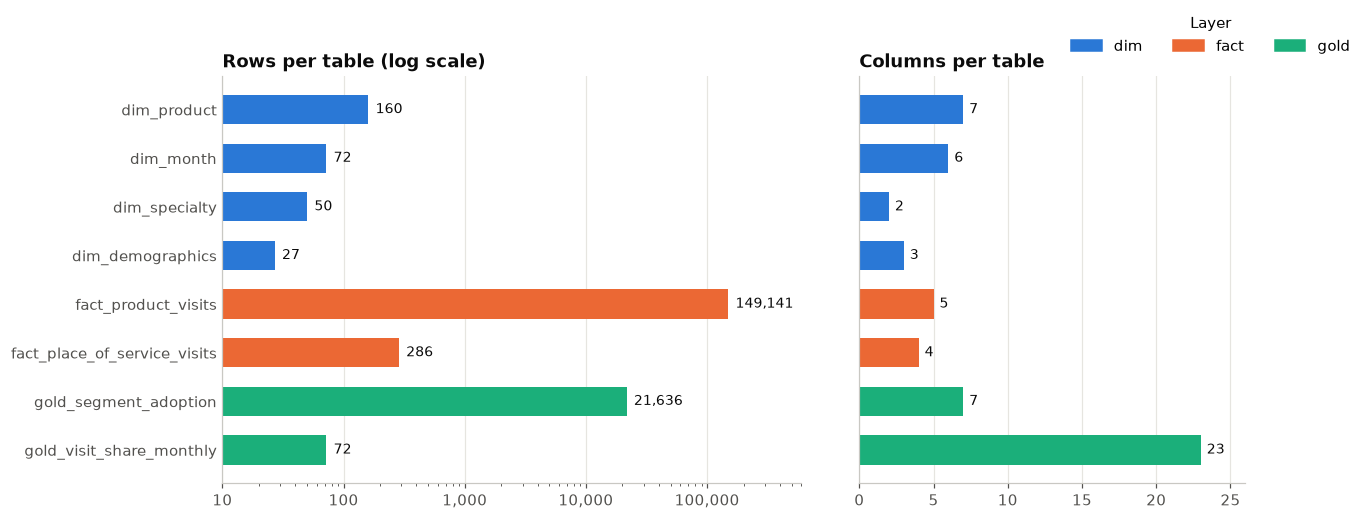

In [3]:
layer_colors = {"dim": PALETTE[0], "fact": PALETTE[1], "gold": PALETTE[2]}
plot_df = shapes.iloc[::-1]  # largest-first reading order within each layer, top to bottom
colors = plot_df["layer"].map(layer_colors)

fig, (ax_r, ax_c) = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True,
                                 gridspec_kw={"width_ratios": [3, 2], "wspace": 0.12})

ax_r.barh(plot_df["table"], plot_df["rows"], color=colors, height=0.6)
ax_r.set_xscale("log")
ax_r.set_xlim(10, 6e5)
ax_r.set_xticks([10, 100, 1_000, 10_000, 100_000])
ax_r.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax_r.set_title("Rows per table (log scale)")
for y, v in enumerate(plot_df["rows"]):
    ax_r.text(v * 1.15, y, f"{v:,}", va="center", fontsize=9, color=INK)

ax_c.barh(plot_df["table"], plot_df["columns"], color=colors, height=0.6)
ax_c.set_xlim(0, 26)
ax_c.set_title("Columns per table")
for y, v in enumerate(plot_df["columns"]):
    ax_c.text(v + 0.4, y, str(v), va="center", fontsize=9, color=INK)

for ax in (ax_r, ax_c):
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", length=0)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in layer_colors.values()]
fig.legend(handles, layer_colors.keys(), title="Layer", loc="upper right",
           bbox_to_anchor=(0.99, 1.02), ncol=3, frameon=False)
plt.show()

**Read-out:**

- **Dimensions are small lookup tables.** They cover 72 months (Aug 2019 – Jul 2025), 160 products, 50 specialties and 27 age/gender groups.
- **`fact_product_visits` is the main table at ~149K rows.** Each row is one month × product × specialty × demographic combination. It is not the full cross-product of the dimensions (72 × 160 × 50 × 27 ≈ 15.5M), so combinations with no visits are simply absent rather than stored as zeros.
- **`fact_place_of_service_visits` is small (286 rows)** because it is only broken down by month, disease area and setting.
- **`gold_visit_share_monthly` has one row per month (72)** and is the widest table (23 columns), since it holds the target share plus the modelling features.
- **`gold_segment_adoption` has ~21.6K rows**, with share broken down by month × specialty × demographic group.

## 2. Descriptive statistics

Summary statistics for the columns that hold actual measurements. ID columns (`month_id`, `product_id`, etc.) are left out, since their mean or spread means nothing.

### 2.1 Numeric columns

For every numeric measure in the fact and gold tables, the table shows:

- **count and % missing:** how much data is present.
- **unique:** number of distinct values; **1 means the column never changes**.
- **mean, std, min, quartiles, max:** centre and spread.
- **skew:** 0 is symmetric; a large positive value means a long right tail (a few very large values).

In [4]:
ID_COLS = {"month_id", "product_id", "specialty_id", "demographic_id"}

def numeric_summary(table):
    df = pd.read_sql(f"SELECT * FROM {table}", conn)
    num = df.select_dtypes("number").drop(columns=ID_COLS & set(df.columns))
    out = num.describe().T
    out.insert(0, "table", table)
    out.insert(2, "missing_%", num.isna().mean() * 100)
    out.insert(3, "unique", num.nunique())
    out["skew"] = num.skew()
    return out

numeric_stats = pd.concat([numeric_summary(t) for t in
                           ["fact_product_visits", "fact_place_of_service_visits",
                            "gold_visit_share_monthly", "gold_segment_adoption"]])
numeric_stats.style.format(
    {c: "{:,.4g}" for c in ["mean", "std", "min", "25%", "50%", "75%", "max", "skew"]}
    | {"count": "{:,.0f}", "missing_%": "{:.1f}", "unique": "{:,.0f}"}
)

,table,count,missing_%,unique,mean,std,min,25%,50%,75%,max,skew
patient_visits,fact_product_visits,"149,141",0.0,"1,476",37.19,135.3,1,1,4,18,"3,519",8.983
patient_visits,fact_place_of_service_visits,286,0.0,269,2.514e+04,4.102e+04,1,"1,036","2,465",3.055e+04,1.221e+05,1.241
branded_injectable_visits,gold_visit_share_monthly,72,0.0,70,"1,877",507.3,937,"1,389","1,876","2,306","2,849",0.1913
generic_corticosteroid_visits,gold_visit_share_monthly,72,0.0,72,6.812e+04,1.029e+04,2.88e+04,6.094e+04,6.834e+04,7.53e+04,8.919e+04,-0.5998
nsaid_otc_visits,gold_visit_share_monthly,72,0.0,72,"5,473","1,050","1,033","4,978","5,609","6,147","7,180",-1.299
visit_share,gold_visit_share_monthly,72,0.0,72,0.02466,0.004353,0.01741,0.02036,0.02531,0.02786,0.03376,-0.07658
visit_share_lag_1,gold_visit_share_monthly,71,1.4,71,0.02474,0.004327,0.01741,0.02038,0.02548,0.02794,0.03376,-0.1018
visit_share_lag_2,gold_visit_share_monthly,70,2.8,70,0.02484,0.004281,0.01741,0.02051,0.02552,0.02802,0.03376,-0.1176
visit_share_lag_3,gold_visit_share_monthly,69,4.2,69,0.02495,0.004215,0.0175,0.02091,0.02556,0.0281,0.03376,-0.1211
visit_share_roll_3mo,gold_visit_share_monthly,69,4.2,69,0.02494,0.004044,0.01763,0.02104,0.02664,0.02792,0.03212,-0.2434


**The monthly target and its inputs.** The four panels below show how the monthly values in `gold_visit_share_monthly` are distributed: the target `visit_share` and the three visit counts it is built from. Each has its own x-axis because the scales differ by ~40×. The dashed line is the mean and the solid line is the median.

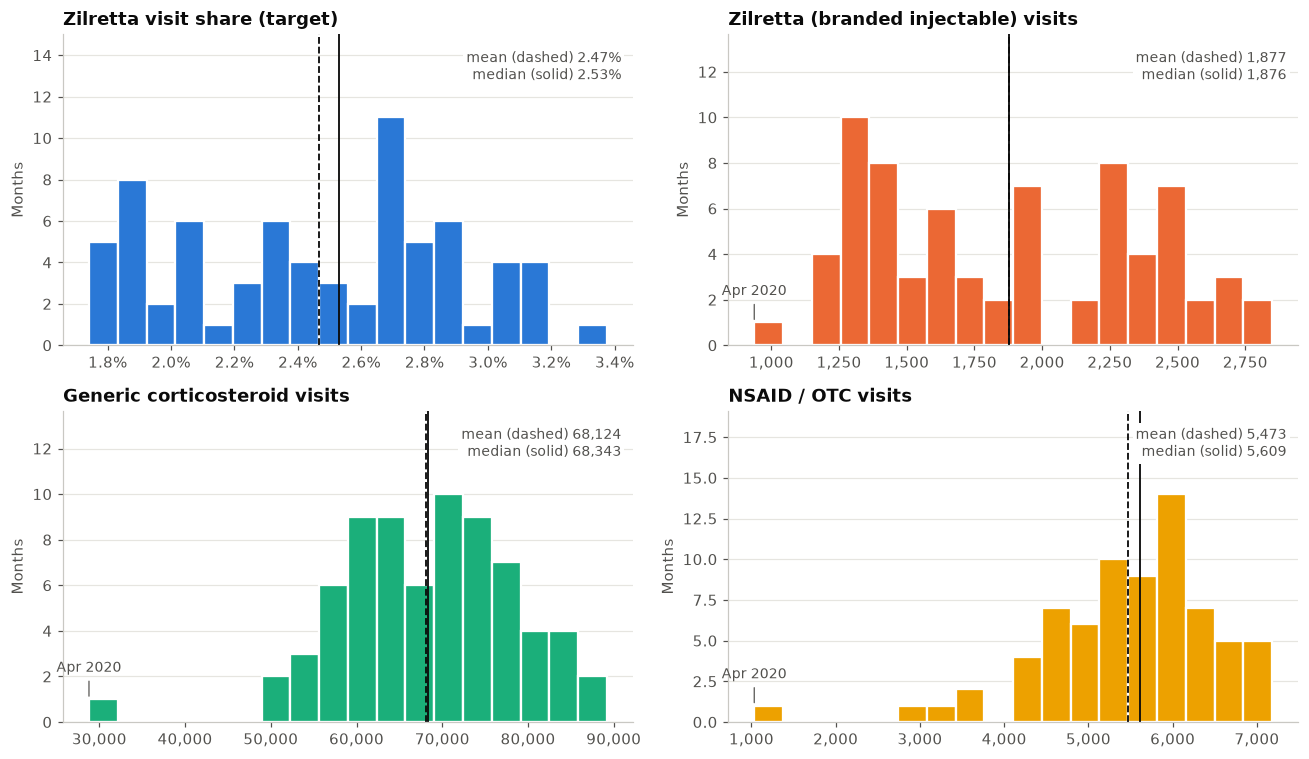

In [5]:
gold = pd.read_sql(
    """SELECT m.calendar_date, g.*
       FROM gold_visit_share_monthly g JOIN dim_month m USING (month_id)
       ORDER BY m.calendar_date""", conn, parse_dates=["calendar_date"])

panels = [("visit_share", "Zilretta visit share (target)", True),
          ("branded_injectable_visits", "Zilretta (branded injectable) visits", False),
          ("generic_corticosteroid_visits", "Generic corticosteroid visits", False),
          ("nsaid_otc_visits", "NSAID / OTC visits", False)]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (col, title, is_pct), color in zip(axes.flat, panels, PALETTE):
    s = gold[col]
    ax.hist(s, bins=18, color=color, edgecolor="white", linewidth=1.5)
    ax.axvline(s.mean(), color=INK, ls="--", lw=1.2)
    ax.axvline(s.median(), color=INK, lw=1.2)
    fmt = (lambda v, _: f"{v:.2%}") if is_pct else (lambda v, _: f"{v:,.0f}")
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(fmt))
    ax.set_title(title)
    if is_pct:
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:.1%}"))
    ax.set_ylabel("Months")
    ax.set_ylim(0, ax.get_ylim()[1] * 1.3)  # headroom for the stats label
    ax.grid(axis="x", visible=False)
    ax.text(0.98, 0.95, f"mean (dashed) {fmt(s.mean(), 0)}\nmedian (solid) {fmt(s.median(), 0)}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9, color=MUTED,
            bbox=dict(facecolor="white", edgecolor="none", pad=2))

# Label the single low outlier month in the volume panels
for ax, col in zip(axes.flat[1:], [p[0] for p in panels[1:]]):
    low = gold.loc[gold[col].idxmin()]
    ax.annotate(low["calendar_date"].strftime("%b %Y"), xy=(low[col], 1), xytext=(0, 18),
                textcoords="offset points", ha="center", fontsize=9, color=MUTED,
                arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
fig.tight_layout()
plt.show()

**Row-level distributions.** The fact table and the segment table are much more granular. Their counts span several orders of magnitude, so the two count panels use a **log x-axis**. The third panel groups segment-level Zilretta share into buckets.

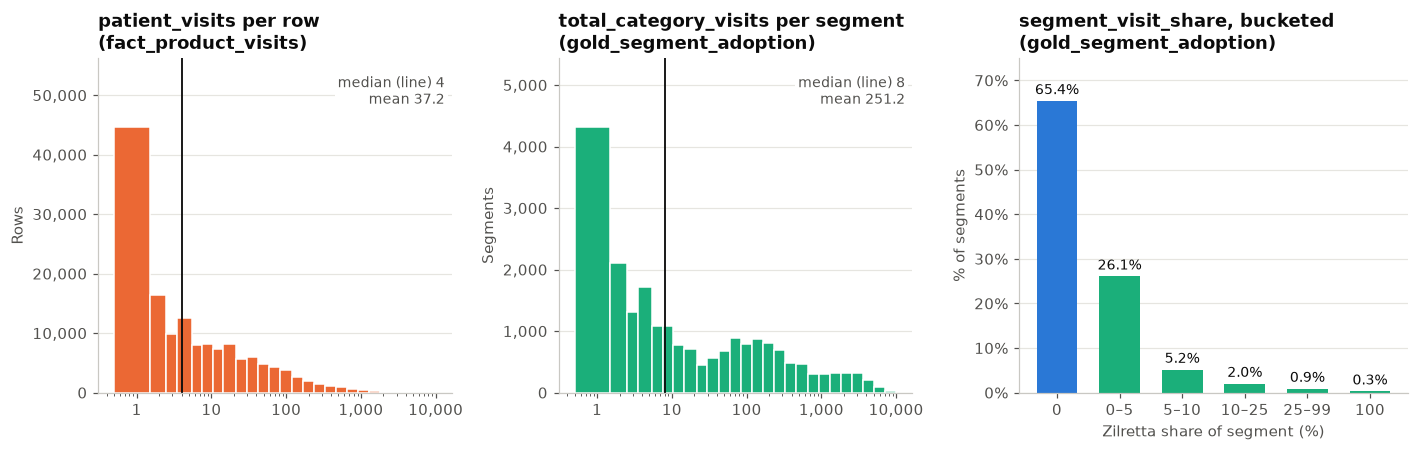

In [6]:
fpv = pd.read_sql("SELECT patient_visits FROM fact_product_visits", conn)["patient_visits"]
seg = pd.read_sql("SELECT total_category_visits, segment_visit_share FROM gold_segment_adoption", conn)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 1, 1.1]})
# Log-spaced bins snapped to whole numbers, since visit counts are integers
log_bins = np.unique(np.round(np.logspace(0, 4, 28))) - 0.5

for ax, s, color, title, ylabel in [
    (axes[0], fpv, PALETTE[1], "patient_visits per row\n(fact_product_visits)", "Rows"),
    (axes[1], seg["total_category_visits"], PALETTE[2],
     "total_category_visits per segment\n(gold_segment_adoption)", "Segments"),
]:
    ax.hist(s, bins=log_bins, color=color, edgecolor="white", linewidth=1)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax.axvline(s.median(), color=INK, lw=1.2)
    ax.text(0.98, 0.95, f"median (line) {s.median():,.0f}\nmean {s.mean():,.1f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9, color=MUTED,
            bbox=dict(facecolor="white", edgecolor="none", pad=2))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
    ax.grid(axis="x", visible=False)

ax = axes[2]
share = seg["segment_visit_share"]
buckets = pd.cut(share, bins=[-0.001, 0, 0.05, 0.10, 0.25, 0.999, 1.0],
                 labels=["0", "0–5", "5–10", "10–25", "25–99", "100"])
bucket_pct = buckets.value_counts(normalize=True, sort=False)
bar_colors = [PALETTE[0]] + [PALETTE[2]] * (len(bucket_pct) - 1)
ax.bar(bucket_pct.index.astype(str), bucket_pct.values, color=bar_colors, width=0.65)
for x, v in enumerate(bucket_pct.values):
    ax.text(x, v + 0.015, f"{v:.1%}", ha="center", fontsize=9, color=INK)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 0.75)
ax.set_title("segment_visit_share, bucketed\n(gold_segment_adoption)")
ax.set_ylabel("% of segments")
ax.set_xlabel("Zilretta share of segment (%)")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

**Read-out (numeric):**

- **The target `visit_share` is small and moves within a narrow range.** It averages **2.47%** (std 0.44pp) and never leaves **1.74%–3.38%** across 72 months. Its distribution is fairly symmetric, with no extreme months.
- **Generic corticosteroids dominate the category.** At ~68K visits a month against ~1.9K for Zilretta and ~5.5K for NSAIDs/OTC, they are about 90% of the share denominator. Shifts in generic volume therefore move the share as much as Zilretta itself does.
- **April 2020 (COVID) is the one clear outlier.** It is the lowest month for every visit count (e.g. generics fell to 28.8K and office visits to 39.5K), and telehealth spiked to its maximum of 1,016 that month (vs. a median of 207).
- **Row-level counts are heavily right-skewed.** In `fact_product_visits` the median row has **4** visits but the mean is 37 and the max 3,519. Most rows are tiny, and a few large product × specialty × demographic combinations carry most of the volume.
- **Segment shares are mostly noise at the extremes.** 52% of segments have fewer than 10 total visits (median 8), and **65% of segments show exactly 0%** Zilretta share, while a handful show 100%. Small segments should be filtered or weighted by volume before comparing them.
- **Some columns carry no information:**
  - `is_post_launch` and `competitor_count_on_market` are constant (always 1).
  - `months_since_last_competitor_event` is identical to `months_since_launch` in every row.
  - `predicted_direction`, `prediction_probability`, `model_version`, `actual_direction` and `adoption_label` are 100% empty.
- **Missing values in lag/rolling features are expected.** They occur only at the start of the series (1–3 months for lags, 3 and 6 for the 3- and 6-month rolling windows), where there isn't enough history yet.

### 2.2 Categorical columns

Text columns: how many distinct values each has, the most common value, and how often it appears.

In [7]:
cat_cols = {
    "dim_product": ["manufacturer", "brand_generic_tag", "disease_area", "treatment_category"],
    "dim_demographics": ["age_band", "gender"],
    "fact_place_of_service_visits": ["disease_area", "place_of_service"],
    "gold_visit_share_monthly": ["direction_label"],
}
rows = []
for table, cols in cat_cols.items():
    df = pd.read_sql(f"SELECT {', '.join(cols)} FROM {table}", conn)
    for col in cols:
        vc = df[col].value_counts()
        rows.append({"table": table, "column": col, "count": df[col].notna().sum(),
                     "missing": df[col].isna().sum(), "unique": df[col].nunique(),
                     "top": vc.index[0], "top_freq": vc.iloc[0],
                     "top_%": round(vc.iloc[0] / df[col].notna().sum() * 100, 1)})
pd.DataFrame(rows)

,table,column,count,missing,unique,top,top_freq,top_%
0,dim_product,manufacturer,160,0,74,PFIZER,14,8.8
1,dim_product,brand_generic_tag,160,0,4,OTHER,46,28.7
2,dim_product,disease_area,160,0,2,OA,145,90.6
3,dim_product,treatment_category,160,0,6,nsaid_otc,54,33.8
4,dim_demographics,age_band,27,0,10,40 TO 59,3,11.1
5,dim_demographics,gender,27,0,3,MALE,10,37.0
6,fact_place_of_service_visits,disease_area,286,0,1,OA,286,100.0
7,fact_place_of_service_visits,place_of_service,286,0,4,HOSPITAL,72,25.2
8,gold_visit_share_monthly,direction_label,59,13,3,Flat,43,72.9


The chart shows how the 160 products split by treatment category, alongside each category's share of all patient visits. A category with many products may still account for few visits, and the other way round.

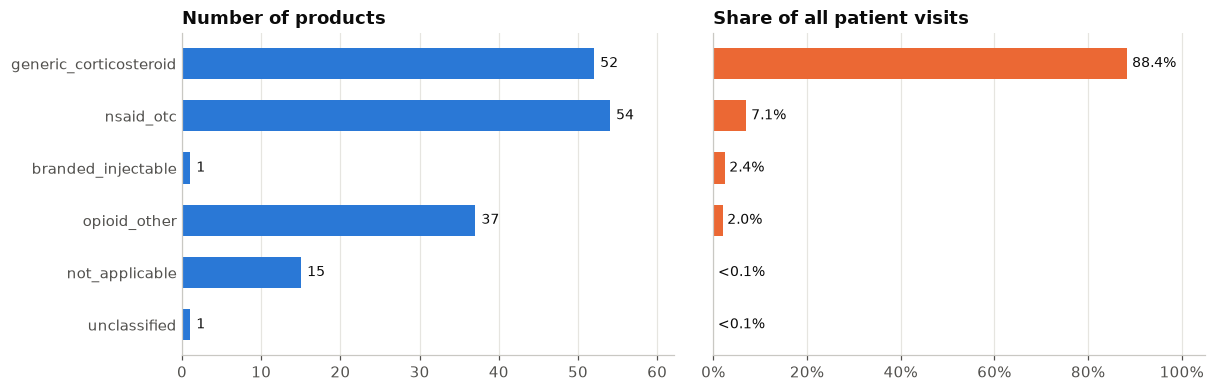

In [8]:
prod = pd.read_sql(
    """SELECT p.treatment_category, COUNT(DISTINCT p.product_id) AS products,
              COALESCE(SUM(f.patient_visits), 0) AS visits
       FROM dim_product p LEFT JOIN fact_product_visits f USING (product_id)
       GROUP BY p.treatment_category""", conn).sort_values("visits")
prod["visit_%"] = prod["visits"] / prod["visits"].sum()

fig, (ax_p, ax_v) = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True,
                                 gridspec_kw={"wspace": 0.08})
ax_p.barh(prod["treatment_category"], prod["products"], color=PALETTE[0], height=0.6)
ax_p.set_title("Number of products")
for y, v in enumerate(prod["products"]):
    ax_p.text(v + 0.8, y, str(v), va="center", fontsize=9, color=INK)
ax_p.set_xlim(0, prod["products"].max() * 1.15)

ax_v.barh(prod["treatment_category"], prod["visit_%"], color=PALETTE[1], height=0.6)
ax_v.set_title("Share of all patient visits")
ax_v.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for y, v in enumerate(prod["visit_%"]):
    ax_v.text(v + 0.01, y, f"{v:.1%}" if v >= 0.001 else "<0.1%", va="center", fontsize=9, color=INK)
ax_v.set_xlim(0, 1.05)

for ax in (ax_p, ax_v):
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", length=0)
plt.show()

**Read-out (categorical):**

- **Generic corticosteroids have about a third of the products (52) but ~88% of all visits.** NSAIDs/OTC have slightly more products (54) but only ~7% of visits.
- **Zilretta is the only `branded_injectable` product** and accounts for ~2.4% of all visits.
- **RA barely exists in the data.** It has 15 products (`not_applicable` category) but only 1,250 visits, and `fact_place_of_service_visits` has OA rows only. The analysis is effectively OA-only.
- **`direction_label` has three values on 59 of 72 months: 7 Up / 43 Flat / 9 Down.** This is the volatility-scaled rule adopted in section 12 (PROPOSAL §18.2). The first 13 months are empty: Aug 2019 has no prior month, and the next 12 have no full trailing 12-month window for the volatility baseline. The original fixed ±1pp rule would have labelled all 71 changes `Flat` (section 12.4).
- **`place_of_service` has 286 rows rather than 288 (72 × 4).** The two missing rows are TELEHEALTH months, which likely had zero telehealth visits.
- **Data-quality notes:**
  - Zilretta is tagged `BRANDED GENERIC` although it is a branded product.
  - `fda_approval_date` is filled only for Zilretta (1 of 160).
  - One OA product is still `unclassified`.

### 2.3 OA vs. RA

The database covers two disease areas: **OA** (osteoarthritis, the Zilretta market) and **RA** (rheumatoid arthritis). The table compares them on the same descriptive statistics. The estimated mean age uses the midpoint of each age band; the method is explained in 2.4.

In [9]:
AGE_MID = {"00 TO 02": 1, "03 TO 09": 6, "10 TO 19": 14.5, "20 TO 39": 29.5, "40 TO 59": 49.5,
           "60 TO 64": 62, "65 TO 74": 69.5, "75 TO 84": 79.5, "85 +": 88}      # "85 +" assumed 85–90
AGE_BANDS = list(AGE_MID)

visits_full = pd.read_sql(
    """SELECT f.month_id, f.patient_visits, p.product_name, p.disease_area, p.treatment_category,
              s.specialty_name, d.age_band, d.gender
       FROM fact_product_visits f
       JOIN dim_product p USING (product_id)
       JOIN dim_specialty s USING (specialty_id)
       JOIN dim_demographics d USING (demographic_id)""", conn)
visits_full["age_mid"] = visits_full["age_band"].map(AGE_MID)

def weighted_mean_age(d):
    d = d.dropna(subset=["age_mid"])
    return np.average(d["age_mid"], weights=d["patient_visits"])

def area_profile(d):
    monthly = d.groupby("month_id")["patient_visits"].sum()
    return pd.Series({
        "patient visits": d["patient_visits"].sum(),
        "% of all visits": d["patient_visits"].sum() / visits_full["patient_visits"].sum() * 100,
        "rows": len(d),
        "products with visits": d["product_name"].nunique(),
        "specialties": d["specialty_name"].nunique(),
        "months present": d["month_id"].nunique(),
        "visits per month (mean)": monthly.mean(),
        "visits per month (min–max)": f"{monthly.min():,.0f} – {monthly.max():,.0f}",
        "visits per row (median)": d["patient_visits"].median(),
        "visits per row (max)": d["patient_visits"].max(),
        "% female": d.loc[d["gender"] == "FEMALE", "patient_visits"].sum() / d["patient_visits"].sum() * 100,
        "% under 40": d.loc[d["age_mid"] < 40, "patient_visits"].sum() / d["patient_visits"].sum() * 100,
        "est. mean age": weighted_mean_age(d),
    })

oa_ra = visits_full.groupby("disease_area").apply(area_profile, include_groups=False).T
def fmt_cell(v):
    if isinstance(v, str):
        return v
    if float(v).is_integer():
        return f"{v:,.0f}"
    return f"{v:,.2f}" if abs(v) < 1 else f"{v:,.1f}"
oa_ra.style.format(fmt_cell)

disease_area,OA,RA
patient visits,"5,544,840","1,250"
% of all visits,100.0,0.02
rows,"148,128","1,013"
products with visits,144,14
specialties,50,19
months present,72,72
visits per month (mean),"77,011.7",17.4
visits per month (min–max),"31,373 – 100,206",2 – 36
visits per row (median),4,1
visits per row (max),"3,519",4


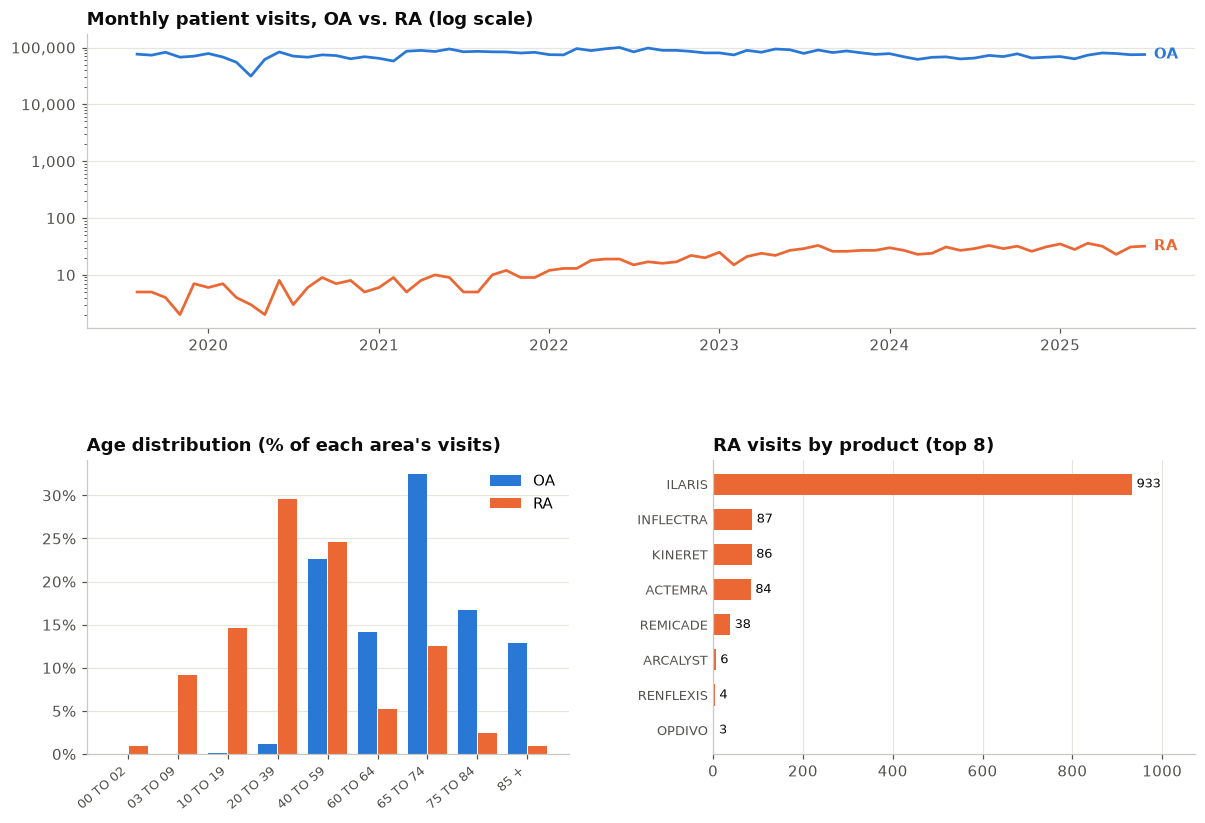

In [10]:
fig = plt.figure(figsize=(13, 8.5))
gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.3)
area_colors = {"OA": PALETTE[0], "RA": PALETTE[1]}

# (a) Monthly visits over time, log scale so both areas are visible
ax = fig.add_subplot(gs[0, :])
monthly_area = visits_full.groupby(["month_id", "disease_area"])["patient_visits"].sum().unstack()
monthly_area.index = pd.to_datetime(monthly_area.index.astype(str), format="%Y%m")
for area in ["OA", "RA"]:
    ax.plot(monthly_area.index, monthly_area[area], color=area_colors[area], lw=1.8)
    ax.text(monthly_area.index[-1] + pd.Timedelta(days=20), monthly_area[area].iloc[-1], area,
            color=area_colors[area], fontweight="bold", va="center")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_title("Monthly patient visits, OA vs. RA (log scale)")
ax.grid(axis="x", visible=False)

# (b) Age distribution, % of each area's visits
ax = fig.add_subplot(gs[1, 0])
age_dist = (visits_full.dropna(subset=["age_mid"]).groupby(["age_band", "disease_area"])["patient_visits"].sum()
            .unstack().reindex(AGE_BANDS))
age_dist = age_dist / age_dist.sum()
x = np.arange(len(AGE_BANDS))
for off, area in [(-0.2, "OA"), (0.2, "RA")]:
    ax.bar(x + off, age_dist[area], width=0.38, color=area_colors[area], label=area)
ax.set_xticks(x, AGE_BANDS, rotation=40, ha="right", fontsize=8.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_title("Age distribution (% of each area's visits)")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)

# (c) What the RA visits actually are
ax = fig.add_subplot(gs[1, 1])
ra_products = (visits_full[visits_full["disease_area"] == "RA"].groupby("product_name")["patient_visits"]
               .sum().sort_values().tail(8))
ax.barh(ra_products.index, ra_products.values, color=PALETTE[1], height=0.6)
for y, v in enumerate(ra_products.values):
    ax.text(v + 10, y, f"{v:,}", va="center", fontsize=8.5, color=INK)
ax.set_xlim(0, ra_products.max() * 1.15)
ax.set_title("RA visits by product (top 8)")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0, labelsize=8.5)
plt.show()

**Read-out (OA vs. RA):**

- **RA is 0.02% of the data.** It has 1,250 visits against 5.54 million for OA, a ratio of about 1:4,400. RA averages ~17 visits a month (2 to 36), and almost every RA row is 1–4 visits. RA is present in all 72 months but too thin for any statistical analysis. Everything else in this notebook is effectively an OA analysis.
- **The RA patients are a different population.** Estimated mean age is **~38 vs. ~67 for OA**, and **54% of RA visits are under 40** (including 25% children and teenagers) vs. about 1% for OA. The share female is similar (61% vs 65%).
- **The "RA" products are not really an RA market.**
  - 75% of RA visits are **ILARIS** (canakinumab), which is mainly used for periodic fever syndromes and Still's disease, which explains the young patients.
  - The list also includes **oncology drugs** (Keytruda, Opdivo, Yervoy) and several other biologics.
  - The `RA` tag therefore reads as a catch-all "other biologics" bucket.
- **Implication:** filter to `disease_area = 'OA'` for all modelling (the gold tables already do), and do not draw RA conclusions from this data.

### 2.4 Patient age

The data stores age as **bands** (e.g. "65 TO 74"), not exact ages. To summarise age with a single number, each band is represented by its **midpoint** (65–74 → 69.5), and the average is weighted by visits. `85 +` is assumed to be 85–90 (midpoint 88), and `UNSPECIFIED` is excluded. These are **estimates**. The band distribution itself is exact.

This subsection looks at the **age gap** in three ways:

- between treatments, especially Zilretta vs. its alternatives;
- between women and men;
- over time.

In [11]:
oa = visits_full[(visits_full["disease_area"] == "OA") & visits_full["age_mid"].notna()]
TREATMENTS = ["branded_injectable", "generic_corticosteroid", "nsaid_otc", "opioid_other"]

age_table = pd.DataFrame({
    "all": oa.groupby("treatment_category").apply(weighted_mean_age, include_groups=False),
    "female": oa[oa["gender"] == "FEMALE"].groupby("treatment_category").apply(weighted_mean_age, include_groups=False),
    "male": oa[oa["gender"] == "MALE"].groupby("treatment_category").apply(weighted_mean_age, include_groups=False),
}).reindex(TREATMENTS)
age_table["gap female − male"] = age_table["female"] - age_table["male"]
age_table["gap vs. generic"] = age_table["all"] - age_table.loc["generic_corticosteroid", "all"]
age_table["% aged 65+"] = oa.assign(old=oa["age_mid"] >= 65).groupby("treatment_category").apply(
    lambda d: d.loc[d["old"], "patient_visits"].sum() / d["patient_visits"].sum() * 100, include_groups=False)
print("Estimated mean age (years), OA visits:")
age_table.style.format("{:.1f}").format("{:+.1f}", subset=["gap female − male", "gap vs. generic"])

Estimated mean age (years), OA visits:


,all,female,male,gap female − male,gap vs. generic,% aged 65+
treatment_category,,,,,,
branded_injectable,71.0,71.3,70.3,+1.0,+3.5,74.7
generic_corticosteroid,67.5,67.9,66.8,+1.1,+0.0,62.1
nsaid_otc,65.9,66.5,64.9,+1.6,-1.6,58.2
opioid_other,64.6,64.7,64.4,+0.3,-2.9,52.9


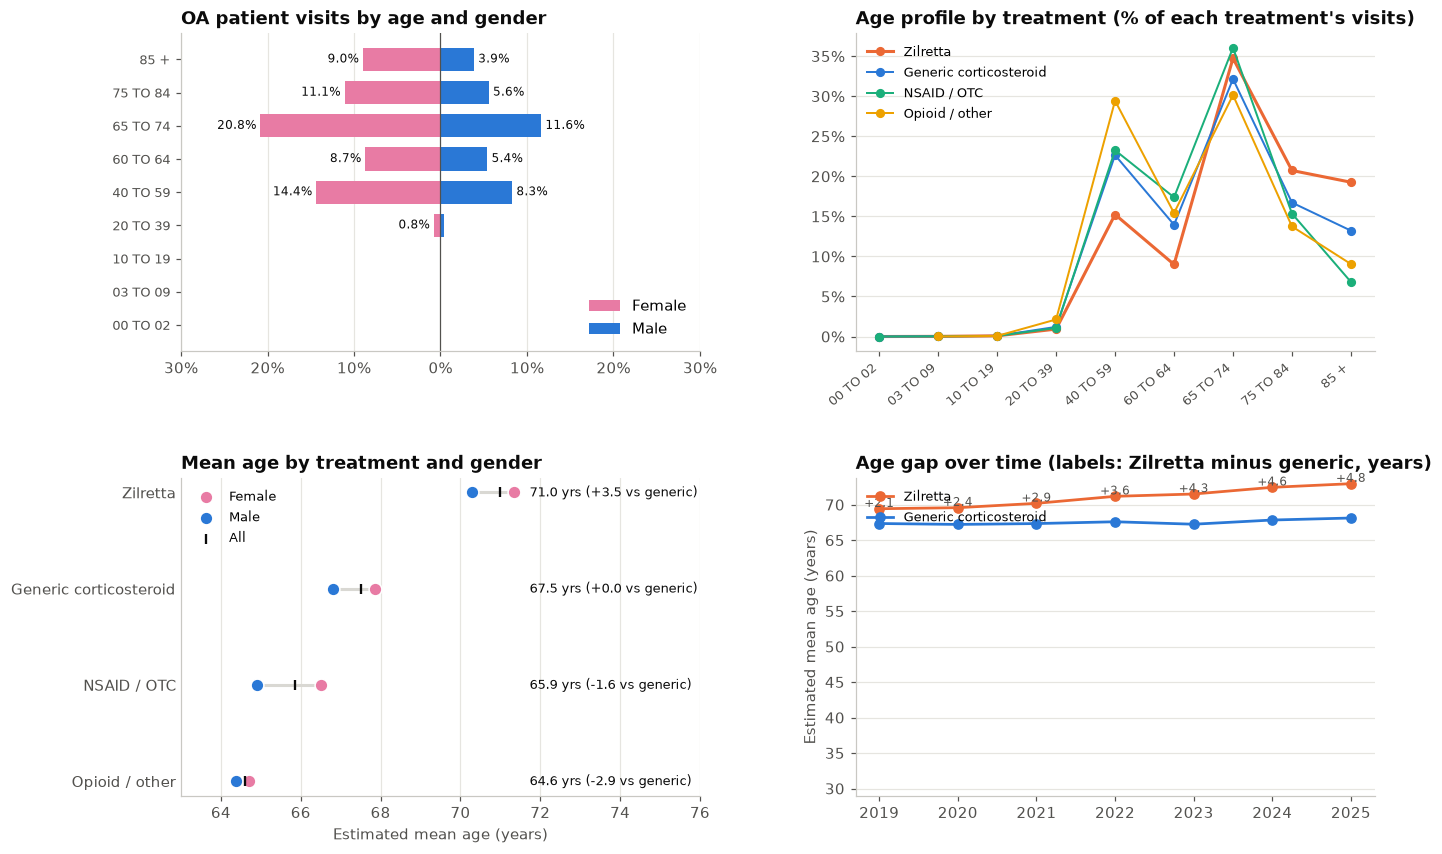

In [12]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.3)
tr_colors = dict(zip(TREATMENTS, [PALETTE[1], PALETTE[0], PALETTE[2], PALETTE[3]]))
tr_labels = {"branded_injectable": "Zilretta", "generic_corticosteroid": "Generic corticosteroid",
             "nsaid_otc": "NSAID / OTC", "opioid_other": "Opioid / other"}

# (a) Population pyramid, all OA visits
ax = fig.add_subplot(gs[0, 0])
pyr = oa[oa["gender"].isin(["FEMALE", "MALE"])].groupby(["age_band", "gender"])["patient_visits"].sum().unstack()
pyr = (pyr / pyr.values.sum()).reindex(AGE_BANDS)
y = np.arange(len(AGE_BANDS))
ax.barh(y, -pyr["FEMALE"], color=PALETTE[4], height=0.7, label="Female")
ax.barh(y, pyr["MALE"], color=PALETTE[0], height=0.7, label="Male")
for yy, (f_, m_) in enumerate(zip(pyr["FEMALE"], pyr["MALE"])):
    if f_ > 0.005: ax.text(-f_ - 0.005, yy, f"{f_:.1%}", ha="right", va="center", fontsize=8, color=INK)
    if m_ > 0.005: ax.text(m_ + 0.005, yy, f"{m_:.1%}", ha="left", va="center", fontsize=8, color=INK)
ax.axvline(0, color=MUTED, lw=0.8)
ax.set_yticks(y, AGE_BANDS, fontsize=8.5)
ax.set_xlim(-0.3, 0.3)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{abs(v):.0%}"))
ax.set_title("OA patient visits by age and gender")
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)

# (b) Age profile by treatment
ax = fig.add_subplot(gs[0, 1])
prof = oa.groupby(["age_band", "treatment_category"])["patient_visits"].sum().unstack().reindex(AGE_BANDS)[TREATMENTS]
prof = prof / prof.sum()
for t in TREATMENTS:
    ax.plot(range(len(AGE_BANDS)), prof[t], marker="o", markersize=5, lw=2 if t == "branded_injectable" else 1.3,
            color=tr_colors[t], label=tr_labels[t])
ax.set_xticks(range(len(AGE_BANDS)), AGE_BANDS, rotation=40, ha="right", fontsize=8.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_title("Age profile by treatment (% of each treatment's visits)")
ax.legend(frameon=False, fontsize=8.5)
ax.grid(axis="x", visible=False)

# (c) Mean age by treatment and gender (dumbbell)
ax = fig.add_subplot(gs[1, 0])
yy = np.arange(len(TREATMENTS))[::-1]
ax.hlines(yy, age_table["male"], age_table["female"], color="#d9d8d3", lw=2)
ax.scatter(age_table["female"], yy, s=70, color=PALETTE[4], edgecolor="white", zorder=3, label="Female")
ax.scatter(age_table["male"], yy, s=70, color=PALETTE[0], edgecolor="white", zorder=3, label="Male")
ax.scatter(age_table["all"], yy, s=40, marker="|", color=INK, zorder=4, label="All")
for y_, (a, g) in zip(yy, zip(age_table["all"], age_table["gap vs. generic"])):
    ax.text(age_table[["female", "male"]].values.max() + 0.4, y_, f"{a:.1f} yrs ({g:+.1f} vs generic)",
            va="center", fontsize=8.5, color=INK)
ax.set_yticks(yy, [tr_labels[t] for t in TREATMENTS])
ax.set_xlim(63, 76)
ax.set_xlabel("Estimated mean age (years)")
ax.set_title("Mean age by treatment and gender")
ax.legend(loc="upper left", frameon=False, fontsize=8.5)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)

# (d) Mean age over time: Zilretta vs. generic
ax = fig.add_subplot(gs[1, 1])
yearly = oa.assign(year=oa["month_id"] // 100).groupby(["year", "treatment_category"]).apply(
    weighted_mean_age, include_groups=False).unstack()
for t in ["branded_injectable", "generic_corticosteroid"]:
    ax.plot(yearly.index, yearly[t], marker="o", color=tr_colors[t], lw=1.8, label=tr_labels[t])
gap = yearly["branded_injectable"] - yearly["generic_corticosteroid"]
for yr, g in gap.items():
    ax.text(yr, yearly.loc[yr, "branded_injectable"] + 0.25, f"+{g:.1f}", ha="center", fontsize=8, color=MUTED)
ax.set_xticks(yearly.index)
ax.set_ylim(yearly.min().min() - 0.5, yearly.max().max() + 0.8)
ax.set_ylabel("Estimated mean age (years)")
ax.set_title("Age gap over time (labels: Zilretta minus generic, years)")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
ax.grid(axis="x", visible=False)
plt.show()

**Read-out (patient age):**

- **OA patients are older.** Estimated mean age is about **67**. The largest band is 65–74 (32% of visits), and about 99% of visits are from patients aged 40+. There are more women than men in every band from 40 up.
- **Zilretta patients are the oldest group, about 3.5 years older than generic-corticosteroid patients** (≈71.0 vs 67.5). About 75% of Zilretta visits are 65+, vs 62% for generics. NSAID/OTC and opioid patients are younger still (≈65.9 and ≈64.6). The age profile chart shows why: Zilretta's curve sits to the right, with relatively more visits at 75–84 and 85+. One possible reason is that older, Medicare-age patients have coverage that makes a branded extended-release injection easier to access, but the data cannot confirm this.
- **The gender gap is small.** Women are ~1 year older than men within each treatment (e.g. Zilretta 71.3 vs 70.3), so the treatment gap is much larger than the gender gap.
- **The age gap is widening.** In 2019 Zilretta patients were ~2.1 years older than generic patients; by 2025 the gap is **~4.8 years**.
  - The gap grows every year.
  - Generic patients have aged only slightly (≈67.3 → 68.1), while Zilretta's mean age has risen steadily (≈69.4 → 73.0).
  - Zilretta use is concentrating in the oldest patients, and this happens while its overall share falls after 2022 (section 4). Zilretta may be losing younger patients faster than older ones, which is worth a closer look.
- **Caveat:** the ages are band-midpoint estimates, so treat differences under ~1 year as approximate. The *direction* of the gaps is robust because the band distributions themselves differ.

### 2.5 Outliers: box plots and histograms

Each monthly measure is shown two ways:

- **Box plot (top):** the box is the middle 50% of months (Q1–Q3) with the median line, whiskers reach the furthest point within 1.5 × IQR, and dots beyond them are outliers by the IQR rule.
- **Histogram (bottom):** the full shape of the distribution, on the same x-axis so each outlier dot lines up with its bar.

Section 10 examines these outliers in depth; this subsection is the descriptive view.

C:\Users\Tus20\AppData\Local\Temp\ipykernel_25052\2674373848.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(s, vert=False, widths=0.6, patch_artist=True,
C:\Users\Tus20\AppData\Local\Temp\ipykernel_25052\2674373848.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(s, vert=False, widths=0.6, patch_artist=True,
C:\Users\Tus20\AppData\Local\Temp\ipykernel_25052\2674373848.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(s, vert=False, widths=0.6, patch_artist=True,
C:\Users\Tus20\AppData\Local\Temp\ipykernel_25052\2674373848.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotli

C:\Users\Tus20\AppData\Local\Temp\ipykernel_25052\2674373848.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(s, vert=False, widths=0.6, patch_artist=True,
C:\Users\Tus20\AppData\Local\Temp\ipykernel_25052\2674373848.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(s, vert=False, widths=0.6, patch_artist=True,


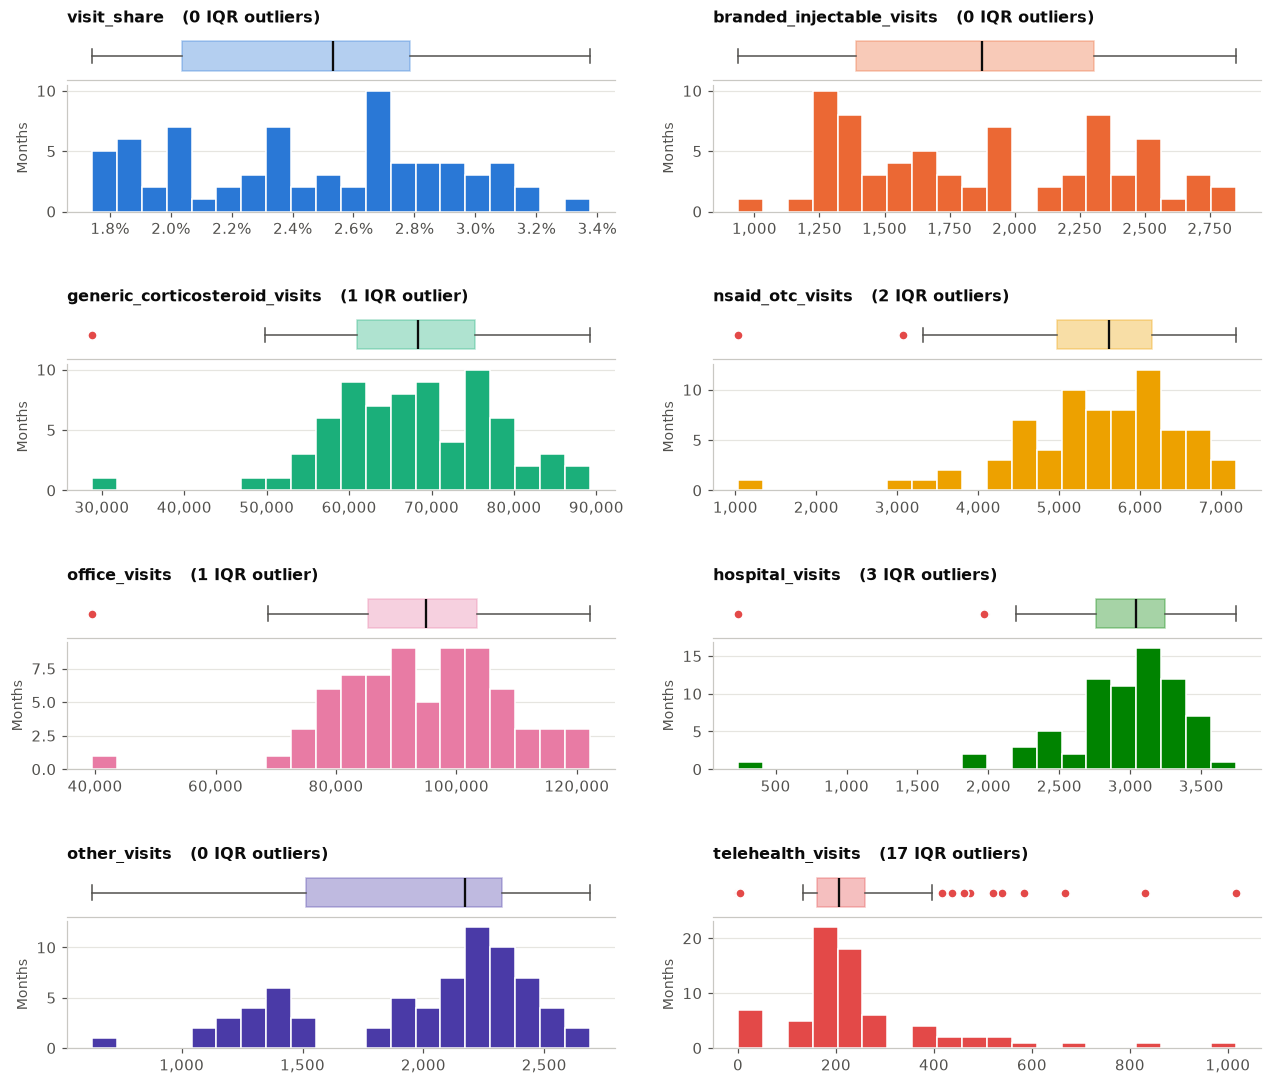

In [13]:
BOX_HIST = ["visit_share", "branded_injectable_visits", "generic_corticosteroid_visits", "nsaid_otc_visits",
            "office_visits", "hospital_visits", "other_visits", "telehealth_visits"]

fig = plt.figure(figsize=(14, 12))
outer = fig.add_gridspec(4, 2, hspace=0.55, wspace=0.18)
for k, (col, color) in enumerate(zip(BOX_HIST, PALETTE)):
    inner = outer[k // 2, k % 2].subgridspec(2, 1, height_ratios=[1, 2.6], hspace=0.05)
    ax_box = fig.add_subplot(inner[0])
    ax_hist = fig.add_subplot(inner[1], sharex=ax_box)
    s = gold[col]
    q1, q3 = s.quantile([0.25, 0.75])
    n_out = ((s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))).sum()

    ax_box.boxplot(s, vert=False, widths=0.6, patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.35, edgecolor=color),
                   medianprops=dict(color=INK, lw=1.5), whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                   flierprops=dict(marker="o", markersize=6, markerfacecolor=PALETTE[7], markeredgecolor="white"))
    ax_box.set_yticks([])
    ax_box.grid(visible=False)
    ax_box.spines["left"].set_visible(False)
    ax_box.tick_params(axis="x", labelbottom=False, length=0)
    ax_box.set_title(f"{col}   ({n_out} IQR outlier{'s' if n_out != 1 else ''})", fontsize=10.5)

    ax_hist.hist(s, bins=20, color=color, edgecolor="white", linewidth=1)
    ax_hist.set_ylabel("Months", fontsize=9)
    ax_hist.grid(axis="x", visible=False)
    ax_hist.xaxis.set_major_formatter(mtick.FuncFormatter(
        (lambda v, _: f"{v:.1%}") if col == "visit_share" else (lambda v, _: f"{v:,.0f}")))
plt.show()

The row-level count `patient_visits` (OA rows) is too skewed for a raw box plot (section 4.2). The same pair is shown on the **raw** scale, where everything above ~44 visits counts as an outlier, and on the **log(1 + x)** scale used in sections 4 and 10.

C:\Users\Tus20\AppData\Local\Temp\ipykernel_25052\4132299760.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(vals, vert=False, widths=0.6, patch_artist=True,
C:\Users\Tus20\AppData\Local\Temp\ipykernel_25052\4132299760.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(vals, vert=False, widths=0.6, patch_artist=True,


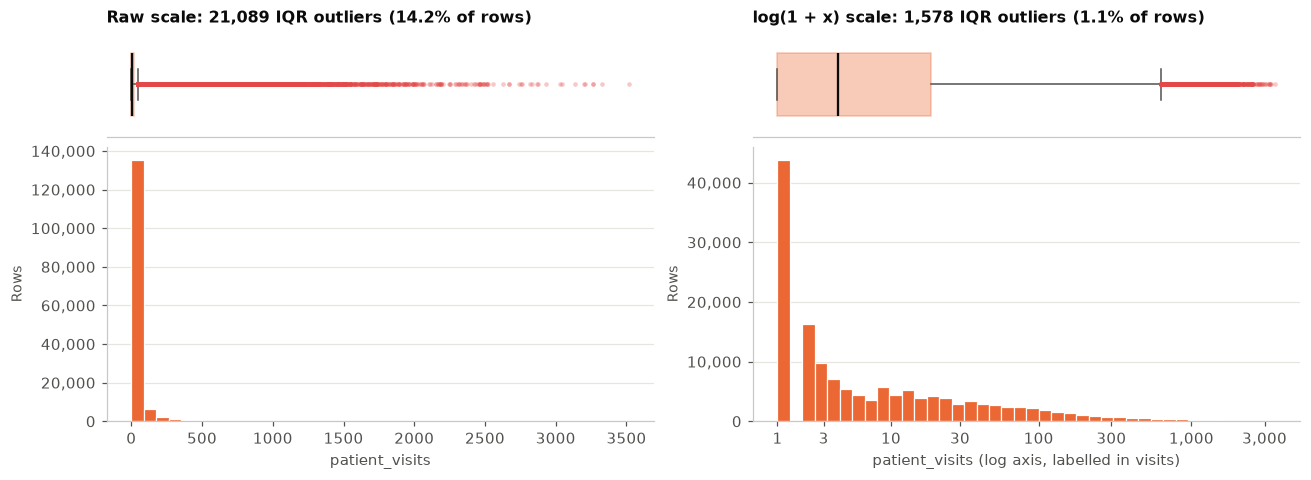

In [14]:
pv = visits_full.loc[visits_full["disease_area"] == "OA", "patient_visits"]
fig = plt.figure(figsize=(14, 4.6))
outer = fig.add_gridspec(1, 2, wspace=0.18)
for k, (vals, title, log) in enumerate([(pv, "Raw scale", False), (np.log1p(pv), "log(1 + x) scale", True)]):
    inner = outer[k].subgridspec(2, 1, height_ratios=[1, 2.6], hspace=0.05)
    ax_box, ax_hist = fig.add_subplot(inner[0]), fig.add_subplot(inner[1])
    ax_hist.sharex(ax_box)
    q1, q3 = vals.quantile([0.25, 0.75])
    n_out = (vals > q3 + 1.5 * (q3 - q1)).sum()
    ax_box.boxplot(vals, vert=False, widths=0.6, patch_artist=True,
                   boxprops=dict(facecolor=PALETTE[1], alpha=0.35, edgecolor=PALETTE[1]),
                   medianprops=dict(color=INK, lw=1.5), whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                   flierprops=dict(marker="o", markersize=3, markerfacecolor=PALETTE[7], markeredgecolor="none", alpha=0.3))
    ax_box.set_yticks([])
    ax_box.grid(visible=False)
    ax_box.spines["left"].set_visible(False)
    ax_box.tick_params(axis="x", labelbottom=False, length=0)
    ax_box.set_title(f"{title}: {n_out:,} IQR outliers ({n_out / len(vals):.1%} of rows)", fontsize=10.5)
    ax_hist.hist(vals, bins=40, color=PALETTE[1], edgecolor="white", linewidth=0.8)
    ax_hist.set_ylabel("Rows", fontsize=9)
    ax_hist.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax_hist.grid(axis="x", visible=False)
    if log:
        ticks = [1, 3, 10, 30, 100, 300, 1000, 3000]
        ax_hist.set_xticks(np.log1p(ticks), [f"{t:,}" for t in ticks])
        ax_hist.set_xlabel("patient_visits (log axis, labelled in visits)")
    else:
        ax_hist.set_xlabel("patient_visits")
plt.show()

**Read-out (box plots and histograms):**

- **The target `visit_share` and Zilretta visits have no IQR outliers.** Their boxes are wide and their histograms flat or two-humped, reflecting the two share regimes seen in section 4, not individual extreme months.
- **Every volume measure except Zilretta has outliers on the low side, and they are the COVID months.** April 2020 is the lone dot far left of generic corticosteroid, office and NSAID visits. Hospital visits add March and May 2020, and NSAID visits add March 2020.
- **Telehealth has outliers on both sides (17 months).** Its box is narrow (~160–260 visits), so both the near-zero months before COVID (left) and the 2020–21 surge (right) fall outside the whiskers, because telehealth only became common after COVID began.
- **`other_visits` has no outliers but is clearly two-humped** (~1,200–1,500 before 2021, ~2,000–2,600 after), a level shift rather than outliers.
- **Row-level counts need a log scale before outlier rules make sense.**
  - On the raw scale the box is squashed against zero and 14% of rows are "outliers".
  - On the log(1 + x) scale the distribution is readable and only a thin upper tail stands out.

  Those upper-tail rows are the high-volume orthopedic and PA corticosteroid combinations examined in section 10.

## 3. Data types

A column's **storage type** (how SQLite and pandas hold it) is not always its **meaning**. For example, `quarter` is stored as an integer but is really a category, and `calendar_date` is stored as text but is a date. The meaning decides which analysis and encoding make sense later, so each column gets three labels:

- **SQL type:** declared in the database schema.
- **pandas dtype:** what the column becomes when loaded with `pd.read_sql`.
- **Semantic type:** what the values actually represent:

| Semantic type | Meaning | Example |
|---|---|---|
| Key | ID used to join tables; not a quantity | `product_id` |
| Numerical – continuous | Any value in a range; ratios and shares | `visit_share` |
| Numerical – discrete | Whole-number counts | `patient_visits` |
| Categorical – nominal | Labels with no order (including 0/1 flags) | `gender`, `is_post_launch` |
| Categorical – ordinal | Labels with a natural order | `age_band`, `direction_label` |
| Date | Calendar dates | `calendar_date` |

In [15]:
# Semantic type for every column that isn't covered by the naming rules below
SEMANTIC_OVERRIDES = {
    "calendar_date": "Date", "fda_approval_date": "Date",
    "year": "Categorical – ordinal", "quarter": "Categorical – ordinal",
    "month_number": "Categorical – ordinal", "month_name": "Categorical – ordinal",
    "age_band": "Categorical – ordinal", "direction_label": "Categorical – ordinal",
    "predicted_direction": "Categorical – ordinal", "actual_direction": "Categorical – ordinal",
    "adoption_label": "Categorical – ordinal",
    "is_post_launch": "Categorical – nominal",
    "visit_share": "Numerical – continuous", "segment_visit_share": "Numerical – continuous",
    "prediction_probability": "Numerical – continuous",
}

def semantic_type(col, series):
    if col in SEMANTIC_OVERRIDES:
        return SEMANTIC_OVERRIDES[col]
    if col.endswith("_id"):
        return "Key"
    if col.startswith("visit_share_"):          # lags and rolling averages of the share
        return "Numerical – continuous"
    if pd.api.types.is_integer_dtype(series):   # visit counts, months-since counters
        return "Numerical – discrete"
    return "Categorical – nominal"               # remaining text columns

rows = []
for t in tables:
    df = pd.read_sql(f"SELECT * FROM {t}", conn)
    schema = pd.read_sql(f"PRAGMA table_info({t})", conn).set_index("name")["type"]
    for col in df.columns:
        rows.append({"table": t, "column": col, "sql_type": schema[col],
                     "pandas_dtype": str(df[col].dtype),
                     "semantic_type": semantic_type(col, df[col]),
                     "n_unique": df[col].nunique(), "example": df[col].dropna().iloc[0]
                     if df[col].notna().any() else None})
dtypes = pd.DataFrame(rows)
with pd.option_context("display.max_rows", None):
    display(dtypes)

,table,column,sql_type,pandas_dtype,semantic_type,n_unique,example
0,dim_demographics,demographic_id,INTEGER,int64,Key,27,1
1,dim_demographics,age_band,TEXT,str,Categorical – ordinal,10,40 TO 59
2,dim_demographics,gender,TEXT,str,Categorical – nominal,3,MALE
3,dim_month,month_id,INTEGER,int64,Key,72,201908
4,dim_month,calendar_date,TEXT,str,Date,72,2019-08-01
5,dim_month,year,INTEGER,int64,Categorical – ordinal,7,2019
6,dim_month,quarter,INTEGER,int64,Categorical – ordinal,4,3
7,dim_month,month_number,INTEGER,int64,Categorical – ordinal,12,8
8,dim_month,month_name,TEXT,str,Categorical – ordinal,12,August
9,dim_product,product_id,INTEGER,int64,Key,160,1


The chart counts columns by semantic type within each table, followed by the total across the database.

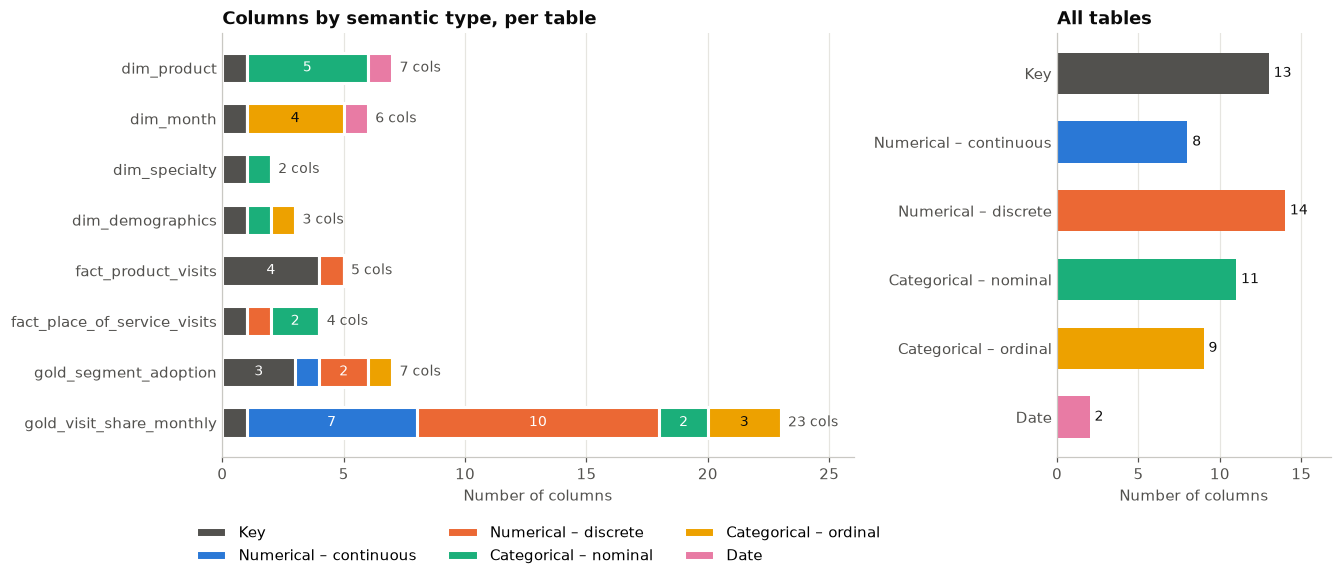

In [16]:
TYPE_ORDER = ["Key", "Numerical – continuous", "Numerical – discrete",
              "Categorical – nominal", "Categorical – ordinal", "Date"]
type_colors = dict(zip(TYPE_ORDER, [MUTED, PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3], PALETTE[4]]))

counts = (dtypes.pivot_table(index="table", columns="semantic_type", values="column",
                             aggfunc="count", fill_value=0)
          .reindex(columns=TYPE_ORDER, fill_value=0))
counts = counts.loc[shapes["table"]].iloc[::-1]   # same table order as section 1
totals = counts.sum()

fig, (ax_t, ax_all) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [3, 1.3], "wspace": 0.45})

left = np.zeros(len(counts))
for typ in TYPE_ORDER:
    vals = counts[typ].values
    ax_t.barh(counts.index, vals, left=left, color=type_colors[typ], height=0.6,
              edgecolor="white", linewidth=2, label=typ)
    for y, (l, v) in enumerate(zip(left, vals)):
        if v >= 2:
            ax_t.text(l + v / 2, y, str(v), ha="center", va="center", fontsize=9,
                    color=INK if typ in ("Categorical – ordinal", "Date") else "white")
    left += vals
for y, total in enumerate(left):
    ax_t.text(total + 0.3, y, f"{total:.0f} cols", va="center", fontsize=9, color=MUTED)
ax_t.set_xlim(0, 26)
ax_t.set_title("Columns by semantic type, per table")
ax_t.set_xlabel("Number of columns")

ax_all.barh(TYPE_ORDER[::-1], totals[TYPE_ORDER[::-1]], height=0.6,
            color=[type_colors[t] for t in TYPE_ORDER[::-1]])
for y, v in enumerate(totals[TYPE_ORDER[::-1]]):
    ax_all.text(v + 0.3, y, str(v), va="center", fontsize=9, color=INK)
ax_all.set_title("All tables")
ax_all.set_xlim(0, totals.max() * 1.2)
ax_all.set_xlabel("Number of columns")

for ax in (ax_t, ax_all):
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", length=0)
ax_t.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False)
plt.show()

**Where storage type and meaning disagree.** These columns need a conversion or special handling before analysis or modelling:

In [17]:
mismatch = dtypes[
    (dtypes["semantic_type"] == "Date")                                                   # dates held as text
    | (dtypes["semantic_type"].str.startswith("Categorical") & (dtypes["pandas_dtype"] == "int64"))  # numbers that are labels
    | ((dtypes["sql_type"] == "FLOAT") & (dtypes["pandas_dtype"] == "object"))            # numeric column loaded as object
]
mismatch[["table", "column", "sql_type", "pandas_dtype", "semantic_type", "example"]].reset_index(drop=True)

,table,column,sql_type,pandas_dtype,semantic_type,example
0,dim_month,calendar_date,TEXT,str,Date,2019-08-01
1,dim_month,year,INTEGER,int64,Categorical – ordinal,2019
2,dim_month,quarter,INTEGER,int64,Categorical – ordinal,3
3,dim_month,month_number,INTEGER,int64,Categorical – ordinal,8
4,dim_product,fda_approval_date,TEXT,str,Date,2017-10-06
5,gold_visit_share_monthly,is_post_launch,INTEGER,int64,Categorical – nominal,1
6,gold_visit_share_monthly,prediction_probability,FLOAT,object,Numerical – continuous,None


**Read-out:**

- **57 columns across 8 tables:**
  - 22 numerical: 14 discrete counts and 8 continuous shares/ratios.
  - 20 categorical: 11 nominal and 9 ordinal.
  - 13 keys and 2 dates.

  Every visit count is a discrete integer and every share or ratio is continuous. The modelling table `gold_visit_share_monthly` holds almost all of the numerical columns (17 of 22).
- **Keys are not features.** `month_id`, `product_id`, `specialty_id` and `demographic_id` are integers but only serve as join keys. Their mean or correlation means nothing, so they should not be fed into a model as numbers. `month_id` is also encoded as `YYYYMM` (e.g. 201908), which makes it sortable but not evenly spaced (201912 → 202001 is a jump of 89).
- **Dates are stored as text.** `calendar_date` and `fda_approval_date` are strings in SQLite and load as `object`. Parse them with `parse_dates` / `pd.to_datetime` before any time-series work.
- **Some integers are really categories:**
  - `year`, `quarter` and `month_number` are ordinal; seasonality should be modelled with them as categories, not as quantities.
  - `is_post_launch` is a 0/1 flag. It is also constant (always 1), as noted in section 2.
- **Ordinal labels need an explicit order.** `age_band` (00 TO 02 … 85 +, plus UNSPECIFIED) sorts correctly as text only by luck of zero-padding. `direction_label` (Down < Flat < Up) and `adoption_label` (Low < High) should be set as ordered pandas `Categorical`s.
- **An empty column loses its type.** `prediction_probability` is declared `FLOAT` but loads as `object` because every value is NULL. The same happens to the other empty text columns (`predicted_direction`, `model_version`, `actual_direction`, `adoption_label`). These will need an explicit cast once they are populated.

## 4. Distributions

Section 2 gave the summary numbers. This section looks at the **shape** of each distribution, because shape decides whether a column needs transforming before modelling:

- Is it roughly normal (bell-shaped)?
- Is it skewed, with a long tail on one side?
- Is it flat or two-humped?
- Is it driven by a few outliers?

### 4.1 Monthly measures (`gold_visit_share_monthly`)

This covers the eight monthly measures that carry information. The following are skipped:

- the constant, duplicate and empty columns flagged in section 2;
- the lag and rolling columns, which are shifted or smoothed copies of `visit_share`;
- `months_since_launch`, which is just a counter (1 per month, evenly spread by construction).

Two statistics describe shape:

- **Skew:** 0 means symmetric; negative means a long left tail, positive a long right tail. Beyond ±1 is strongly skewed.
- **Kurtosis:** 0 matches a normal curve; negative means flatter (possibly two-humped); positive means heavier tails or outliers.

The **Shapiro-Wilk test** checks normality. If p < 0.05, the column is unlikely to be normal. The test is run twice, with and without the April 2020 COVID month, to see how much that single month drives the result.

In [18]:
MONTHLY_MEASURES = ["visit_share", "branded_injectable_visits", "generic_corticosteroid_visits",
                    "nsaid_otc_visits", "office_visits", "hospital_visits", "other_visits",
                    "telehealth_visits"]
no_covid = gold["month_id"] != 202004

shape = pd.DataFrame({
    "skew": gold[MONTHLY_MEASURES].skew(),
    "kurtosis": gold[MONTHLY_MEASURES].kurt(),
    "shapiro_p": [stats.shapiro(gold[c]).pvalue for c in MONTHLY_MEASURES],
    "shapiro_p_excl_apr2020": [stats.shapiro(gold.loc[no_covid, c]).pvalue for c in MONTHLY_MEASURES],
})
shape["normal?"] = np.where(shape["shapiro_p"] >= 0.05, "yes",
                   np.where(shape["shapiro_p_excl_apr2020"] >= 0.05, "yes, without Apr 2020", "no"))
shape.style.format({"skew": "{:.2f}", "kurtosis": "{:.2f}",
                    "shapiro_p": "{:.4f}", "shapiro_p_excl_apr2020": "{:.4f}"})

,skew,kurtosis,shapiro_p,shapiro_p_excl_apr2020,normal?
visit_share,-0.08,-1.13,0.0078,0.0098,no
branded_injectable_visits,0.19,-1.28,0.0011,0.0003,no
generic_corticosteroid_visits,-0.60,1.72,0.0568,0.5776,yes
nsaid_otc_visits,-1.30,3.48,0.0004,0.1639,"yes, without Apr 2020"
office_visits,-0.68,2.05,0.0321,0.6648,"yes, without Apr 2020"
hospital_visits,-2.51,11.50,0.0000,0.0420,no
other_visits,-0.83,-0.28,0.0000,0.0000,no
telehealth_visits,1.94,5.58,0.0000,0.0000,no


**Left:** all eight measures on one scale. Each is converted to a **z-score** (how many standard deviations from its own mean), so shapes can be compared even though the raw values range from 2% to 100K. The box spans the middle 50% of months, the whiskers extend to 1.5× the box width, and dots are outlier months.

**Right:** a **Q-Q plot** of the target `visit_share`. If it were normal, the points would sit on the diagonal line.

C:\Users\Tus20\AppData\Local\Temp\ipykernel_25052\2516749637.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax_b.boxplot([z[c] for c in order], vert=False, widths=0.55, patch_artist=True,


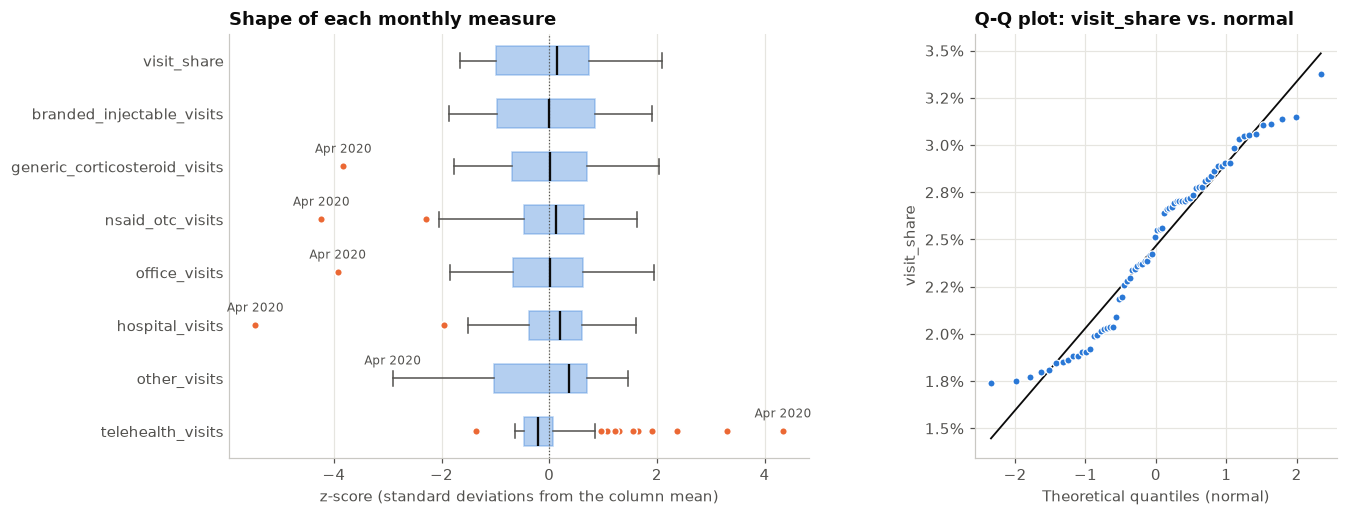

In [19]:
z = (gold[MONTHLY_MEASURES] - gold[MONTHLY_MEASURES].mean()) / gold[MONTHLY_MEASURES].std()

fig, (ax_b, ax_q) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.6, 1], "wspace": 0.35})

order = MONTHLY_MEASURES[::-1]
bp = ax_b.boxplot([z[c] for c in order], vert=False, widths=0.55, patch_artist=True,
                  medianprops=dict(color=INK, lw=1.5), whiskerprops=dict(color=MUTED),
                  capprops=dict(color=MUTED),
                  flierprops=dict(marker="o", markersize=5, markerfacecolor=PALETTE[1],
                                  markeredgecolor="white"))
for patch in bp["boxes"]:
    patch.set(facecolor=PALETTE[0], alpha=0.35, edgecolor=PALETTE[0])
ax_b.set_yticks(range(1, len(order) + 1), order)
ax_b.axvline(0, color=MUTED, lw=0.8, ls=":")
ax_b.set_xlabel("z-score (standard deviations from the column mean)")
ax_b.set_title("Shape of each monthly measure")
ax_b.grid(axis="y", visible=False)
ax_b.tick_params(axis="y", length=0)

# Label April 2020 where it is the extreme point
apr = z.loc[~no_covid].iloc[0]
for y, c in enumerate(order, start=1):
    if abs(apr[c]) > 2.5:
        ax_b.annotate("Apr 2020", xy=(apr[c], y), xytext=(0, 9), textcoords="offset points",
                      ha="center", fontsize=8, color=MUTED)

(osm, osr), (slope, intercept, _) = stats.probplot(gold["visit_share"], dist="norm")
ax_q.scatter(osm, osr, s=22, color=PALETTE[0], edgecolor="white", linewidth=0.8, zorder=3)
ax_q.plot(osm, slope * np.array(osm) + intercept, color=INK, lw=1.2)
ax_q.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
ax_q.set_xlabel("Theoretical quantiles (normal)")
ax_q.set_ylabel("visit_share")
ax_q.set_title("Q-Q plot: visit_share vs. normal")
plt.show()

### 4.2 Row-level counts: effect of a log transform

Section 2 showed that the row-level counts have long right tails. A **log transform**, `log(1 + x)`, compresses large values and is the standard fix. The `1 +` keeps zeros valid. The table and chart compare skew before and after.

,skew_raw,skew_log1p
fact_product_visits.patient_visits,8.98,1.10
gold_segment_adoption.total_category_visits,5.11,0.76
gold_segment_adoption.branded_injectable_visits,5.45,1.69


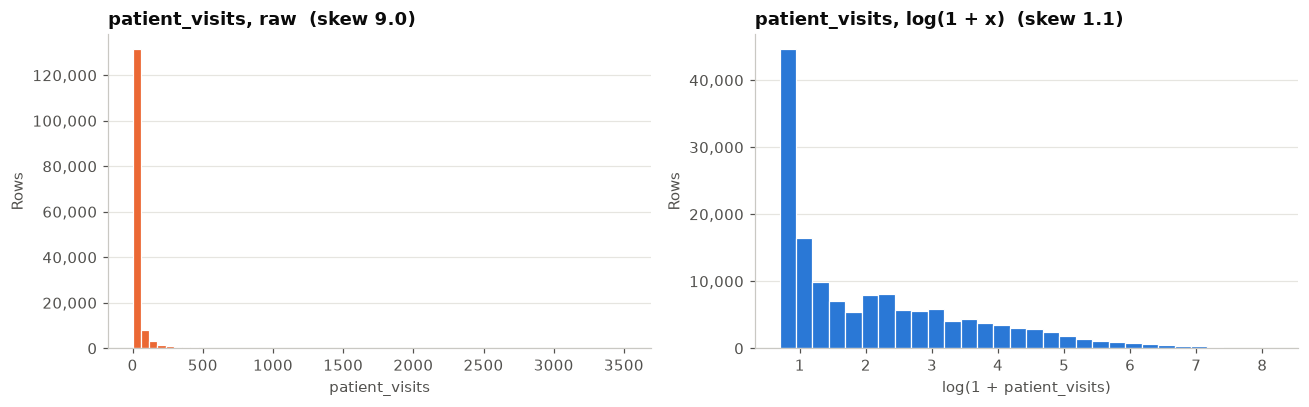

In [20]:
seg_full = pd.read_sql("SELECT * FROM gold_segment_adoption", conn)
row_counts = {
    "fact_product_visits.patient_visits": fpv,
    "gold_segment_adoption.total_category_visits": seg_full["total_category_visits"],
    "gold_segment_adoption.branded_injectable_visits": seg_full["branded_injectable_visits"],
}
log_skew = pd.DataFrame({"skew_raw": {k: v.skew() for k, v in row_counts.items()},
                         "skew_log1p": {k: np.log1p(v).skew() for k, v in row_counts.items()}})
display(log_skew.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(fpv, bins=60, color=PALETTE[1], edgecolor="white", linewidth=0.8)
axes[0].set_title(f"patient_visits, raw  (skew {fpv.skew():.1f})")
axes[1].hist(np.log1p(fpv), bins=30, color=PALETTE[0], edgecolor="white", linewidth=0.8)
axes[1].set_title(f"patient_visits, log(1 + x)  (skew {np.log1p(fpv).skew():.1f})")
for ax in axes:
    ax.set_ylabel("Rows")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax.grid(axis="x", visible=False)
axes[0].set_xlabel("patient_visits")
axes[1].set_xlabel("log(1 + patient_visits)")
fig.tight_layout()
plt.show()

### 4.3 How visits are distributed across categories

This shows which specialties, age groups, genders and care settings the **total patient visits** come from. Sources: `fact_product_visits` for the first three and `fact_place_of_service_visits` for setting. Specialties outside the top 10 are grouped as "All others".

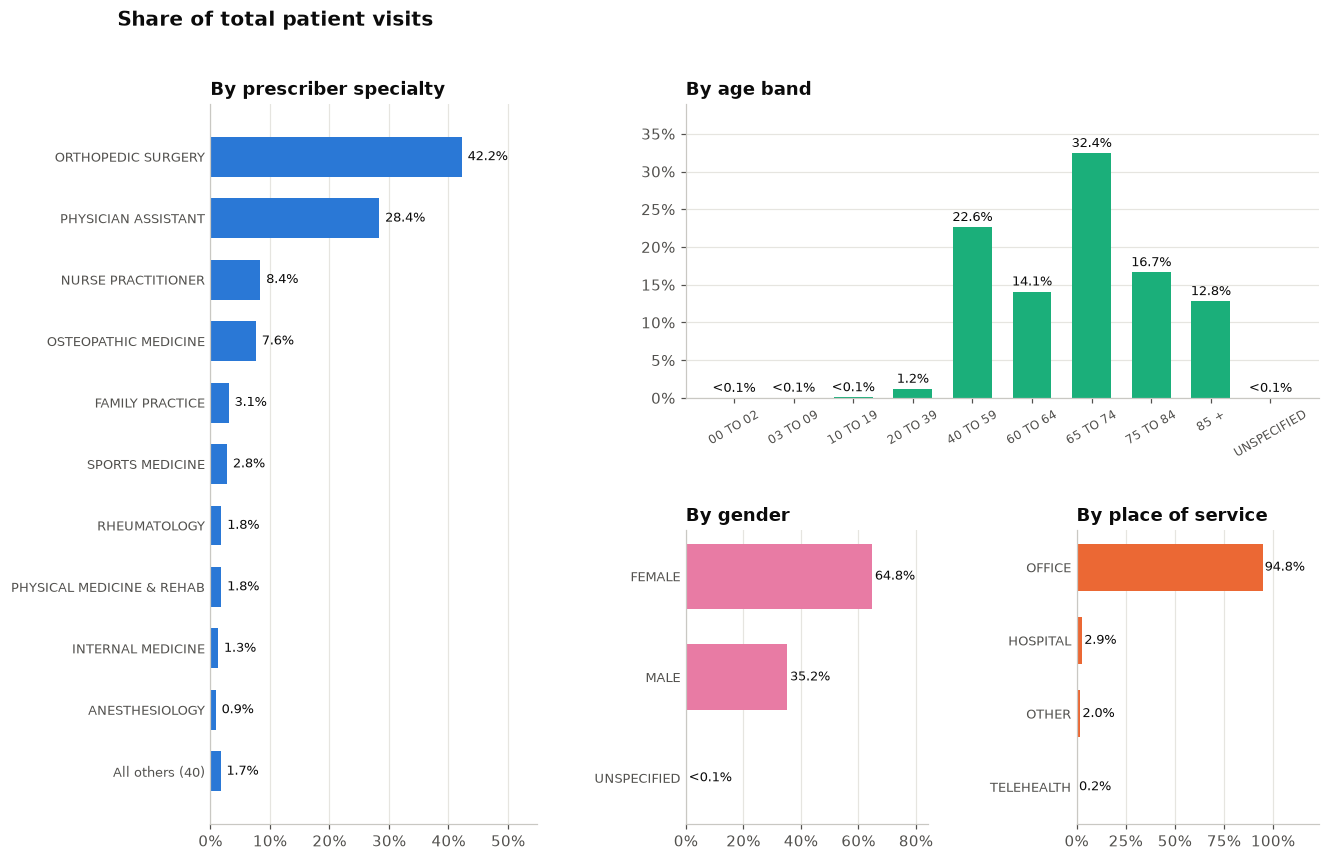

In [21]:
fact = pd.read_sql(
    """SELECT f.patient_visits, s.specialty_name, d.age_band, d.gender
       FROM fact_product_visits f
       JOIN dim_specialty s USING (specialty_id)
       JOIN dim_demographics d USING (demographic_id)""", conn)
pos = pd.read_sql("SELECT place_of_service, SUM(patient_visits) AS visits "
                  "FROM fact_place_of_service_visits GROUP BY place_of_service", conn)

def share_by(col):
    s = fact.groupby(col)["patient_visits"].sum()
    return s / s.sum()

spec = share_by("specialty_name").sort_values(ascending=False)
spec = pd.concat([spec.head(10), pd.Series({"All others (40)": spec.iloc[10:].sum()})])
AGE_ORDER = ["00 TO 02", "03 TO 09", "10 TO 19", "20 TO 39", "40 TO 59",
             "60 TO 64", "65 TO 74", "75 TO 84", "85 +", "UNSPECIFIED"]
age = share_by("age_band").reindex(AGE_ORDER)
gender = share_by("gender").sort_values(ascending=False)
setting = (pos.set_index("place_of_service")["visits"] / pos["visits"].sum()).sort_values(ascending=False)

category_shares = pd.concat({"specialty": spec, "age_band": age, "gender": gender,
                             "place_of_service": setting}).rename("share_of_visits")
display(category_shares.to_frame().style.format("{:.1%}"))

fig = plt.figure(figsize=(13, 8.5))
gs = fig.add_gridspec(2, 3, width_ratios=[1.35, 1, 1], hspace=0.45, wspace=0.55)

def hbar(ax, s, color, title):
    s = s.iloc[::-1]
    ax.barh(s.index, s.values, color=color, height=0.65)
    for y, v in enumerate(s.values):
        ax.text(v + 0.01, y, f"{v:.1%}" if v >= 0.001 else "<0.1%", va="center", fontsize=8.5, color=INK)
    ax.set_xlim(0, max(s.max() * 1.3, 0.1))
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", length=0, labelsize=8.5)

hbar(fig.add_subplot(gs[:, 0]), spec, PALETTE[0], "By prescriber specialty")

ax_age = fig.add_subplot(gs[0, 1:])
ax_age.bar(age.index, age.values, color=PALETTE[2], width=0.65)
for x, v in enumerate(age.values):
    ax_age.text(x, v + 0.008, f"{v:.1%}" if v >= 0.001 else "<0.1%", ha="center", fontsize=8.5, color=INK)
ax_age.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax_age.set_ylim(0, age.max() * 1.2)
ax_age.set_title("By age band")
ax_age.grid(axis="x", visible=False)
ax_age.tick_params(axis="x", labelsize=8, rotation=30)

hbar(fig.add_subplot(gs[1, 1]), gender, PALETTE[4], "By gender")
hbar(fig.add_subplot(gs[1, 2]), setting, PALETTE[1], "By place of service")
fig.suptitle("Share of total patient visits", x=0.06, ha="left", fontsize=13, fontweight="bold", color=INK)
plt.show()

**Read-out:**

- **No monthly measure is cleanly normal.** Only generic corticosteroid visits and office visits pass the normality test, and only once April 2020 is removed. That one COVID month creates the long left tails in NSAID, office and hospital visits (hospital kurtosis 11.5), so it should be treated explicitly: flag it, cap it or exclude it.
- **The target `visit_share` is flat, not bell-shaped.** Skew is about 0 but kurtosis is −1.1, and the Q-Q plot bends into an S rather than following the line. This fits the two regimes seen in the time series: a low-share period (~1.8–2.2%) and a high-share period (~2.7–2.9%). Zilretta visits have the same shape.
- **Telehealth is right-skewed (skew 1.9).** It is close to zero for most months, with a spike during COVID.
- **The log transform fixes most of the row-level skew.** `patient_visits` goes from skew **9.0 to 1.1**, and `total_category_visits` from 5.1 to 0.8. Segment-level `branded_injectable_visits` stays skewed (1.7) because 65% of it is zeros.
- **Visits are highly concentrated by specialty.** Orthopedic surgery (42%) and physician assistants (28%) account for **70%** of visits. The top 4, adding nurse practitioners and osteopathic medicine, make up 87%, and the remaining 40 specialties together are only 1.7%.
- **Patients are older and mostly female.** 65–74 is the largest age band (32%), and 40+ accounts for about 99% of visits. Women make up 65% of visits, which is consistent with knee OA. Children's bands and UNSPECIFIED are effectively empty.
- **Care happens almost entirely in the office (95%).** Hospital (3%), other (2%) and telehealth (0.2%) settings are minor.

## 5. Missing values

Data can be missing in three ways, and each needs a different check:

1. **Explicit NULLs:** a cell exists but holds no value.
2. **Missing rows:** a combination that should be present (e.g. a month × setting) has no row at all.
3. **Placeholder values:** the cell is filled, but with a stand-in such as `UNSPECIFIED` or `OTHER` that carries no real information.

### 5.1 Explicit NULLs

Every column in every table is checked. Only columns with at least one NULL are listed; all others are 100% complete. Each is tagged with the **reason** it is missing, because that decides the fix.

In [22]:
null_rows = []
for t in tables:
    df = pd.read_sql(f"SELECT * FROM {t}", conn)
    for col in df.columns:
        n = df[col].isna().sum()
        if n:
            null_rows.append({"table": t, "column": col, "missing": n, "rows": len(df),
                              "missing_%": n / len(df) * 100})
nulls = pd.DataFrame(null_rows)

REASONS = {
    "fda_approval_date": "Only filled for the branded product",
    "direction_label": "Undefined for the first month (no prior month)",
    "visit_share_lag_1": "Start of series (not enough history)",
    "visit_share_lag_2": "Start of series (not enough history)",
    "visit_share_lag_3": "Start of series (not enough history)",
    "visit_share_roll_3mo": "Start of series (not enough history)",
    "visit_share_roll_6mo": "Start of series (not enough history)",
}
nulls["reason"] = nulls["column"].map(REASONS).fillna("Never populated (placeholder for modelling output)")
total_cells = sum(r * c for r, c in zip(shapes["rows"], shapes["columns"]))
print(f"{len(nulls)} of {len(dtypes)} columns have NULLs; "
      f"{nulls['missing'].sum():,} NULL cells out of {total_cells:,} ({nulls['missing'].sum() / total_cells:.2%})")
nulls.style.format({"missing_%": "{:.1f}", "missing": "{:,}", "rows": "{:,}"}).hide(axis="index")

12 of 57 columns have NULLs; 22,111 NULL cells out of 901,690 (2.45%)


table,column,missing,rows,missing_%,reason
dim_product,fda_approval_date,159,160,99.4,Only filled for the branded product
gold_segment_adoption,adoption_label,"21,636","21,636",100.0,Never populated (placeholder for modelling output)
gold_visit_share_monthly,direction_label,13,72,18.1,Undefined for the first month (no prior month)
gold_visit_share_monthly,visit_share_lag_1,1,72,1.4,Start of series (not enough history)
gold_visit_share_monthly,visit_share_lag_2,2,72,2.8,Start of series (not enough history)
gold_visit_share_monthly,visit_share_lag_3,3,72,4.2,Start of series (not enough history)
gold_visit_share_monthly,visit_share_roll_3mo,3,72,4.2,Start of series (not enough history)
gold_visit_share_monthly,visit_share_roll_6mo,6,72,8.3,Start of series (not enough history)
gold_visit_share_monthly,predicted_direction,72,72,100.0,Never populated (placeholder for modelling output)
gold_visit_share_monthly,prediction_probability,72,72,100.0,Never populated (placeholder for modelling output)


**Left:** % missing per column, coloured by reason. **Right:** where the NULLs sit over time in `gold_visit_share_monthly`, with each dark cell a missing value. The heatmap shows whether gaps are scattered at random or follow a structure.

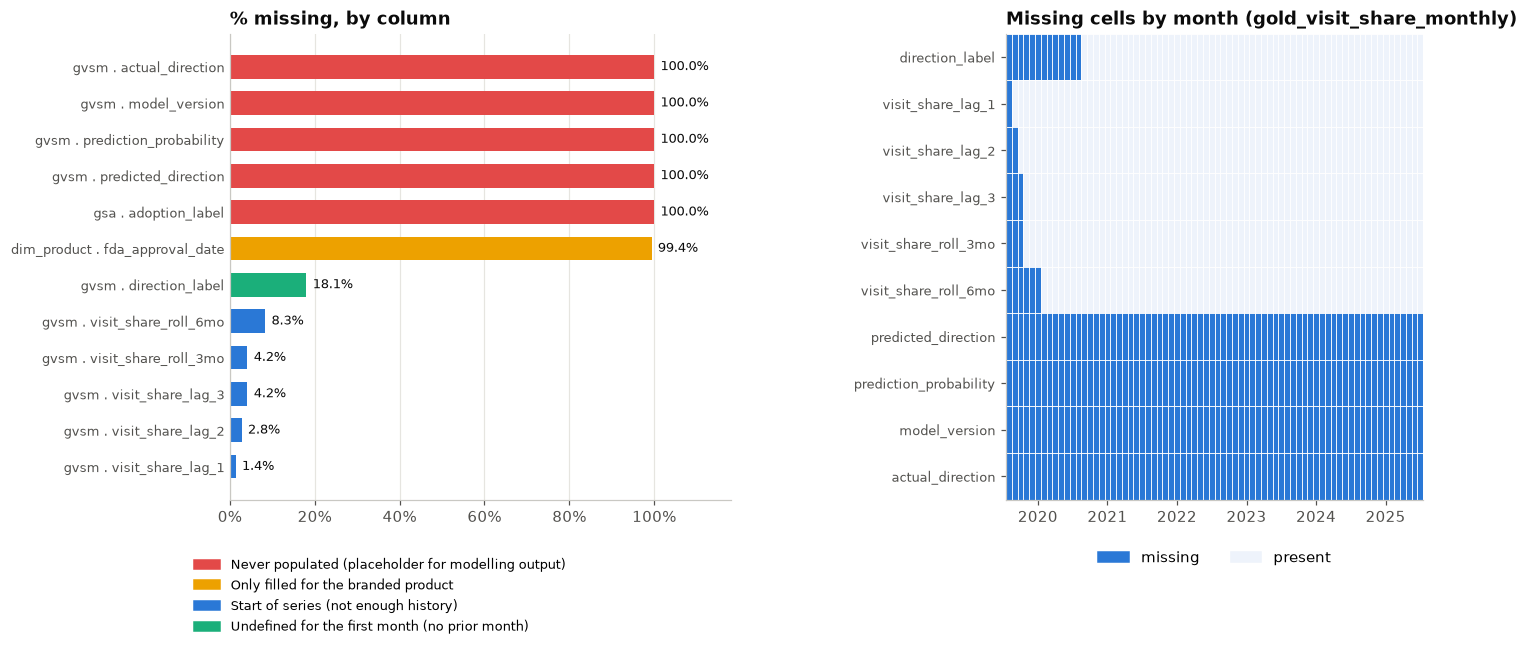

In [23]:
reason_colors = {
    "Never populated (placeholder for modelling output)": PALETTE[7],
    "Only filled for the branded product": PALETTE[3],
    "Start of series (not enough history)": PALETTE[0],
    "Undefined for the first month (no prior month)": PALETTE[2],
}
plot_nulls = nulls.sort_values("missing_%")
labels = plot_nulls["table"].str.replace("gold_visit_share_monthly", "gvsm") \
         .str.replace("gold_segment_adoption", "gsa") + " . " + plot_nulls["column"]

fig, (ax_b, ax_h) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.2, 1], "wspace": 0.6})

ax_b.barh(labels, plot_nulls["missing_%"], color=plot_nulls["reason"].map(reason_colors), height=0.65)
for y, v in enumerate(plot_nulls["missing_%"]):
    ax_b.text(v + 1.5, y, f"{v:.1f}%", va="center", fontsize=8.5, color=INK)
ax_b.set_xlim(0, 118)
ax_b.xaxis.set_major_formatter(mtick.PercentFormatter(100))
ax_b.set_title("% missing, by column")
ax_b.grid(axis="y", visible=False)
ax_b.tick_params(axis="y", length=0, labelsize=8.5)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in reason_colors.values()]
ax_b.legend(handles, reason_colors.keys(), loc="upper center", bbox_to_anchor=(0.3, -0.1),
            ncol=1, frameon=False, fontsize=8.5)

gvsm_cols = nulls.loc[nulls["table"] == "gold_visit_share_monthly", "column"].tolist()
miss = gold.set_index("calendar_date")[gvsm_cols].isna().astype(int)
ax_h.imshow(miss.T.values, aspect="auto", cmap=plt.matplotlib.colors.ListedColormap(["#eef3fb", PALETTE[0]]),
            interpolation="nearest")
ax_h.set_yticks(range(len(gvsm_cols)), gvsm_cols, fontsize=8.5)
tick_idx = [i for i, d in enumerate(miss.index) if d.month == 1] # January of each year
ax_h.set_xticks(tick_idx, [miss.index[i].year for i in tick_idx])
ax_h.set_xticks(np.arange(-0.5, len(miss), 1), minor=True)
ax_h.set_yticks(np.arange(-0.5, len(gvsm_cols), 1), minor=True)
ax_h.grid(which="minor", color="white", linewidth=0.6)
ax_h.grid(which="major", visible=False)
ax_h.tick_params(which="minor", length=0)
ax_h.set_title("Missing cells by month (gold_visit_share_monthly)")
ax_h.legend([plt.Rectangle((0, 0), 1, 1, color=PALETTE[0]), plt.Rectangle((0, 0), 1, 1, color="#eef3fb")],
            ["missing", "present"], loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
plt.show()

### 5.2 Missing rows and placeholder values

These gaps do not appear as NULLs, so they need targeted checks:

- **Missing rows:** month × setting combinations absent from `fact_place_of_service_visits`, months absent from any fact table, and dimension members (products, specialties, demographic groups) that never appear in the visit data.
- **Placeholder values:** visits recorded under `UNSPECIFIED` gender/age the catch-all `OTHER` specialty or a `No Manufacturer` product, and products tagged `OTHER` for brand/generic.

In [24]:
checks = {}

# Month x setting combinations with no row
checks["missing month × setting rows"] = pd.read_sql(
    """SELECT m.month_id, s.place_of_service
       FROM dim_month m
       CROSS JOIN (SELECT DISTINCT place_of_service FROM fact_place_of_service_visits) s
       LEFT JOIN fact_place_of_service_visits f
              ON f.month_id = m.month_id AND f.place_of_service = s.place_of_service
       WHERE f.month_id IS NULL""", conn)

# Months present in each fact / gold table (72 expected)
checks["months covered per table"] = pd.DataFrame(
    {t: [pd.read_sql(f"SELECT COUNT(DISTINCT month_id) AS n FROM {t}", conn)["n"][0]]
     for t in ["fact_product_visits", "fact_place_of_service_visits",
               "gold_visit_share_monthly", "gold_segment_adoption"]}, index=["months"])

# Dimension members that never appear in fact_product_visits
checks["products with no visits"] = pd.read_sql(
    """SELECT product_id, product_name, treatment_category, disease_area FROM dim_product
       WHERE product_id NOT IN (SELECT product_id FROM fact_product_visits)""", conn)
for dim, key in [("dim_specialty", "specialty_id"), ("dim_demographics", "demographic_id")]:
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {dim} WHERE {key} NOT IN "
                    f"(SELECT {key} FROM fact_product_visits)", conn)["n"][0]
    print(f"{dim}: {n} members with no visits")

for name, df in checks.items():
    print(f"\n{name}:")
    display(df)

dim_specialty: 0 members with no visits
dim_demographics: 0 members with no visits

missing month × setting rows:


,month_id,place_of_service
0,201909,TELEHEALTH
1,201910,TELEHEALTH



months covered per table:


,fact_product_visits,fact_place_of_service_visits,gold_visit_share_monthly,gold_segment_adoption
months,72,72,72,72



products with no visits:


,product_id,product_name,treatment_category,disease_area
0,59,DURACLON,opioid_other,OA
1,136,SAPHNELO,not_applicable,RA


In [25]:
total_visits = fact["patient_visits"].sum()
placeholders = pd.DataFrame([
    {"placeholder": "gender = UNSPECIFIED", "visits": fact.loc[fact["gender"] == "UNSPECIFIED", "patient_visits"].sum()},
    {"placeholder": "age_band = UNSPECIFIED", "visits": fact.loc[fact["age_band"] == "UNSPECIFIED", "patient_visits"].sum()},
    {"placeholder": "specialty = OTHER", "visits": fact.loc[fact["specialty_name"] == "OTHER", "patient_visits"].sum()},
    {"placeholder": "manufacturer = No Manufacturer", "visits": pd.read_sql(
        """SELECT COALESCE(SUM(f.patient_visits), 0) AS v FROM fact_product_visits f
           JOIN dim_product p USING (product_id) WHERE p.manufacturer = 'No Manufacturer'""", conn)["v"][0]},
])
placeholders["share_of_visits_%"] = placeholders["visits"] / total_visits * 100

tag_other = pd.read_sql(
    """SELECT p.treatment_category, COUNT(DISTINCT p.product_id) AS products_tagged_OTHER,
              COALESCE(SUM(f.patient_visits), 0) AS visits
       FROM dim_product p LEFT JOIN fact_product_visits f USING (product_id)
       WHERE p.brand_generic_tag = 'OTHER' GROUP BY p.treatment_category""", conn)
tag_other["share_of_visits_%"] = tag_other["visits"] / total_visits * 100

display(placeholders.style.format({"visits": "{:,}", "share_of_visits_%": "{:.3f}"}).hide(axis="index"))
display(tag_other.style.format({"visits": "{:,}", "share_of_visits_%": "{:.2f}"}).hide(axis="index"))

placeholder,visits,share_of_visits_%
gender = UNSPECIFIED,621,0.011
age_band = UNSPECIFIED,70,0.001
specialty = OTHER,"10,037",0.181
manufacturer = No Manufacturer,94,0.002


treatment_category,products_tagged_OTHER,visits,share_of_visits_%
nsaid_otc,46,"390,680",7.04


The chart puts every "hidden" gap on one scale: the share of total patient visits it affects.

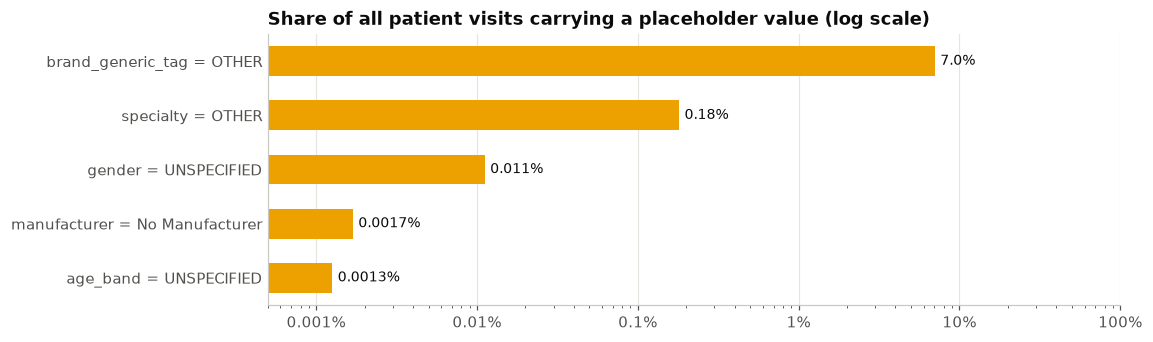

In [26]:
hidden = pd.concat([
    placeholders.set_index("placeholder")["share_of_visits_%"],
    pd.Series({"brand_generic_tag = OTHER": tag_other["share_of_visits_%"].sum()}),
]).sort_values()

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.barh(hidden.index, hidden.values, color=PALETTE[3], height=0.55)
for y, v in enumerate(hidden.values):
    ax.text(v * 1.08, y, f"{v:.1f}%" if v >= 1 else f"{v:.2g}%", va="center", fontsize=9, color=INK)
ax.set_xscale("log")
ax.set_xlim(0.0005, 100)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}%"))
ax.set_title("Share of all patient visits carrying a placeholder value (log scale)")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
plt.show()

**Read-out:**

- **The measurement data is complete.** No visit count, share or key has a single NULL. The 22,111 NULL cells (2.45% of all cells) sit in 12 of 57 columns, and **every one has a known cause.** None are random gaps. 99% of them come from the never-populated columns below; excluding those, only 187 cells are missing.
- **The NULLs in the 5 lag/rolling columns are structural.** They occur only at the start of the series, as the heatmap shows. The right fix is to drop the first 6 months when training on these features (13 in practice, once the label's 12-month volatility window is included), not to impute them.
- **`direction_label` is missing for the first 13 months.** Aug 2019 has no earlier month to compare against, and the next 12 months have no full trailing 12-month window for the volatility baseline (section 12.4). Like the lag/rolling NULLs this is structural: train only on the 59 labelled months.
- **Five columns are 100% empty because they were never populated:** `predicted_direction`, `prediction_probability`, `model_version`, `actual_direction` and `adoption_label`. They are placeholders for later pipeline steps and can be ignored in EDA.
- **`fda_approval_date` is filled only for Zilretta** (99.4% missing). It is not needed for the other 159 generic/OTC products.
- **Missing rows:**
  - `fact_place_of_service_visits` has no TELEHEALTH row for **Sep and Oct 2019**. The gold table records these as `0`, which is the correct reading since telehealth was near zero pre-COVID.
  - All 72 months are present in every fact and gold table.
  - **2 products** in `dim_product` never appear in the visit data (DURACLON, an OA opioid, and SAPHNELO, an RA drug); they are unused lookup entries.
- **Placeholders are negligible in the visit data.** UNSPECIFIED gender or age, the OTHER specialty and `manufacturer = 'No Manufacturer'` (4 products, 94 visits) together cover under 0.2% of visits, too small to bias any breakdown. Note that `manufacturer` has no NULLs (section 6) only because missing values were filled with the text `'No Manufacturer'`.
- **The one placeholder that matters is `brand_generic_tag = OTHER`.** It covers 46 of 160 products (all NSAID/OTC, 7% of visits), so that column is not a reliable brand/generic flag. Use `treatment_category` instead, which is fully populated.

## 6. Null values

Section 5.1 counted the NULL cells that exist today. This section asks two further questions about nulls:

1. **Which columns are allowed to be NULL?** The schema declares each column either `NOT NULL`, where the database rejects a NULL on insert, or nullable. A nullable column that is complete today can still receive NULLs in a future data load.
2. **Are there disguised nulls?** These are values that are not SQL NULL but mean "no value": empty or whitespace-only strings, text such as `'NULL'`, `'N/A'` or `'nan'`, infinite numbers, zeros that may stand in for "unknown", and columns that mix storage types (e.g. numbers stored as text in some rows).

### 6.1 Schema nullability vs. actual NULLs

In [27]:
null_status = []
for t in tables:
    info = pd.read_sql(f"PRAGMA table_info({t})", conn)
    df = pd.read_sql(f"SELECT * FROM {t}", conn)
    for _, r in info.iterrows():
        n_null = df[r["name"]].isna().sum()
        if r["notnull"] or r["pk"]:
            status = "NOT NULL enforced"
        elif n_null:
            status = "Nullable – has NULLs"
        else:
            status = "Nullable – complete today"
        null_status.append({"table": t, "column": r["name"], "declared_not_null": bool(r["notnull"] or r["pk"]),
                            "null_count": n_null, "status": status})
null_status = pd.DataFrame(null_status)

print(null_status["status"].value_counts().to_string(), "\n")
print("Nullable columns (NULLs are allowed by the schema):")
null_status[~null_status["declared_not_null"]].reset_index(drop=True)

status
NOT NULL enforced            36
Nullable – has NULLs         12
Nullable – complete today     9 

Nullable columns (NULLs are allowed by the schema):


,table,column,declared_not_null,null_count,status
0,dim_product,manufacturer,False,0,Nullable – complete today
1,dim_product,fda_approval_date,False,159,Nullable – has NULLs
2,gold_segment_adoption,adoption_label,False,21636,Nullable – has NULLs
3,gold_visit_share_monthly,direction_label,False,13,Nullable – has NULLs
4,gold_visit_share_monthly,visit_share_lag_1,False,1,Nullable – has NULLs
5,gold_visit_share_monthly,visit_share_lag_2,False,2,Nullable – has NULLs
6,gold_visit_share_monthly,visit_share_lag_3,False,3,Nullable – has NULLs
7,gold_visit_share_monthly,visit_share_roll_3mo,False,3,Nullable – has NULLs
8,gold_visit_share_monthly,visit_share_roll_6mo,False,6,Nullable – has NULLs
9,gold_visit_share_monthly,months_since_launch,False,0,Nullable – complete today


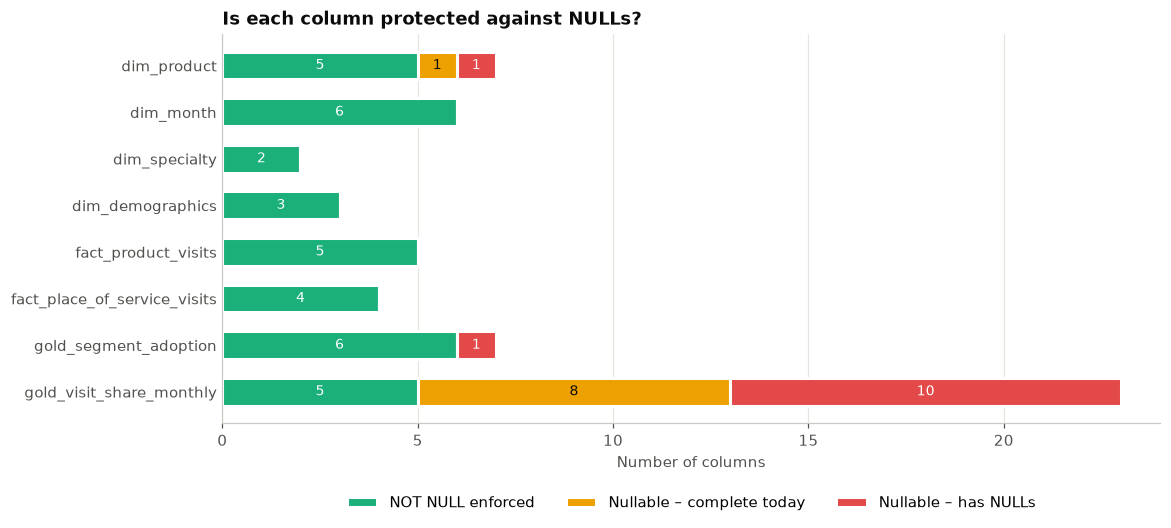

In [28]:
STATUS_ORDER = ["NOT NULL enforced", "Nullable – complete today", "Nullable – has NULLs"]
status_colors = dict(zip(STATUS_ORDER, [PALETTE[2], PALETTE[3], PALETTE[7]]))

status_counts = (null_status.pivot_table(index="table", columns="status", values="column",
                                         aggfunc="count", fill_value=0)
                 .reindex(columns=STATUS_ORDER, fill_value=0)
                 .loc[shapes["table"]].iloc[::-1])

fig, ax = plt.subplots(figsize=(11, 4.6))
left = np.zeros(len(status_counts))
for s in STATUS_ORDER:
    vals = status_counts[s].values
    ax.barh(status_counts.index, vals, left=left, color=status_colors[s], height=0.6,
            edgecolor="white", linewidth=2, label=s)
    for y, (l, v) in enumerate(zip(left, vals)):
        if v:
            ax.text(l + v / 2, y, str(v), ha="center", va="center", fontsize=9,
                    color=INK if s == "Nullable – complete today" else "white")
    left += vals
ax.set_xlim(0, 24)
ax.set_xlabel("Number of columns")
ax.set_title("Is each column protected against NULLs?")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.show()

### 6.2 Disguised nulls

Every column is scanned for:

- null-like text tokens;
- empty or whitespace-only strings;
- infinite values;
- mixed storage types, using SQLite's `typeof()`;
- zeros in count columns.

A zero can be a genuine "none happened" or a stand-in for "unknown".

In [29]:
NULL_TOKENS = {"", "NULL", "NONE", "NAN", "N/A", "NA", "NIL", "-", "?", "UNKNOWN"}

disguised = []
for t in tables:
    df = pd.read_sql(f"SELECT * FROM {t}", conn)
    for col in df.columns:
        s = df[col].dropna()
        types = pd.read_sql(f"SELECT DISTINCT typeof({col}) AS t FROM {t}", conn)["t"]
        text = s[s.map(lambda v: isinstance(v, str))].astype(str)
        is_num = pd.api.types.is_numeric_dtype(s) and len(s)
        disguised.append({
            "table": t, "column": col,
            "storage_types": ", ".join(sorted(types)),
            "null_like_text": text.str.strip().str.upper().isin(NULL_TOKENS).sum(),
            "infinite": int(np.isinf(s.astype(float)).sum()) if is_num else 0,
            "zeros": int((s == 0).sum()) if is_num and not col.endswith("_id") else 0,
            "zeros_%": (s == 0).mean() * 100 if is_num and not col.endswith("_id") else 0.0,
        })
disguised = pd.DataFrame(disguised)
mixed = disguised["storage_types"].str.replace("null, ", "").str.contains(",")

print(f"Null-like text values : {disguised['null_like_text'].sum()}")
print(f"Infinite values       : {disguised['infinite'].sum()}")
print(f"Mixed-type columns    : {mixed.sum()}  (ignoring NULL itself)")
print("\nColumns containing zeros:")
disguised.loc[disguised["zeros"] > 0, ["table", "column", "storage_types", "zeros", "zeros_%"]] \
    .style.format({"zeros": "{:,}", "zeros_%": "{:.1f}"}).hide(axis="index")

Null-like text values : 0
Infinite values       : 0
Mixed-type columns    : 0  (ignoring NULL itself)

Columns containing zeros:


table,column,storage_types,zeros,zeros_%
gold_segment_adoption,branded_injectable_visits,integer,"14,154",65.4
gold_segment_adoption,segment_visit_share,real,"14,154",65.4
gold_visit_share_monthly,telehealth_visits,integer,2,2.8


The chart shows the % of zeros in every count and share column of the fact and gold tables. Most are 0%. The few with zeros need a judgement call: is a zero real, or does it mean "no data"?

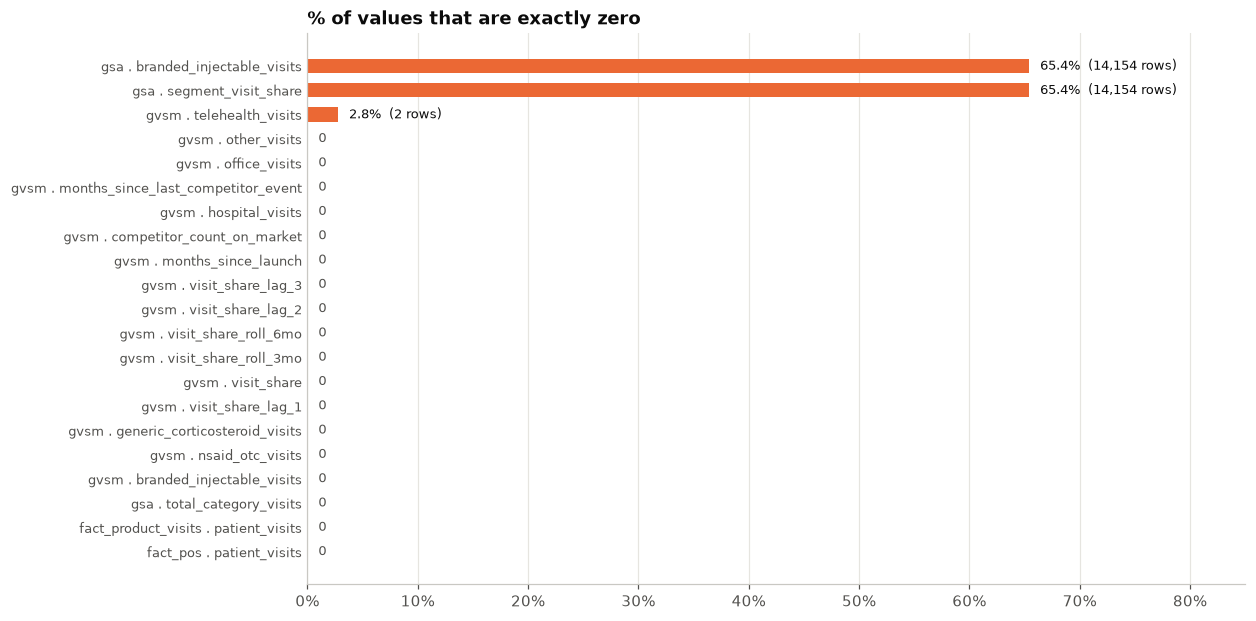

In [30]:
zero_cols = disguised[
    disguised["table"].str.startswith(("fact", "gold"))
    & dtypes.set_index(["table", "column"]).loc[list(zip(disguised["table"], disguised["column"])),
                                                "semantic_type"].str.startswith("Numerical").values
].copy()
zero_cols = zero_cols[zero_cols["storage_types"] != "null"]   # skip never-populated columns
zero_cols["label"] = zero_cols["table"].str.replace("gold_visit_share_monthly", "gvsm") \
    .str.replace("gold_segment_adoption", "gsa").str.replace("fact_place_of_service_visits", "fact_pos") \
    + " . " + zero_cols["column"]
zero_cols = zero_cols.sort_values("zeros_%")

fig, ax = plt.subplots(figsize=(11, 6.5))
colors = [PALETTE[1] if v > 0 else "#d9d8d3" for v in zero_cols["zeros_%"]]
ax.barh(zero_cols["label"], zero_cols["zeros_%"], color=colors, height=0.6)
for y, (v, n) in enumerate(zip(zero_cols["zeros_%"], zero_cols["zeros"])):
    ax.text(v + 1, y, f"{v:.1f}%  ({n:,} rows)" if v else "0", va="center", fontsize=8.5,
            color=INK if v else MUTED)
ax.set_xlim(0, 85)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(100))
ax.set_title("% of values that are exactly zero")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0, labelsize=8.5)
plt.show()

**Read-out:**

- **The core data is protected by the schema.** 36 of 57 columns are declared `NOT NULL`, including every key, every raw visit count in the fact tables and the target `visit_share`, so the database itself would reject a NULL there.
- **12 nullable columns hold NULLs today.** These are exactly the ones explained in section 5.1 (start-of-series lags, first-month label, unpopulated modelling outputs, `fda_approval_date`).
- **9 nullable columns are complete today but unguarded:**
  - `manufacturer`
  - `months_since_launch`, `is_post_launch`, `competitor_count_on_market` and `months_since_last_competitor_event`
  - the four place-of-service counts in `gold_visit_share_monthly`

  Nothing is wrong with them now, but a future load could leave them NULL without an error, so the modelling code should assert they are complete.
- **No disguised nulls.** There are no empty strings, no `'NULL'`/`'N/A'`/`'nan'` text and no infinite values. No column mixes storage types: every column holds one type (plus NULL where noted), so numbers are never stored as text.
- **Zeros:**
  - **`telehealth_visits` = 0 in Sep and Oct 2019** is a filled-in gap. Those months have no row in `fact_place_of_service_visits` (section 5.2), and the gold table records them as 0. This is reasonable pre-COVID, but it is an assumption, not an observation.
  - **65.4% zeros in segment `branded_injectable_visits` and `segment_visit_share` are genuine.** Every segment has at least 1 category visit (`total_category_visits` min = 1), so a zero means "patients were seen, but none got Zilretta", not missing data. It also means the share never divides by zero.
  - **All other count columns have no zeros.** In `fact_product_visits`, zero-visit combinations are omitted as rows rather than stored as 0 (section 1).

## 7. Duplicates

Duplicates double-count visits and distort shares, so four levels are checked:

1. **Exact duplicate rows:** the same row appears twice.
2. **Duplicate keys:** two rows share the same primary key (the same month × product × specialty × demographic, for example) but have different values. This is the more dangerous case, because the rows don't look identical.
3. **Duplicate columns:** two columns in a table hold exactly the same data.
4. **Near-duplicate names:** the same product, specialty or manufacturer entered twice with slightly different spelling, which would split its visits across two IDs.

### 7.1 Duplicate rows, keys and columns

In [31]:
dup_rows = []
identical_pairs = []
for t in tables:
    df = pd.read_sql(f"SELECT * FROM {t}", conn)
    info = pd.read_sql(f"PRAGMA table_info({t})", conn)
    pk = info.loc[info["pk"] > 0].sort_values("pk")["name"].tolist()
    filled = [c for c in df.columns if df[c].notna().any()]   # ignore never-populated columns
    pairs = [(a, b) for a, b in itertools.combinations(filled, 2) if df[a].equals(df[b])]
    identical_pairs += [{"table": t, "column_a": a, "column_b": b} for a, b in pairs]
    dup_rows.append({"table": t, "primary_key": ", ".join(pk), "rows": len(df),
                     "exact_duplicate_rows": df.duplicated().sum(),
                     "duplicate_keys": df.duplicated(subset=pk).sum(),
                     "identical_column_pairs": len(pairs)})
dup_rows = pd.DataFrame(dup_rows).set_index("table").loc[shapes["table"]]
display(dup_rows)

print("Identical column pairs:")
identical_pairs = pd.DataFrame(identical_pairs)
identical_pairs

,primary_key,rows,exact_duplicate_rows,duplicate_keys,identical_column_pairs
table,,,,,
dim_product,product_id,160,0,0,0
dim_month,month_id,72,0,0,0
dim_specialty,specialty_id,50,0,0,0
dim_demographics,demographic_id,27,0,0,0
fact_product_visits,"month_id, product_id, specialty_id, demographi...",149141,0,0,0
fact_place_of_service_visits,"month_id, disease_area, place_of_service",286,0,0,0
gold_segment_adoption,"month_id, specialty_id, demographic_id",21636,0,0,0
gold_visit_share_monthly,month_id,72,0,0,2


Identical column pairs:


,table,column_a,column_b
0,gold_visit_share_monthly,months_since_launch,months_since_last_competitor_event
1,gold_visit_share_monthly,is_post_launch,competitor_count_on_market


The chart shows every table against every check. Green means no duplicates found and amber means duplicates found (with the count).

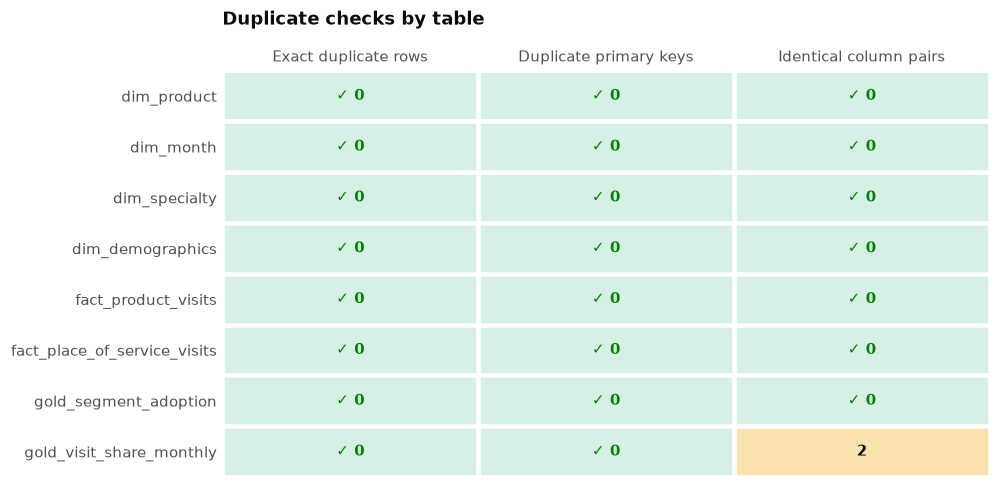

In [32]:
checks_m = dup_rows[["exact_duplicate_rows", "duplicate_keys", "identical_column_pairs"]]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.imshow((checks_m.values > 0).astype(int), aspect="auto", interpolation="nearest",
          cmap=plt.matplotlib.colors.ListedColormap(["#d7f0e5", "#fbe3b0"]))
for (y, x), v in np.ndenumerate(checks_m.values):
    ax.text(x, y, "✓ 0" if v == 0 else f"{v}", ha="center", va="center", fontsize=10,
            color=PALETTE[5] if v == 0 else INK, fontweight="bold")
ax.set_xticks(range(3), ["Exact duplicate rows", "Duplicate primary keys", "Identical column pairs"])
ax.set_yticks(range(len(checks_m)), checks_m.index)
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(checks_m), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=3)
ax.grid(which="major", visible=False)
ax.tick_params(which="both", length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Duplicate checks by table", pad=30)
plt.show()

### 7.2 Near-duplicate names in the dimension tables

Two steps:

1. **Normalised match:** names are upper-cased and stripped of spaces and punctuation, then compared. This catches `"A-Hydrocort"` vs `"A HYDROCORT"`.
2. **Fuzzy match:** every pair of names in a column gets a similarity score from 0 to 1 (`difflib`), and pairs scoring **≥ 0.85** are listed for review. Each pair is then checked by hand: is it the same thing spelled differently, or two genuinely different entries?

In [33]:
def normalise(s):
    return "".join(ch for ch in str(s).upper() if ch.isalnum())

NAME_COLS = [("dim_product", "product_name"), ("dim_product", "manufacturer"),
             ("dim_specialty", "specialty_name")]
similar = []
for t, col in NAME_COLS:
    names = pd.read_sql(f"SELECT DISTINCT {col} FROM {t}", conn)[col]
    exact_norm = names.map(normalise).duplicated().sum()
    print(f"{t}.{col}: {len(names)} distinct values, {exact_norm} duplicates after normalising")
    for a, b in itertools.combinations(names, 2):
        score = difflib.SequenceMatcher(None, a, b).ratio()
        if score >= 0.85:
            similar.append({"column": col, "name_a": a, "name_b": b, "similarity": round(score, 2)})
similar = pd.DataFrame(similar).sort_values("similarity", ascending=False)

# Manual review of every flagged pair
VERDICT = {
    ("HYDROCORTISONE", "HYDROCORTONE"): "Different product (generic vs. brand)",
    ("POD-CARE 100C", "POD-CARE 100K"): "Different product (variant)",
    ("PRO-C-DURE 5", "PRO-C-DURE 6"): "Different product (kit size)",
    ("PREDNISOLONE", "PREDNISONE"): "Different molecule",
    ("DARVOCET-N 100", "DARVOCET-N 50"): "Different product (strength)",
    ("READYSHARP BETAMET", "READYSHARP DEXAMET"): "Different molecule",
    ("TRAMADOL HCL", "TRAMADOL HCL ER"): "Different product (extended release)",
    ("TRIAMCINOLONE ACTN", "TRIAMCINOLONE DIAC"): "Different salt (acetonide vs. diacetate)",
    ("HYDROCORTISONE", "HYDROCORTISONE VAL"): "Different salt (valerate)",
    ("DARVON", "DARVON-N"): "Different product (napsylate form)",
    ("NAPROXEN SOD (OTC)", "NAPROXEN SOD (RX)"): "Different product (OTC vs. Rx)",
    ("SUN PHARMACEUTICAL", "INA PHARMACEUTICAL"): "Different company",
    ("RHEUMATOLOGY", "HEMATOLOGY"): "Different specialty",
    ("NEUROLOGY", "UROLOGY"): "Different specialty",
    ("DERMATOLOGY", "HEMATOLOGY"): "Different specialty",
}
similar["verdict"] = [VERDICT.get((a, b), VERDICT.get((b, a), "Review")) for a, b in
                      zip(similar["name_a"], similar["name_b"])]
similar.reset_index(drop=True)

dim_product.product_name: 160 distinct values, 0 duplicates after normalising


dim_product.manufacturer: 74 distinct values, 0 duplicates after normalising
dim_specialty.specialty_name: 50 distinct values, 0 duplicates after normalising


,column,name_a,name_b,similarity,verdict
0,product_name,HYDROCORTISONE,HYDROCORTONE,0.92,Different product (generic vs. brand)
1,product_name,POD-CARE 100C,POD-CARE 100K,0.92,Different product (variant)
2,product_name,PRO-C-DURE 5,PRO-C-DURE 6,0.92,Different product (kit size)
3,specialty_name,RHEUMATOLOGY,HEMATOLOGY,0.91,Different specialty
4,product_name,PREDNISOLONE,PREDNISONE,0.91,Different molecule
5,product_name,DARVOCET-N 100,DARVOCET-N 50,0.89,Different product (strength)
6,product_name,TRAMADOL HCL,TRAMADOL HCL ER,0.89,Different product (extended release)
7,product_name,TRIAMCINOLONE ACTN,TRIAMCINOLONE DIAC,0.89,Different salt (acetonide vs. diacetate)
8,manufacturer,SUN PHARMACEUTICAL,INA PHARMACEUTICAL,0.89,Different company
9,product_name,READYSHARP BETAMET,READYSHARP DEXAMET,0.89,Different molecule


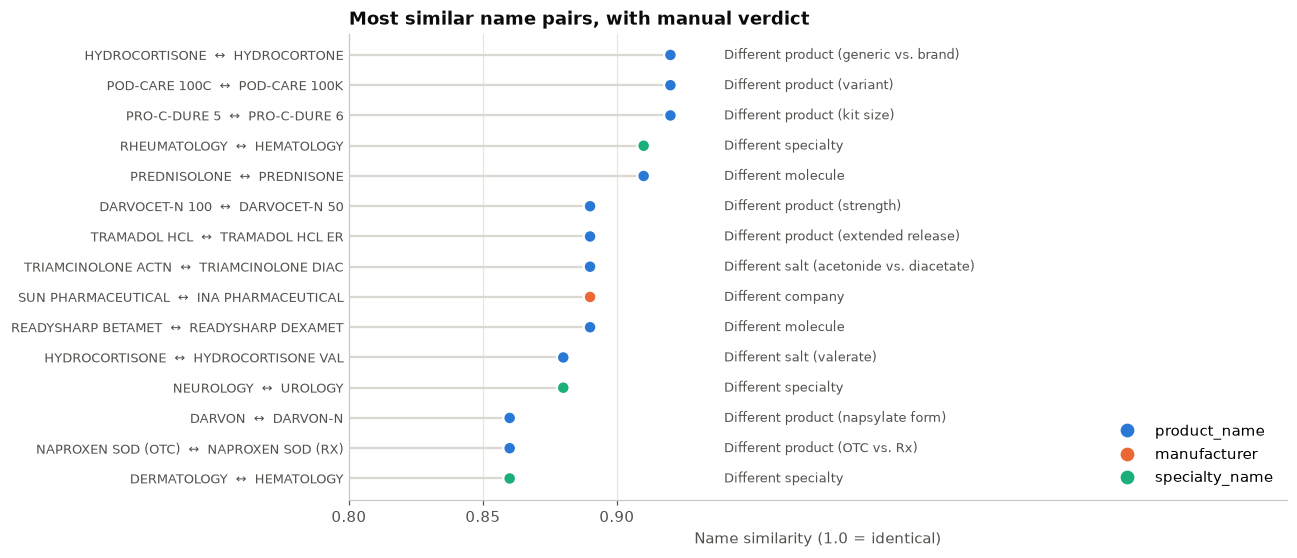

In [34]:
plot_sim = similar.iloc[::-1]
labels = plot_sim["name_a"] + "  ↔  " + plot_sim["name_b"]
col_colors = {"product_name": PALETTE[0], "manufacturer": PALETTE[1], "specialty_name": PALETTE[2]}

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.hlines(labels, 0.8, plot_sim["similarity"], color="#d9d8d3", lw=1.5)
ax.scatter(plot_sim["similarity"], labels, s=70, color=plot_sim["column"].map(col_colors),
           edgecolor="white", linewidth=1.5, zorder=3)
for y, v in enumerate(plot_sim["verdict"]):
    ax.text(0.94, y, v, va="center", fontsize=8.5, color=MUTED)
ax.set_xlim(0.8, 1.15)
ax.set_xticks([0.8, 0.85, 0.9])
ax.set_xlabel("Name similarity (1.0 = identical)")
ax.set_title("Most similar name pairs, with manual verdict")
ax.grid(visible=False)
for x in (0.85, 0.9):
    ax.axvline(x, color="#e6e5e0", lw=0.8, zorder=0)
ax.tick_params(axis="y", length=0, labelsize=8.5)
handles = [plt.Line2D([], [], marker="o", ls="", color=c, markersize=8) for c in col_colors.values()]
ax.legend(handles, col_colors.keys(), loc="lower right", frameon=False)
plt.show()

### 7.3 Data stored twice across tables

The gold tables repeat numbers that also exist in the fact tables:

- the monthly category visit counts;
- the place-of-service counts.

This duplication is by design, but the two copies must agree. If they don't, one copy is stale or was built wrongly. Each gold value is recomputed from the fact tables and compared.

In [35]:
recon = pd.read_sql(
    """WITH cat AS (
           SELECT f.month_id,
                  SUM(CASE WHEN p.treatment_category = 'branded_injectable'     THEN f.patient_visits END) AS b,
                  SUM(CASE WHEN p.treatment_category = 'generic_corticosteroid' THEN f.patient_visits END) AS gc,
                  SUM(CASE WHEN p.treatment_category = 'nsaid_otc'              THEN f.patient_visits END) AS n
           FROM fact_product_visits f JOIN dim_product p USING (product_id)
           GROUP BY f.month_id),
       pos AS (
           SELECT month_id,
                  SUM(CASE WHEN place_of_service = 'HOSPITAL'   THEN patient_visits ELSE 0 END) AS h,
                  SUM(CASE WHEN place_of_service = 'OFFICE'     THEN patient_visits ELSE 0 END) AS o,
                  SUM(CASE WHEN place_of_service = 'OTHER'      THEN patient_visits ELSE 0 END) AS ot,
                  SUM(CASE WHEN place_of_service = 'TELEHEALTH' THEN patient_visits ELSE 0 END) AS t
           FROM fact_place_of_service_visits GROUP BY month_id)
       SELECT g.month_id,
              g.branded_injectable_visits - cat.b      AS diff_branded,
              g.generic_corticosteroid_visits - cat.gc AS diff_generic,
              g.nsaid_otc_visits - cat.n               AS diff_nsaid,
              g.hospital_visits - pos.h                AS diff_hospital,
              g.office_visits - pos.o                  AS diff_office,
              g.other_visits - pos.ot                  AS diff_other,
              g.telehealth_visits - pos.t              AS diff_telehealth
       FROM gold_visit_share_monthly g JOIN cat USING (month_id) JOIN pos USING (month_id)""", conn)

diff_cols = [c for c in recon.columns if c.startswith("diff_")]
pd.DataFrame({"months_compared": len(recon),
              "months_mismatched": (recon[diff_cols] != 0).sum(),
              "max_abs_difference": recon[diff_cols].abs().max()})

,months_compared,months_mismatched,max_abs_difference
diff_branded,72,0,0
diff_generic,72,0,0
diff_nsaid,72,0,0
diff_hospital,72,0,0
diff_office,72,0,0
diff_other,72,0,0
diff_telehealth,72,0,0


**Read-out:**

- **No duplicate rows and no duplicate keys in any table.** Every primary key is unique (SQLite enforces this, and the check confirms it), so no visit is counted twice.
- **Two pairs of identical columns in `gold_visit_share_monthly`:**
  - **`months_since_launch` = `months_since_last_competitor_event`** in every row. There has been only one "competitor event", the launch itself, so the second column adds nothing.
  - **`is_post_launch` = `competitor_count_on_market`**, both constant 1.

  Only one column from each pair should be kept (and the constant pair is uninformative either way). Keeping both adds perfectly collinear features to a model. The four never-populated modelling columns also "match" each other (all NULL), so they were excluded from this check.
- **No near-duplicate names.** After normalising case and punctuation no values collide, and every pair with ≥ 0.85 similarity turned out to be two genuinely different entries: a different strength, salt, OTC vs. Rx form, or a different company or specialty.
  - Two related pairs sit just below the threshold and are also separate products: `NAPROXEN SOD`/`NAPROXEN SOD (OTC)` and `IBUPROFEN (OTC)`/`IBUPROFEN (RX)`.
  - Some manufacturers are divisions of one parent company (e.g. `AMNEAL PHARM`/`AMNEAL BIOSCIENCES`, `TEVA ONCOLOGY`/`TEVA PARENTERAL ME`). They are not duplicates, but could be grouped if a company-level view is needed.
- **The gold copies match the fact tables exactly.** All 72 months agree on all 7 counts (3 category counts, 4 settings), with zero difference. The gold layer is a faithful aggregate of the raw data.

## 8. Numerical and categorical features

Section 3 labelled every column by type. This section turns that into **feature lists** for modelling. A column is a feature only if it could be used as a model input, so the following are set aside:

- **Keys:** IDs used for joins.
- **Targets:** what the model predicts.
- **Excluded columns:** constant, duplicate, never-populated, or leaking the target.

The two gold tables serve two different questions, so each gets its own lists:

| Modelling table | Grain | Target |
|---|---|---|
| `gold_visit_share_monthly` | one row per month | `visit_share` (and its Up/Down/Flat `direction_label`) |
| `gold_segment_adoption` | month × specialty × demographic | `segment_visit_share` (and `adoption_label`) |

Categorical attributes stored in the dimension tables (month parts, specialty, age, gender) are joined in, since that is how they would reach a model.

### 8.1 Feature lists

In [36]:
FEATURE_ROLES = {
    "gold_visit_share_monthly": {
        "Target": ["visit_share", "direction_label"],
        "Numerical feature": ["visit_share_lag_1", "visit_share_lag_2", "visit_share_lag_3",
                              "visit_share_roll_3mo", "visit_share_roll_6mo", "months_since_launch",
                              "branded_injectable_visits", "generic_corticosteroid_visits",
                              "nsaid_otc_visits", "hospital_visits", "office_visits",
                              "other_visits", "telehealth_visits"],
        "Categorical feature": ["year", "quarter", "month_number"],
        "Excluded": {"month_id": "Key", "month_name": "Same as month_number",
                     "is_post_launch": "Constant (always 1)",
                     "competitor_count_on_market": "Constant (always 1)",
                     "months_since_last_competitor_event": "Duplicate of months_since_launch",
                     "predicted_direction": "Model output, empty",
                     "prediction_probability": "Model output, empty",
                     "model_version": "Model output, empty",
                     "actual_direction": "Model output, empty"},
    },
    "gold_segment_adoption": {
        "Target": ["segment_visit_share", "adoption_label"],
        "Numerical feature": ["total_category_visits"],
        "Categorical feature": ["specialty_name", "age_band", "gender", "year", "quarter", "month_number"],
        "Excluded": {"month_id": "Key", "specialty_id": "Key (replaced by specialty_name)",
                     "demographic_id": "Key (replaced by age_band, gender)",
                     "branded_injectable_visits": "Numerator of the target (leakage)"},
    },
}

feature_map = []
for table, roles in FEATURE_ROLES.items():
    for role, cols in roles.items():
        items = cols.items() if isinstance(cols, dict) else [(c, "") for c in cols]
        for col, note in items:
            feature_map.append({"table": table, "column": col, "role": role, "note": note})
feature_map = pd.DataFrame(feature_map)

with pd.option_context("display.max_rows", None):
    display(feature_map)

,table,column,role,note
0,gold_visit_share_monthly,visit_share,Target,
1,gold_visit_share_monthly,direction_label,Target,
2,gold_visit_share_monthly,visit_share_lag_1,Numerical feature,
3,gold_visit_share_monthly,visit_share_lag_2,Numerical feature,
4,gold_visit_share_monthly,visit_share_lag_3,Numerical feature,
5,gold_visit_share_monthly,visit_share_roll_3mo,Numerical feature,
6,gold_visit_share_monthly,visit_share_roll_6mo,Numerical feature,
7,gold_visit_share_monthly,months_since_launch,Numerical feature,
8,gold_visit_share_monthly,branded_injectable_visits,Numerical feature,
9,gold_visit_share_monthly,generic_corticosteroid_visits,Numerical feature,


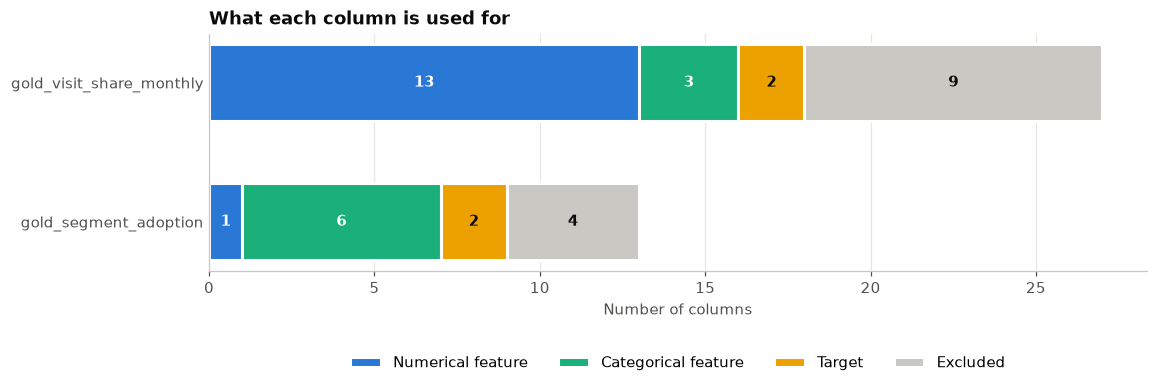

In [37]:
ROLE_ORDER = ["Numerical feature", "Categorical feature", "Target", "Excluded"]
role_colors = dict(zip(ROLE_ORDER, [PALETTE[0], PALETTE[2], PALETTE[3], "#c9c8c3"]))
role_counts = feature_map.pivot_table(index="table", columns="role", values="column",
                                      aggfunc="count", fill_value=0).reindex(columns=ROLE_ORDER)

fig, ax = plt.subplots(figsize=(11, 2.8))
left = np.zeros(len(role_counts))
for role in ROLE_ORDER:
    vals = role_counts[role].values
    ax.barh(role_counts.index, vals, left=left, color=role_colors[role], height=0.55,
            edgecolor="white", linewidth=2, label=role)
    for y, (l, v) in enumerate(zip(left, vals)):
        if v:
            ax.text(l + v / 2, y, str(v), ha="center", va="center", fontsize=10,
                    color=INK if role in ("Target", "Excluded") else "white", fontweight="bold")
    left += vals
ax.set_xlabel("Number of columns")
ax.set_title("What each column is used for")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=4, frameon=False)
plt.show()

### 8.2 Numerical features

The chart shows each numerical feature's full range (min to max) with its median as a dot, on a **log scale**. The point is to see how far apart the scales are. Distance- and gradient-based models (linear/logistic regression, k-NN, SVM, neural nets) need features on a common scale; tree-based models do not.

table,feature,min,median,max,max / min ratio
gold_visit_share_monthly,visit_share_lag_1,0.01741,0.02548,0.03376,1.9
gold_visit_share_monthly,visit_share_lag_2,0.01741,0.02552,0.03376,1.9
gold_visit_share_monthly,visit_share_lag_3,0.0175,0.02556,0.03376,1.9
gold_visit_share_monthly,visit_share_roll_3mo,0.01763,0.02664,0.03212,1.8
gold_visit_share_monthly,visit_share_roll_6mo,0.0184,0.02659,0.03143,1.7
gold_visit_share_monthly,months_since_launch,22,57.5,93,4.2
gold_visit_share_monthly,branded_injectable_visits,937,"1,876","2,849",3.0
gold_visit_share_monthly,generic_corticosteroid_visits,2.88e+04,6.834e+04,8.919e+04,3.1
gold_visit_share_monthly,nsaid_otc_visits,"1,033","5,609","7,180",7.0
gold_visit_share_monthly,hospital_visits,235,"3,042","3,743",15.9


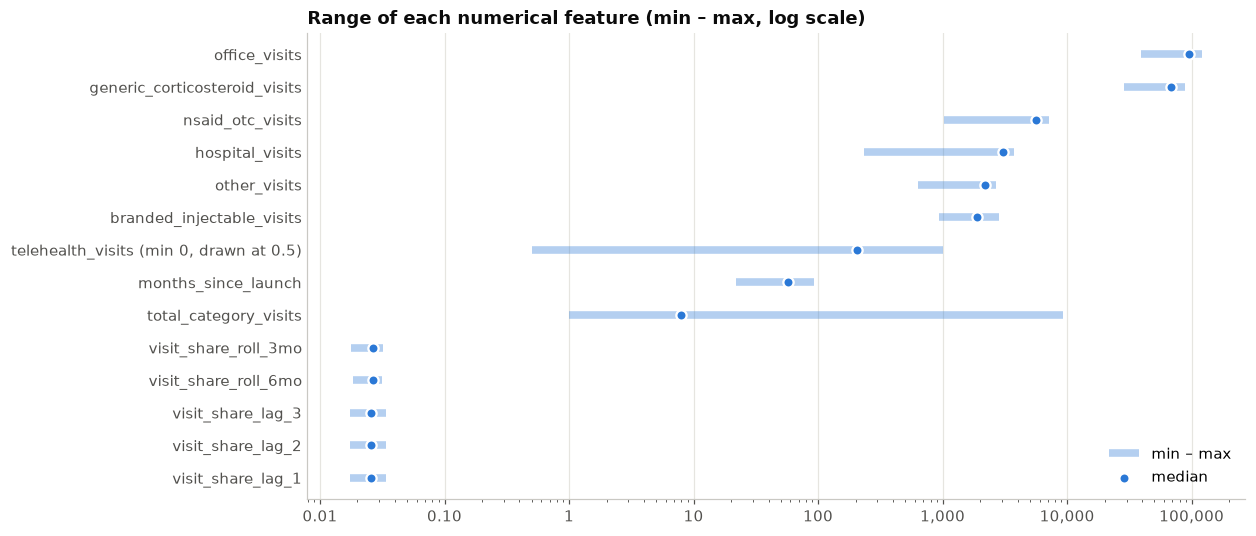

In [38]:
seg_joined = pd.read_sql(
    """SELECT g.*, s.specialty_name, d.age_band, d.gender, m.year, m.quarter, m.month_number
       FROM gold_segment_adoption g
       JOIN dim_specialty s USING (specialty_id)
       JOIN dim_demographics d USING (demographic_id)
       JOIN dim_month m USING (month_id)""", conn)
monthly_joined = gold.merge(pd.read_sql("SELECT month_id, year, quarter, month_number FROM dim_month", conn),
                            on="month_id")
source = {"gold_visit_share_monthly": monthly_joined, "gold_segment_adoption": seg_joined}

num_feats = feature_map[feature_map["role"] == "Numerical feature"]
num_profile = pd.DataFrame([
    {"table": r.table, "feature": r.column, **source[r.table][r.column].agg(["min", "median", "max"]).to_dict()}
    for r in num_feats.itertuples()
])
num_profile["max / min ratio"] = num_profile["max"] / num_profile["min"].replace(0, np.nan)
display(num_profile.style.format({"min": "{:,.4g}", "median": "{:,.4g}", "max": "{:,.4g}",
                                  "max / min ratio": "{:,.1f}"}).hide(axis="index"))

plot_np = num_profile.sort_values("median")
lo = plot_np["min"].where(plot_np["min"] > 0, 0.5)   # telehealth has 0s; clip for the log axis
fig, ax = plt.subplots(figsize=(11, 5.5))
labels = plot_np["feature"].where(plot_np["min"] > 0, plot_np["feature"] + " (min 0, drawn at 0.5)")
ax.hlines(labels, lo, plot_np["max"], color=PALETTE[0], lw=5, alpha=0.35, label="min – max")
ax.scatter(plot_np["median"], labels, s=45, color=PALETTE[0], edgecolor="white",
           linewidth=1.5, zorder=3, label="median")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.2f}" if v < 1 else f"{v:,.0f}"))
ax.set_title("Range of each numerical feature (min – max, log scale)")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="lower right", frameon=False)
plt.show()

### 8.3 Categorical features

For each categorical feature, the table shows:

- **levels:** the number of distinct values;
- **rare levels:** values that appear in fewer than 1% of rows, which a model can barely learn from;
- **encoding:** a suggested way to turn the feature into numbers.

Ordinal features keep their order (ordinal encoding). Nominal features with few levels are one-hot encoded; with many levels, rare ones are grouped into "Other" first.

In [39]:
CAT_TYPE = {"year": "ordinal", "quarter": "ordinal", "month_number": "ordinal (cyclical)",
            "age_band": "ordinal", "gender": "nominal", "specialty_name": "nominal"}
cat_feats = feature_map[feature_map["role"] == "Categorical feature"]

cat_profile = []
for r in cat_feats.itertuples():
    freq = source[r.table][r.column].value_counts(normalize=True)
    n_rare = int((freq < 0.01).sum())
    kind = CAT_TYPE[r.column]
    if kind.startswith("ordinal (cyclical)"):
        enc = "sin/cos (month 12 is next to month 1)"
    elif kind == "ordinal":
        enc = "Ordinal integer in natural order"
    elif freq.size <= 10:
        enc = "One-hot"
    else:
        enc = "Group rare levels into 'Other', then one-hot"
    cat_profile.append({"table": r.table, "feature": r.column, "type": kind, "levels": freq.size,
                        "rare_levels (<1%)": n_rare, "most_common": freq.index[0],
                        "most_common_%": freq.iloc[0] * 100, "encoding": enc})
cat_profile = pd.DataFrame(cat_profile)
display(cat_profile.style.format({"most_common_%": "{:.1f}"}).hide(axis="index"))

table,feature,type,levels,rare_levels (<1%),most_common,most_common_%,encoding
gold_visit_share_monthly,year,ordinal,7,0,2020,16.7,Ordinal integer in natural order
gold_visit_share_monthly,quarter,ordinal,4,0,3,25.0,Ordinal integer in natural order
gold_visit_share_monthly,month_number,ordinal (cyclical),12,0,8,8.3,sin/cos (month 12 is next to month 1)
gold_segment_adoption,specialty_name,nominal,50,22,ORTHOPEDIC SURGERY,6.0,"Group rare levels into 'Other', then one-hot"
gold_segment_adoption,age_band,ordinal,10,2,65 TO 74,18.4,Ordinal integer in natural order
gold_segment_adoption,gender,nominal,3,0,FEMALE,52.0,One-hot
gold_segment_adoption,year,ordinal,7,0,2021,17.3,Ordinal integer in natural order
gold_segment_adoption,quarter,ordinal,4,0,2,25.1,Ordinal integer in natural order
gold_segment_adoption,month_number,ordinal (cyclical),12,0,6,8.5,sin/cos (month 12 is next to month 1)


The chart shows the levels per categorical feature, split into common and rare levels. The label on the left names the table the feature comes from.

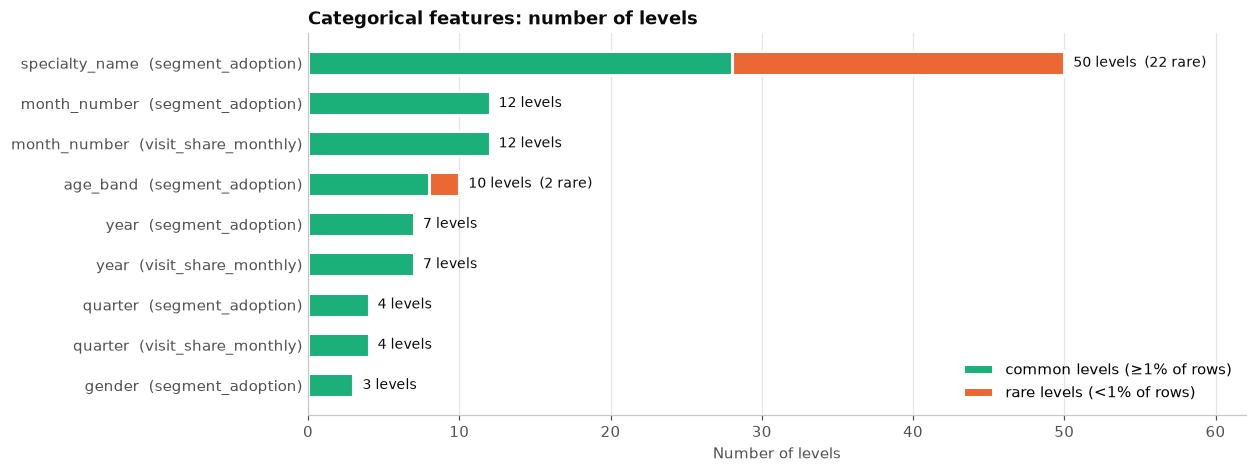

In [40]:
plot_cp = cat_profile.copy()
plot_cp["label"] = plot_cp["feature"] + "  (" + plot_cp["table"].str.replace("gold_", "") + ")"
plot_cp["common"] = plot_cp["levels"] - plot_cp["rare_levels (<1%)"]
plot_cp = plot_cp.sort_values("levels")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.barh(plot_cp["label"], plot_cp["common"], color=PALETTE[2], height=0.6, label="common levels (≥1% of rows)",
        edgecolor="white", linewidth=2)
ax.barh(plot_cp["label"], plot_cp["rare_levels (<1%)"], left=plot_cp["common"], color=PALETTE[1], height=0.6,
        label="rare levels (<1% of rows)", edgecolor="white", linewidth=2)
for y, (c, r_, t) in enumerate(zip(plot_cp["common"], plot_cp["rare_levels (<1%)"], plot_cp["levels"])):
    ax.text(t + 0.6, y, f"{t} levels" + (f"  ({r_} rare)" if r_ else ""), va="center", fontsize=9, color=INK)
ax.set_xlim(0, 62)
ax.set_xlabel("Number of levels")
ax.set_title("Categorical features: number of levels")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="lower right", frameon=False)
plt.show()

**Read-out:**

- **Monthly model (`gold_visit_share_monthly`): 13 numerical and 3 categorical features.** Nine columns are excluded:
  - 1 key;
  - 2 constants;
  - 1 duplicate (`months_since_last_competitor_event`);
  - 1 redundant label (`month_name` = `month_number`);
  - 4 empty model-output columns;
- **Watch for leakage in the monthly features.**
  - The three same-month category counts (`branded_injectable_visits`, `generic_corticosteroid_visits`, `nsaid_otc_visits`) are exactly the numerator and denominator of `visit_share`. Using them to predict the same month's share or direction leaks the answer. For forecasting, only their lagged values are valid.
  - The `visit_share_lag_*` and `visit_share_roll_*` features are built from earlier months only. The rolling windows originally included the current month (section 9 found this); `build_gold.py` now ends them at the previous month.
- **Segment model (`gold_segment_adoption`): 1 numerical and 6 categorical features.** `branded_injectable_visits` is excluded because it is the numerator of `segment_visit_share`. This model is driven almost entirely by *who* the segment is (specialty, age, gender) and *when*.
- **Numerical scales differ by up to about 7 orders of magnitude.** Shares sit around 0.02 and office visits reach 122K. Scale them (standardise, or `log1p` for counts, per section 4.2) for any linear, distance-based or neural model.
  - `total_category_visits` alone spans 1 to 9,258.
  - `telehealth_visits` includes zeros, so it needs `log1p` rather than `log`.
- **Categorical features are low-cardinality except `specialty_name`.**
  - `specialty_name` has **50 levels, 22 of them rare** (<1% of segment rows). One-hot encoding it would add 50 sparse columns, so group the rare specialties into "Other" first.
  - `age_band` has 10 levels (2 rare, e.g. the children's bands) and should be ordinal-encoded in its natural order.
  - `gender` has 3 levels and suits one-hot.
- **`month_number` is cyclical.** Encode it with sin/cos so December and January end up next to each other, which matters given the December spike in share. `year` and `quarter` are ordinal. Note that `year` has partial years at both ends (2019 has 5 months, 2025 has 7), so year-level averages for those two are not comparable to full years.

## 9. Correlation

Correlation measures how strongly two variables move together, from **−1** (one rises as the other falls) through **0** (no relationship) to **+1** (they rise together). Two versions are used:

- **Pearson:** measures a straight-line relationship; sensitive to outliers.
- **Spearman:** measures a rank-order relationship; robust to outliers and to curved but consistent relationships.

This section answers three questions:

1. Which features move with the target?
2. Which features are so strongly correlated with each other that they are redundant?
3. For the segment table, how strongly does each categorical feature relate to adoption?

### 9.1 Correlation matrix: monthly table

This covers every numerical candidate in `gold_visit_share_monthly` plus the target. The two rolling averages are included because this matrix is where their original current-month leak was spotted (section 9.2).

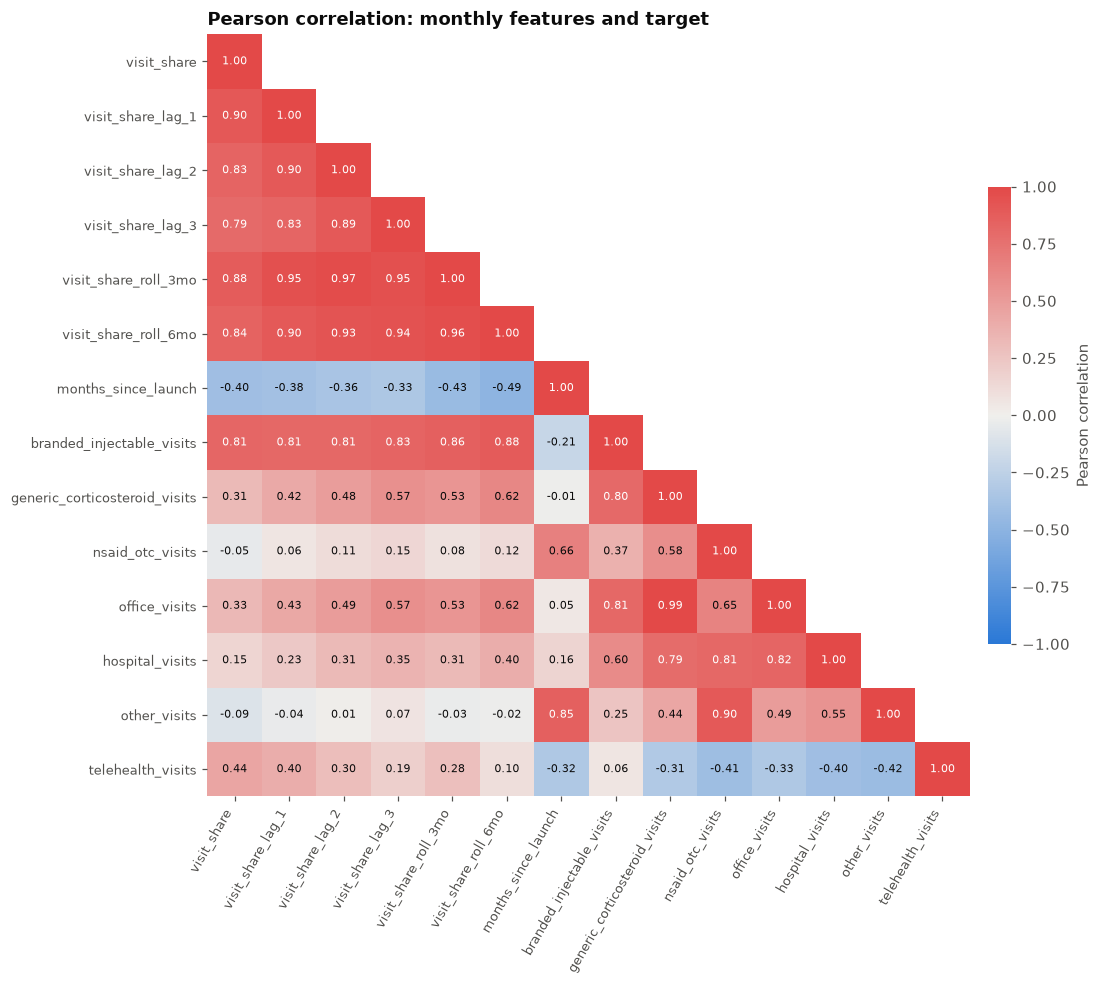

In [41]:
CORR_COLS = ["visit_share", "visit_share_lag_1", "visit_share_lag_2", "visit_share_lag_3",
             "visit_share_roll_3mo", "visit_share_roll_6mo", "months_since_launch",
             "branded_injectable_visits", "generic_corticosteroid_visits", "nsaid_otc_visits",
             "office_visits", "hospital_visits", "other_visits", "telehealth_visits"]
corr = monthly_joined[CORR_COLS].corr(method="pearson")

DIVERGING = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "blue_gray_red", [PALETTE[0], "#f0efec", PALETTE[7]])

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show the lower triangle only
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(np.ma.masked_array(corr.values, mask), cmap=DIVERGING, vmin=-1, vmax=1)
for (y, x), v in np.ndenumerate(corr.values):
    if not mask[y, x]:
        ax.text(x, y, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(v) > 0.75 else INK)
ax.set_xticks(range(len(CORR_COLS)), CORR_COLS, rotation=60, ha="right", fontsize=8.5)
ax.set_yticks(range(len(CORR_COLS)), CORR_COLS, fontsize=8.5)
ax.grid(visible=False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cb.set_label("Pearson correlation")
cb.outline.set_visible(False)
ax.set_title("Pearson correlation: monthly features and target")
plt.show()

### 9.2 Correlation with the target

Correlating two monthly **levels** can mislead. Any two series that both trend over time will look correlated even if they are unrelated. A stricter test correlates **month-over-month changes**: when the feature moves up or down this month, does the share move with it?

A feature that correlates in levels but not in changes is mostly sharing the long-run trend. Month parts (`year`, `quarter`, `month_number`) are ordinal, so they are included via Spearman.

In [42]:
TARGET_FEATS = [c for c in CORR_COLS if c != "visit_share"] + ["year", "quarter", "month_number"]
changes = monthly_joined[TARGET_FEATS + ["visit_share"]].diff()

target_corr = pd.DataFrame({
    "pearson_level": monthly_joined[TARGET_FEATS].corrwith(monthly_joined["visit_share"]),
    "spearman_level": monthly_joined[TARGET_FEATS].corrwith(monthly_joined["visit_share"], method="spearman"),
    "pearson_change": changes[TARGET_FEATS].corrwith(changes["visit_share"]),
})
target_corr["p_value_level"] = [stats.pearsonr(*monthly_joined[[f, "visit_share"]].dropna().T.values)[1]
                                for f in TARGET_FEATS]
target_corr = target_corr.sort_values("spearman_level", key=abs, ascending=False)
target_corr.style.format("{:.2f}", subset=["pearson_level", "spearman_level", "pearson_change"]) \
    .format("{:.3g}", subset=["p_value_level"]) \
    .background_gradient(cmap=DIVERGING, vmin=-1, vmax=1, subset=["pearson_level", "spearman_level", "pearson_change"])

C:\Users\Tus20\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Tus20\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,pearson_level,spearman_level,pearson_change,p_value_level
visit_share_lag_1,0.90,0.88,-0.19,1.47e-26
visit_share_roll_3mo,0.88,0.84,-0.23,4.78e-23
branded_injectable_visits,0.81,0.82,0.27,3.3e-18
visit_share_lag_2,0.83,0.80,-0.13,4.68e-19
visit_share_roll_6mo,0.84,0.79,-0.13,2.24e-18
visit_share_lag_3,0.79,0.78,0.00,6.82e-16
telehealth_visits,0.44,0.66,0.46,9.48e-05
office_visits,0.33,0.44,-0.23,0.00527
generic_corticosteroid_visits,0.31,0.41,-0.23,0.00742
year,-0.40,-0.40,-0.44,0.000529


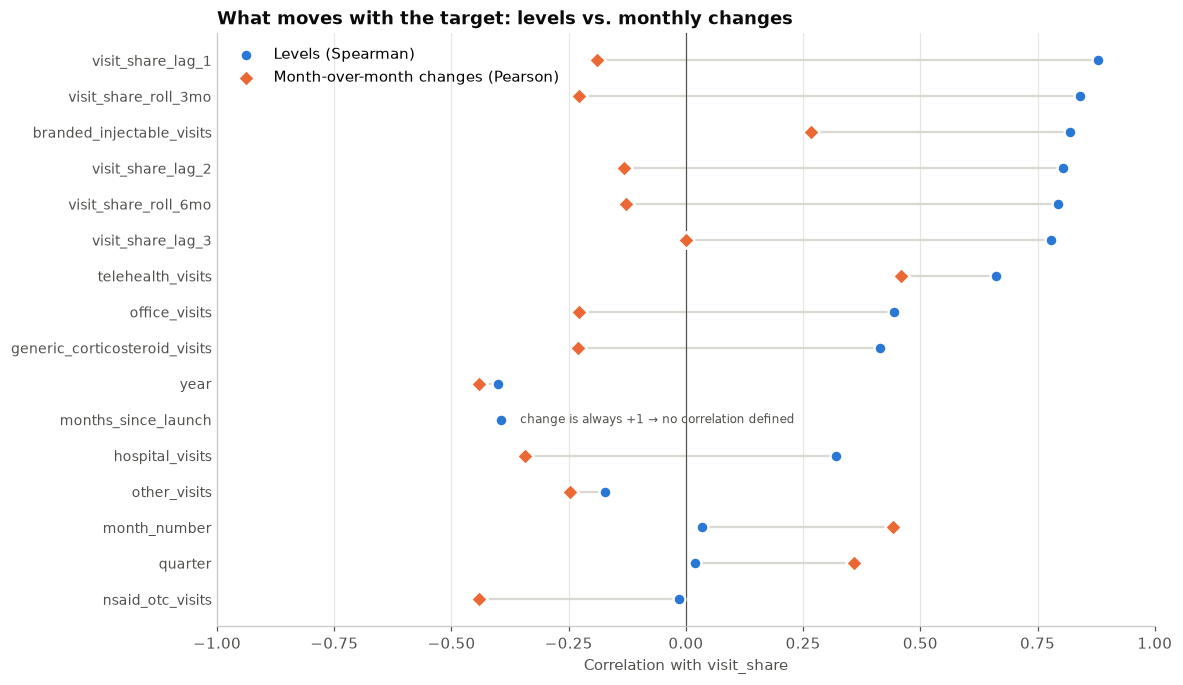

In [43]:
plot_tc = target_corr.iloc[::-1]
y = np.arange(len(plot_tc))

fig, ax = plt.subplots(figsize=(11, 7))
ax.hlines(y, plot_tc[["spearman_level", "pearson_change"]].min(axis=1),
          plot_tc[["spearman_level", "pearson_change"]].max(axis=1), color="#d9d8d3", lw=1.5)
ax.scatter(plot_tc["spearman_level"], y, s=60, color=PALETTE[0], edgecolor="white", linewidth=1.5,
           zorder=3, label="Levels (Spearman)")
ax.scatter(plot_tc["pearson_change"], y, s=60, color=PALETTE[1], edgecolor="white", linewidth=1.5,
           zorder=3, marker="D", label="Month-over-month changes (Pearson)")
ax.axvline(0, color=MUTED, lw=0.8)
ax.set_yticks(y, plot_tc.index, fontsize=9)
ax.set_xlim(-1, 1)
ax.set_xlabel("Correlation with visit_share")
ax.set_title("What moves with the target: levels vs. monthly changes")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="upper left", frameon=False)
# months_since_launch rises by exactly 1 every month, so its change has no variance
yi = list(plot_tc.index).index("months_since_launch")
ax.text(plot_tc.loc["months_since_launch", "spearman_level"] + 0.04, yi,
        "change is always +1 → no correlation defined", va="center", fontsize=8, color=MUTED)
plt.show()

**Checking the rolling averages.** In the original Gold table, `visit_share_roll_3mo` correlated with the target more strongly than `visit_share_lag_1` did (0.95 vs 0.90), which is suspicious for a feature meant to describe the past. This check recomputes both rolling averages two ways, including and excluding the current month, and compares them with the stored columns. It originally matched the *including* version exactly, a leak that has since been fixed in `build_gold.py` (the windows now end at the previous month). Run against the rebuilt warehouse, the check matches the *prior-months-only* mean exactly.

In [44]:
share = monthly_joined["visit_share"]
leak_check = pd.DataFrame({
    "window": ["3 months", "6 months"],
    "max diff vs. mean INCLUDING current month": [
        (share.rolling(3).mean() - monthly_joined["visit_share_roll_3mo"]).abs().max(),
        (share.rolling(6).mean() - monthly_joined["visit_share_roll_6mo"]).abs().max()],
    "max diff vs. mean of PRIOR months only": [
        (share.shift(1).rolling(3).mean() - monthly_joined["visit_share_roll_3mo"]).abs().max(),
        (share.shift(1).rolling(6).mean() - monthly_joined["visit_share_roll_6mo"]).abs().max()],
})
leak_check.style.format("{:.6f}", subset=leak_check.columns[1:]).hide(axis="index")

window,max diff vs. mean INCLUDING current month,max diff vs. mean of PRIOR months only
3 months,0.003359,0.000000
6 months,0.001680,0.000000


### 9.3 Redundant feature pairs

These are pairs of features with |Pearson r| ≥ 0.9. Two features this strongly correlated carry almost the same information. In a linear model they make coefficients unstable (**multicollinearity**), so usually only one should be kept.

In [45]:
feat_corr = monthly_joined[TARGET_FEATS].corr().abs()
redundant = pd.DataFrame([
    {"feature_a": a, "feature_b": b, "abs_pearson": feat_corr.loc[a, b]}
    for i, a in enumerate(TARGET_FEATS) for b in TARGET_FEATS[i + 1:] if feat_corr.loc[a, b] >= 0.9
]).sort_values("abs_pearson", ascending=False)
redundant.style.format({"abs_pearson": "{:.3f}"}).hide(axis="index")

feature_a,feature_b,abs_pearson
generic_corticosteroid_visits,office_visits,0.995
months_since_launch,year,0.987
quarter,month_number,0.972
visit_share_lag_2,visit_share_roll_3mo,0.971
visit_share_roll_3mo,visit_share_roll_6mo,0.964
visit_share_lag_1,visit_share_roll_3mo,0.948
visit_share_lag_3,visit_share_roll_3mo,0.948
visit_share_lag_3,visit_share_roll_6mo,0.938
visit_share_lag_2,visit_share_roll_6mo,0.927


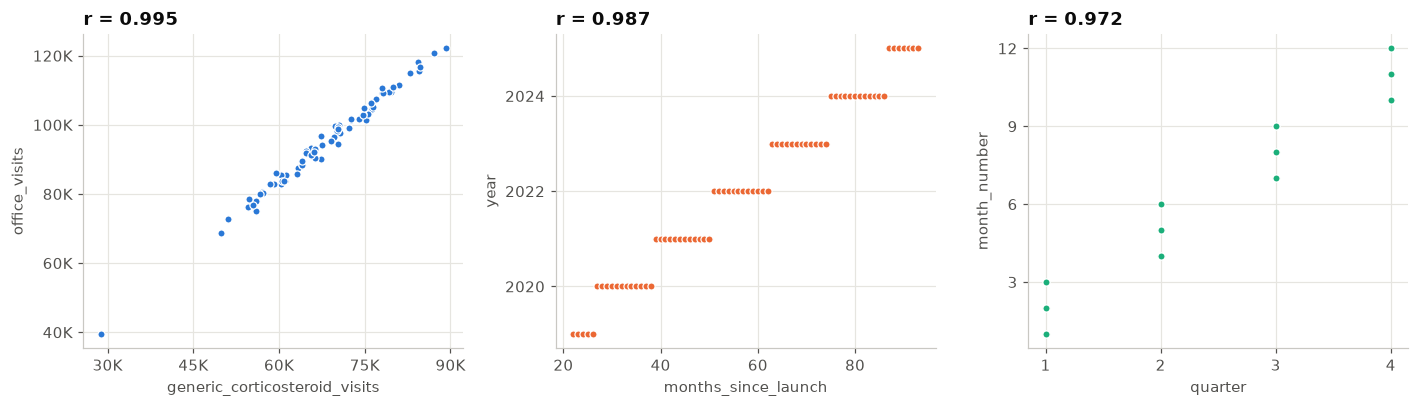

In [46]:
# Scatter of the three non-obvious redundant pairs (the lag/rolling pairs are expected)
pairs = [("generic_corticosteroid_visits", "office_visits"),
         ("months_since_launch", "year"),
         ("quarter", "month_number")]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (a, b), color in zip(axes, pairs, PALETTE):
    ax.scatter(monthly_joined[a], monthly_joined[b], s=22, color=color, edgecolor="white", linewidth=0.8)
    ax.set_xlabel(a)
    ax.set_ylabel(b)
    ax.set_title(f"r = {monthly_joined[a].corr(monthly_joined[b]):.3f}")
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(mtick.MaxNLocator(5, integer=True))
        axis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:,.0f}K" if abs(v) >= 10_000 else f"{v:.0f}"))
fig.tight_layout()
plt.show()

### 9.4 Segment table: categorical features vs. adoption

Pearson correlation needs numbers on both sides, so for a categorical feature against the numeric target `segment_visit_share` the **correlation ratio (η, eta)** is used instead. It ranges from 0 (the category tells you nothing about the share) to 1 (the category fully determines it).

Section 2 showed that most segments are tiny: a segment with 2 visits can only have a share of 0%, 50% or 100%. η is therefore computed twice, once on all segments and once on segments with **≥ 20 category visits**, where the share is less noisy. The only numerical feature, `total_category_visits`, is included using Pearson on `log1p` (section 4.2).

,All segments,Segments with ≥20 visits
specialty_name,0.248,0.675
age_band,0.092,0.276
gender,0.009,0.036
year,0.024,0.076
quarter,0.023,0.019
month_number,0.029,0.033
"total_category_visits (log1p, |Pearson|)",0.060,0.022
rows used,"21,636","8,686"


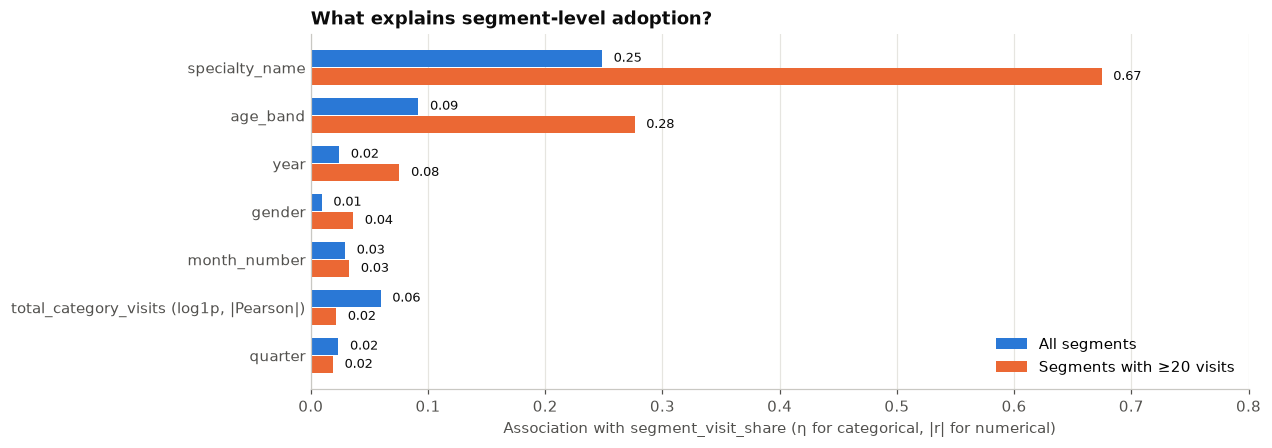

In [47]:
def correlation_ratio(categories, values):
    overall = values.mean()
    groups = values.groupby(categories)
    between = (groups.count() * (groups.mean() - overall) ** 2).sum()
    total = ((values - overall) ** 2).sum()
    return np.sqrt(between / total)

MIN_VISITS = 20
subsets = {"All segments": seg_joined,
           f"Segments with ≥{MIN_VISITS} visits": seg_joined[seg_joined["total_category_visits"] >= MIN_VISITS]}

seg_assoc = pd.DataFrame({
    name: {**{f: correlation_ratio(df[f], df["segment_visit_share"])
              for f in ["specialty_name", "age_band", "gender", "year", "quarter", "month_number"]},
           "total_category_visits (log1p, |Pearson|)": abs(np.log1p(df["total_category_visits"])
                                                         .corr(df["segment_visit_share"]))}
    for name, df in subsets.items()
})
seg_assoc.loc["rows used"] = [len(df) for df in subsets.values()]
display(seg_assoc.style.format("{:.3f}").format("{:,.0f}", subset=pd.IndexSlice[["rows used"], :]))

plot_sa = seg_assoc.drop("rows used").sort_values(f"Segments with ≥{MIN_VISITS} visits")
y = np.arange(len(plot_sa))
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.barh(y + 0.19, plot_sa["All segments"], height=0.36, color=PALETTE[0], label="All segments")
ax.barh(y - 0.19, plot_sa[f"Segments with ≥{MIN_VISITS} visits"], height=0.36, color=PALETTE[1],
        label=f"Segments with ≥{MIN_VISITS} visits")
for yy, (v1, v2) in enumerate(zip(plot_sa["All segments"], plot_sa[f"Segments with ≥{MIN_VISITS} visits"])):
    ax.text(v1 + 0.01, yy + 0.19, f"{v1:.2f}", va="center", fontsize=8.5, color=INK)
    ax.text(v2 + 0.01, yy - 0.19, f"{v2:.2f}", va="center", fontsize=8.5, color=INK)
ax.set_yticks(y, plot_sa.index)
ax.set_xlim(0, 0.8)
ax.set_xlabel("Association with segment_visit_share (η for categorical, |r| for numerical)")
ax.set_title("What explains segment-level adoption?")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="lower right", frameon=False)
plt.show()

**Read-out:**

- **Leakage found, and fixed.** The original `visit_share_roll_3mo` and `_roll_6mo` matched a rolling mean that *includes* the month being predicted exactly (difference 0.000000), which is why `roll_3mo` correlated 0.95 with the target, more than `lag_1` did: they contained the answer. `build_gold.py` now computes them as `visit_share.shift(1).rolling(n).mean()`, and the check above confirms the rebuilt columns match the prior-months mean exactly (difference 0.000000). Their correlation with the target is now 0.88 (`roll_3mo`) and 0.84 (`roll_6mo`), below `lag_1`'s 0.90, as expected of a legitimate past-only feature.
- **Past share is the strongest legitimate signal.** Lags 1–3 correlate 0.90 / 0.83 / 0.79 with the target in levels, because share changes slowly. In month-over-month changes, however, `lag_1` is slightly **negative** (−0.19): after a rise, the next month tends to fall back a little (mean reversion). That matters for an Up/Down/Flat model.
- **Many level correlations are just the shared trend.**
  - `year` (−0.40) and `months_since_launch` (−0.40) only capture that share has declined since 2022.
  - `telehealth_visits` looks related in levels (Spearman 0.66) because telehealth and share were both higher in 2020–22.

  Neither is a direct driver.
- **Zilretta's own volume drives share (r = 0.81), generic volume much less (0.31).** In monthly changes, however, NSAID/OTC (−0.44) and generic (−0.23) visits push share down when they grow, as expected for denominator terms.
- **Seasonality shows up only in changes.** `month_number` and `quarter` are about 0 in levels but +0.44 / +0.36 in changes, reflecting the December rise and January drop from the seasonal pattern.
- **Redundant pairs to resolve before modelling:**
  - `generic_corticosteroid_visits` ≈ `office_visits` (r = 0.995), since most generic injections happen in the office.
  - `months_since_launch` ≈ `year` (0.987), both simple clocks.
  - `quarter` ≈ `month_number` (0.972).
  - The lag features with the rolling averages (0.90–0.97, since a rolling mean of prior months is built from the same lags). The lags themselves stay just under 0.9 with each other (0.83–0.90).

  Keep one of each pair for linear models; tree models are less affected.
- **In the segment table, specialty is by far the strongest factor.** On segments with ≥20 visits, η = **0.67** for specialty, 0.28 for age band, and 0.08 or less for gender, time parts and segment size. *Who* prescribes matters far more than *when* or patient gender. On all segments these values shrink (0.25 for specialty) because tiny segments add noise, which is another reason to filter or weight by volume.

## 10. Outliers

An outlier is a value far from the rest. It can be a data error (fix or drop), a real but rare event (keep and flag), or simply the natural tail of a skewed variable (transform, don't drop). Three detection methods are used, because each has blind spots:

| Method | Rule | Good for | Blind spot |
|---|---|---|---|
| **IQR** | below Q1 − 1.5×IQR or above Q3 + 1.5×IQR | Any distribution, robust | Flags the natural tail of skewed data |
| **z-score** | more than 3 standard deviations from the mean | Roughly normal data | The outlier itself inflates the std, which hides it |
| **STL residual** | the part of a monthly value left after removing trend and 12-month seasonality is more than 3 std from typical | Time series | Needs enough history |

For monthly data, STL is the most meaningful. A month is only surprising relative to where the trend and the season say it should be. For example, a low value in a year when share was low overall is not an outlier.

### 10.1 Monthly measures

In [48]:
def iqr_flags(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    return (s < q1 - k * (q3 - q1)) | (s > q3 + k * (q3 - q1))

def z_flags(s, k=3):
    return ((s - s.mean()) / s.std()).abs() > k

def stl_flags(s, k=3):
    resid = STL(s, period=12, robust=True).fit().resid
    return ((resid - resid.mean()) / resid.std()).abs() > k

ts = monthly_joined.set_index("calendar_date")
fmt_months = lambda mask: ", ".join(mask[mask].index.strftime("%b %Y")) or "–"

monthly_outliers = pd.DataFrame([
    {"measure": c, "IQR": fmt_months(iqr_flags(ts[c])), "z-score": fmt_months(z_flags(ts[c])),
     "STL residual": fmt_months(stl_flags(ts[c]))}
    for c in MONTHLY_MEASURES
])
monthly_outliers.style.hide(axis="index").set_properties(**{"text-align": "left"})

measure,IQR,z-score,STL residual
visit_share,–,–,Apr 2020
branded_injectable_visits,–,–,Jun 2024
generic_corticosteroid_visits,Apr 2020,Apr 2020,"Mar 2020, Apr 2020"
nsaid_otc_visits,"Mar 2020, Apr 2020",Apr 2020,Apr 2020
office_visits,Apr 2020,Apr 2020,"Mar 2020, Apr 2020"
hospital_visits,"Mar 2020, Apr 2020, May 2020",Apr 2020,Apr 2020
other_visits,–,–,Apr 2020
telehealth_visits,"Aug 2019, Sep 2019, Oct 2019, Nov 2019, Dec 2019, Jan 2020, Feb 2020, Apr 2020, May 2020, Jun 2020, Jul 2020, Aug 2020, Sep 2020, Dec 2020, Jan 2021, Feb 2021, Mar 2021","Apr 2020, May 2020","Apr 2020, May 2020"


Each panel shows a monthly measure over time. **Filled orange dots** are months flagged by STL (unusual given trend and season). **Hollow rings** are months flagged only by IQR (extreme in absolute terms). The shaded band marks the Mar–Jul 2024 dip discussed in the read-out.

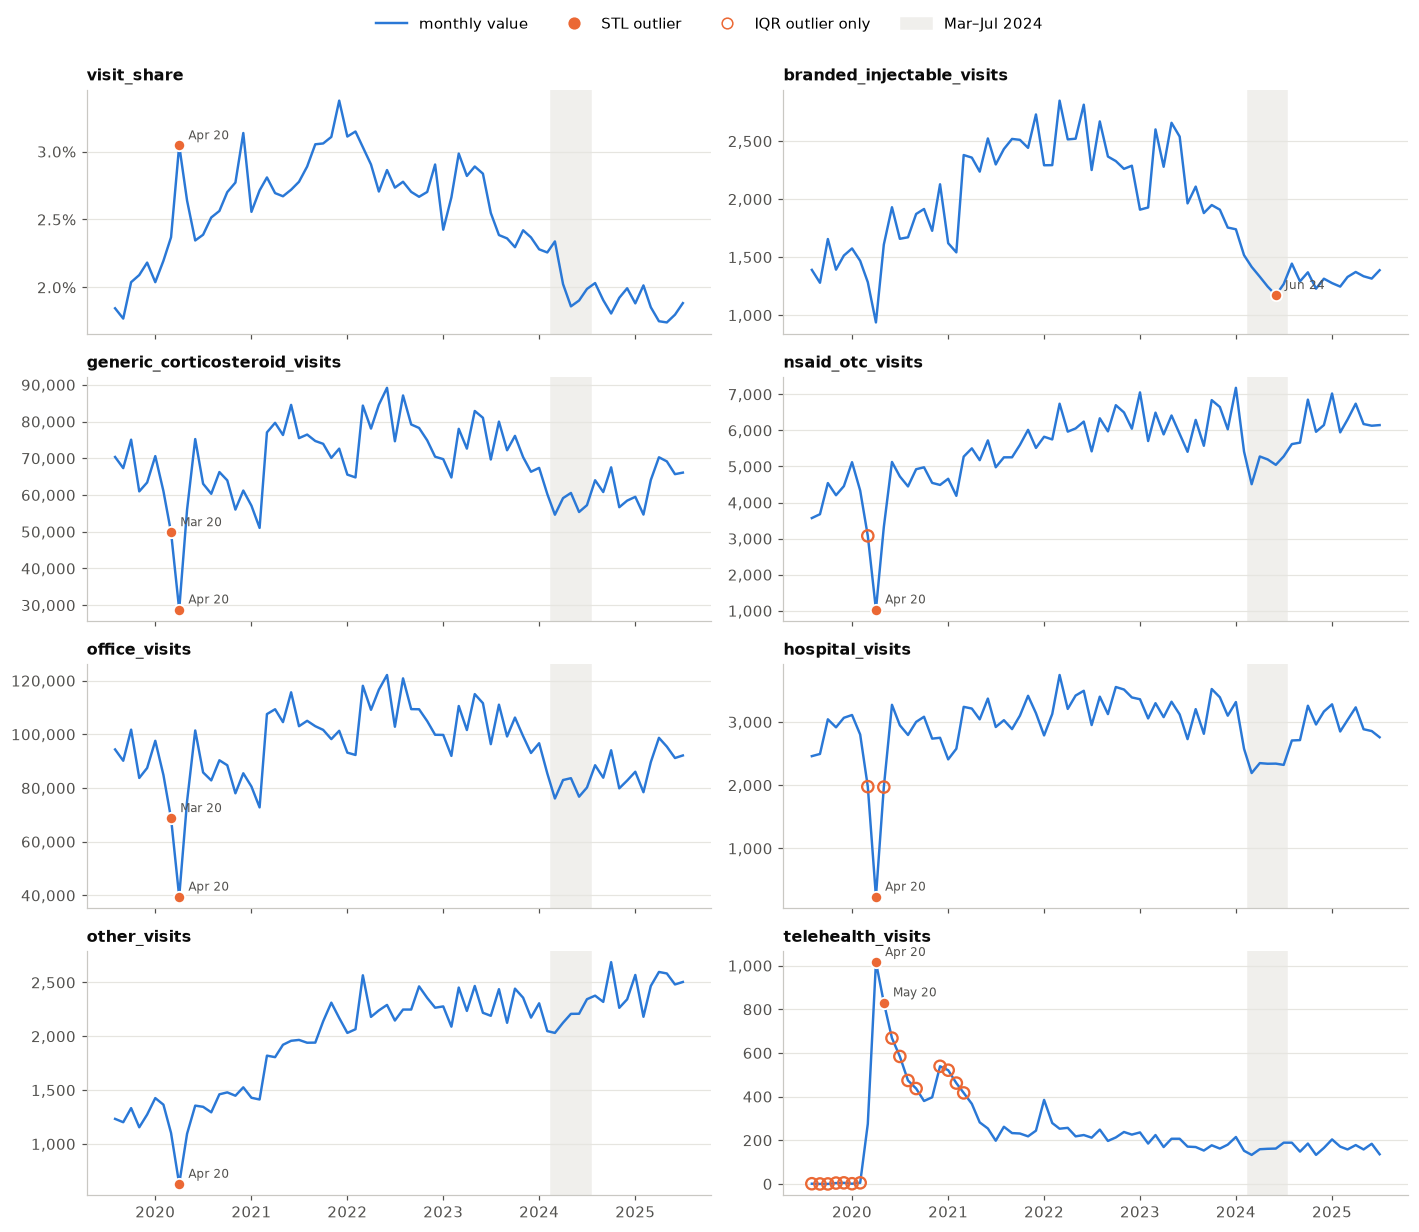

In [49]:
fig, axes = plt.subplots(4, 2, figsize=(13, 11), sharex=True)
for ax, col in zip(axes.flat, MONTHLY_MEASURES):
    s = ts[col]
    stl_m, iqr_m = stl_flags(s), iqr_flags(s)
    ax.axvspan(pd.Timestamp("2024-02-15"), pd.Timestamp("2024-07-15"), color="#f0efec", zorder=0)
    ax.plot(s.index, s, color=PALETTE[0], lw=1.6)
    ax.scatter(s.index[iqr_m & ~stl_m], s[iqr_m & ~stl_m], s=55, facecolor="none",
               edgecolor=PALETTE[1], linewidth=1.5, zorder=3)
    ax.scatter(s.index[stl_m], s[stl_m], s=55, color=PALETTE[1], edgecolor="white", linewidth=1.2, zorder=4)
    for d in s.index[stl_m]:
        ax.annotate(d.strftime("%b %y"), (d, s[d]), xytext=(6, 4), textcoords="offset points",
                    fontsize=8, color=MUTED)
    ax.set_title(col, fontsize=10.5)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(
        (lambda v, _: f"{v:.1%}") if col == "visit_share" else (lambda v, _: f"{v:,.0f}")))
    ax.grid(axis="x", visible=False)
handles = [plt.Line2D([], [], color=PALETTE[0], lw=1.6),
           plt.Line2D([], [], marker="o", ls="", color=PALETTE[1], markersize=7),
           plt.Line2D([], [], marker="o", ls="", markerfacecolor="none", markeredgecolor=PALETTE[1], markersize=7),
           plt.Rectangle((0, 0), 1, 1, color="#f0efec")]
fig.legend(handles, ["monthly value", "STL outlier", "IQR outlier only", "Mar–Jul 2024"],
           loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

### 10.2 Row-level visits (`fact_product_visits`)

Raw `patient_visits` is so right-skewed (skew 9.0) that IQR on the raw values flags any row above ~44 visits, roughly 15% of all rows. That is the normal tail of the distribution, not an anomaly. IQR is therefore applied on the `log1p` scale (section 4.2), where the distribution is close to symmetric.

In [50]:
fact_full = pd.read_sql(
    """SELECT f.month_id, f.patient_visits, p.product_name, p.treatment_category, s.specialty_name
       FROM fact_product_visits f
       JOIN dim_product p USING (product_id)
       JOIN dim_specialty s USING (specialty_id)""", conn)

raw_flag = iqr_flags(fact_full["patient_visits"])
log_flag = iqr_flags(np.log1p(fact_full["patient_visits"]))
log_cutoff = np.expm1(np.log1p(fact_full["patient_visits"]).quantile(0.75)
                      + 1.5 * np.subtract(*np.log1p(fact_full["patient_visits"]).quantile([0.75, 0.25])))
print(f"IQR on raw values : {raw_flag.sum():,} rows flagged ({raw_flag.mean():.1%})")
print(f"IQR on log1p      : {log_flag.sum():,} rows flagged ({log_flag.mean():.1%}), i.e. rows with > {log_cutoff:,.0f} visits")
print(f"Share of all visits in log-flagged rows: "
      f"{fact_full.loc[log_flag, 'patient_visits'].sum() / fact_full['patient_visits'].sum():.1%}\n")

flagged = fact_full[log_flag]
display(pd.concat({
    "by product (top 5)": flagged["product_name"].value_counts().head(5),
    "by specialty": flagged["specialty_name"].value_counts(),
}).rename("flagged rows").to_frame())

IQR on raw values : 22,072 rows flagged (14.8%)
IQR on log1p      : 1,883 rows flagged (1.3%), i.e. rows with > 555 visits
Share of all visits in log-flagged rows: 34.2%



flagged rows
by product (top 5) KENALOG                         987
                   DEPO-MEDROL                     518
                   TRIAMCINOLONE ACTN              307
                   BETAMETH ACE/SOD PHOS            56
                   METHYLPRED ACE                   15
by specialty       ORTHOPEDIC SURGERY             1214
                   PHYSICIAN ASSISTANT             656
                   OSTEOPATHIC MEDICINE             11
                   NURSE PRACTITIONER                2

C:\Users\Tus20\AppData\Local\Temp\ipykernel_25052\2297398306.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, widths=0.55, patch_artist=True,


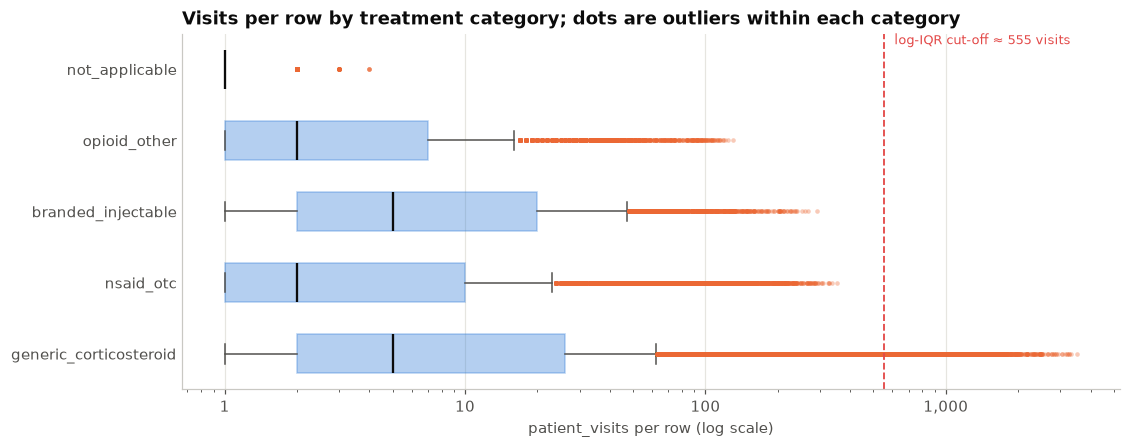

In [51]:
CAT_ORDER = ["generic_corticosteroid", "nsaid_otc", "branded_injectable", "opioid_other", "not_applicable"]
fig, ax = plt.subplots(figsize=(11, 4.2))
data = [fact_full.loc[fact_full["treatment_category"] == c, "patient_visits"] for c in CAT_ORDER]
bp = ax.boxplot(data, vert=False, widths=0.55, patch_artist=True,
                medianprops=dict(color=INK, lw=1.5), whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker="o", markersize=3, markerfacecolor=PALETTE[1], markeredgecolor="none", alpha=0.35))
for patch in bp["boxes"]:
    patch.set(facecolor=PALETTE[0], alpha=0.35, edgecolor=PALETTE[0])
ax.set_xscale("log")
ax.axvline(log_cutoff, color=PALETTE[7], lw=1.2, ls="--")
ax.text(log_cutoff * 1.1, 5.35, f"log-IQR cut-off ≈ {log_cutoff:,.0f} visits", fontsize=8.5, color=PALETTE[7])
ax.set_yticks(range(1, len(CAT_ORDER) + 1), CAT_ORDER)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("patient_visits per row (log scale)")
ax.set_title("Visits per row by treatment category; dots are outliers within each category")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
plt.show()

### 10.3 Segment shares (`gold_segment_adoption`)

A segment's share is a ratio, so small segments produce extreme values by chance: 1 Zilretta visit out of 2 is a 50% share. The scatter plots each segment's share against its size. Genuine outliers would be *large* segments with unusual shares; *small* segments at 50–100% are noise.

small,< 20 visits,≥ 20 visits,total
high,,,
share < 50%,12775,8682,21457
share ≥ 50%,175,4,179
total,12950,8686,21636


Segments with ≥20 visits: max share 54.2%, 99th percentile 11.8%


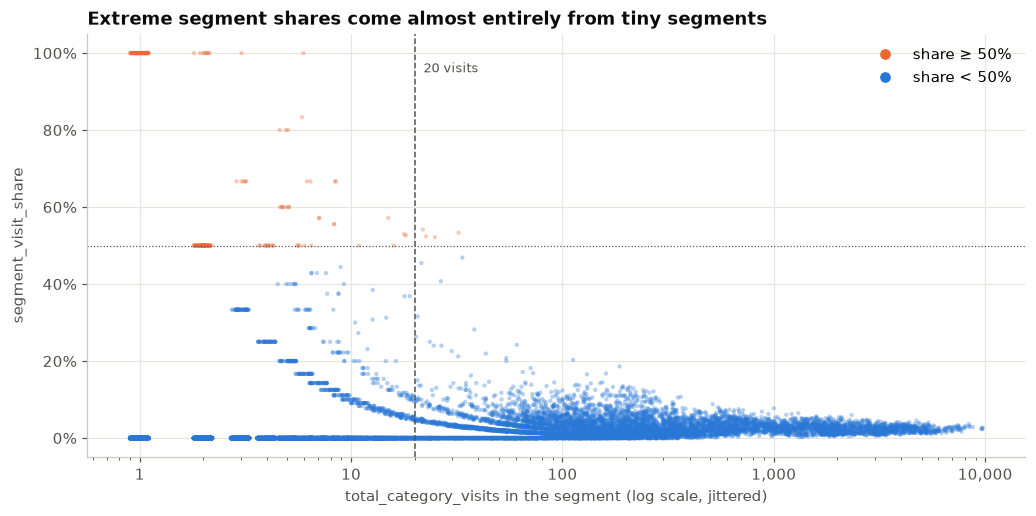

In [52]:
seg_plot = seg_joined.assign(high=seg_joined["segment_visit_share"] >= 0.5,
                             small=seg_joined["total_category_visits"] < MIN_VISITS)
summary = pd.crosstab(seg_plot["high"].map({True: "share ≥ 50%", False: "share < 50%"}),
                      seg_plot["small"].map({True: f"< {MIN_VISITS} visits", False: f"≥ {MIN_VISITS} visits"}),
                      margins=True, margins_name="total")
display(summary)
big = seg_plot[~seg_plot["small"]]["segment_visit_share"]
print(f"Segments with ≥{MIN_VISITS} visits: max share {big.max():.1%}, 99th percentile {big.quantile(0.99):.1%}")

jitter = np.random.default_rng(0).uniform(0.9, 1.1, len(seg_plot))
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(seg_plot["total_category_visits"] * jitter, seg_plot["segment_visit_share"], s=8,
           color=np.where(seg_plot["high"], PALETTE[1], PALETTE[0]), alpha=0.35, edgecolor="none")
ax.axvline(MIN_VISITS, color=MUTED, lw=1, ls="--")
ax.text(MIN_VISITS * 1.1, 0.95, f"{MIN_VISITS} visits", fontsize=8.5, color=MUTED)
ax.axhline(0.5, color=MUTED, lw=0.8, ls=":")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("total_category_visits in the segment (log scale, jittered)")
ax.set_ylabel("segment_visit_share")
ax.set_title("Extreme segment shares come almost entirely from tiny segments")
ax.legend([plt.Line2D([], [], marker="o", ls="", color=PALETTE[1]), plt.Line2D([], [], marker="o", ls="", color=PALETTE[0])],
          ["share ≥ 50%", "share < 50%"], loc="upper right", frameon=False)
plt.show()

**Read-out:**

- **April 2020 (COVID) is the one clear outlier, and every method agrees.** It is flagged by IQR, z-score and STL in generic, NSAID, office, hospital and telehealth visits, with March 2020 also flagged for generic and office visits. It is also the **only STL outlier in `visit_share`**: share jumped that month because generic volume fell harder than Zilretta volume. Keep it, but add a COVID indicator for Mar–May 2020 (or exclude those months when fitting), since a model would otherwise learn from a one-off shock.
- **Telehealth is outlier-heavy by nature.** IQR flags 17 months, because pre-COVID telehealth was near zero and anything since looks extreme. The z-score and STL flags (Apr–May 2020) are the meaningful ones.
- **Mar–Jul 2024 dip:**
  - Most volume series drop together in this window: office visits fall from ~95–106K to ~76–84K.
  - Zilretta's June 2024 is an STL outlier.
  - `visit_share` falls at the same time, but only gradually.

  A simultaneous drop across unrelated categories looks more like a **data-supply issue** than a change in treatment (for example, the Feb 2024 Change Healthcare outage disrupted US claims flows for months). This should be confirmed with the data provider before trusting 2024 volume levels. Shares are less affected, since numerator and denominator dip together.
- **Row-level "outliers" are real, not errors.** On the log scale, 1,883 rows (1.3%) exceed ~555 visits. All of them are generic corticosteroids (mostly Kenalog, Depo-Medrol and triamcinolone) prescribed by orthopedic surgeons and physician assistants. These are the highest-volume combinations and together carry **34% of all visits**, so dropping them would destroy the data. Use `log1p` or aggregate instead.
- **Extreme segment shares are small-sample noise.** 179 segments have share ≥ 50%, and **175 of them have fewer than 20 visits**. Among segments with ≥20 visits the maximum is 54% and the 99th percentile 11.8%. Filter or volume-weight segments (the 20-visit floor used in section 9 works) rather than removing individual values.
- **Nothing needs deleting.** No outlier found is an impossible value. The fixes are a COVID flag, a check on the 2024 dip, a log transform for row-level counts, and a minimum-volume rule for segments.

## 11. Anomaly detection

Section 10 looked for **extreme values in one column at a time**. Anomaly detection looks for **records that don't fit the expected pattern**, even when no single value is extreme. Three kinds are checked:

1. **Rule anomalies:** values that break a rule the data must follow, such as a share that doesn't equal its own numerator ÷ denominator, a label that contradicts its definition, or dates that disagree with their IDs. Any failure there is a pipeline bug. A plausibility rule is also included (pediatric specialties should treat children), where a failure points to a source-data problem.
2. **Multivariate anomalies:** months where the *combination* of movements is unusual. An **Isolation Forest** is used: it randomly splits the data and measures how quickly each month gets isolated. Unusual months are isolated in fewer splits and get a higher anomaly score.
3. **Statistical anomalies in segments:** specialty × demographic segments whose Zilretta share is further from that month's overall share than chance alone would allow, given the segment's size.

### 11.1 Rule-based integrity checks

In [53]:
rules = []
def rule(name, violations, checked):
    rules.append({"rule": name, "rows_checked": checked, "violations": int(violations)})

g_ = monthly_joined
d_ = pd.to_datetime(g_["calendar_date"])

# Monthly gold table
calc_share = g_["branded_injectable_visits"] / g_[["branded_injectable_visits", "generic_corticosteroid_visits",
                                                   "nsaid_otc_visits"]].sum(axis=1)
rule("visit_share = branded / (branded + generic + NSAID)", ((calc_share - g_["visit_share"]).abs() > 1e-12).sum(), len(g_))
# Adopted rule (PROPOSAL §18.2): monthly change in pp, in units of the trailing 12 months' std of past changes
change_pp = g_["visit_share"].diff() * 100
z_label = change_pp / change_pp.shift(1).rolling(12).std()
expected_label = np.select([z_label > 1, z_label < -1, z_label.notna()], ["Up", "Down", "Flat"], "NULL")
rule("direction_label matches the trailing-12 z-score rule (±1)", (expected_label != g_["direction_label"].fillna("NULL").to_numpy()).sum(), len(g_))
for k in (1, 2, 3):
    rule(f"visit_share_lag_{k} = share {k} month(s) earlier",
         ((g_["visit_share"].shift(k) - g_[f"visit_share_lag_{k}"]).abs() > 1e-12).sum(), len(g_) - k)
months_from_approval = (d_.dt.year - 2017) * 12 + d_.dt.month - 10          # FDA approval: Oct 2017
rule("months_since_launch = months since FDA approval (Oct 2017)", (months_from_approval != g_["months_since_launch"]).sum(), len(g_))

# Calendar dimension
rule("calendar_date matches month_id (YYYYMM)", (d_.dt.strftime("%Y%m").astype(int) != g_["month_id"]).sum(), len(g_))
rule("quarter matches month_number", (g_["quarter"] != (g_["month_number"] - 1) // 3 + 1).sum(), len(g_))
rule("months are consecutive, no gaps", (~d_.diff().dt.days.dropna().between(28, 31)).sum(), len(g_) - 1)

# Segment gold table vs. fact table
seg_calc = pd.read_sql(
    """SELECT f.month_id, f.specialty_id, f.demographic_id,
              SUM(CASE WHEN p.treatment_category = 'branded_injectable' THEN f.patient_visits ELSE 0 END) AS b,
              SUM(CASE WHEN p.treatment_category IN ('branded_injectable', 'generic_corticosteroid', 'nsaid_otc')
                       THEN f.patient_visits ELSE 0 END) AS t
       FROM fact_product_visits f JOIN dim_product p USING (product_id)
       GROUP BY 1, 2, 3 HAVING t > 0""", conn)
seg_chk = seg_full.merge(seg_calc, on=["month_id", "specialty_id", "demographic_id"], how="outer", indicator=True)
rule("segment_visit_share = branded / total", ((seg_full["branded_injectable_visits"] / seg_full["total_category_visits"]
                                                 - seg_full["segment_visit_share"]).abs() > 1e-12).sum(), len(seg_full))
rule("branded visits ≤ total visits in every segment", (seg_full["branded_injectable_visits"] > seg_full["total_category_visits"]).sum(), len(seg_full))
rule("every segment with category visits exists in gold (and vice versa)", (seg_chk["_merge"] != "both").sum(), len(seg_chk))
both = seg_chk[seg_chk["_merge"] == "both"]
rule("segment counts match fact_product_visits", ((both["b"] != both["branded_injectable_visits"])
                                                  | (both["t"] != both["total_category_visits"])).sum(), len(both))

# Cross-fact consistency: place-of-service total vs. product-visit total, per month
pos_vs_prod = pd.read_sql(
    """SELECT p.month_id, p.pos_visits, f.oa_visits, 1.0 * p.pos_visits / f.oa_visits AS ratio
       FROM (SELECT month_id, SUM(patient_visits) AS pos_visits FROM fact_place_of_service_visits GROUP BY 1) p
       JOIN (SELECT month_id, SUM(patient_visits) AS oa_visits FROM fact_product_visits
             JOIN dim_product USING (product_id) WHERE disease_area = 'OA' GROUP BY 1) f USING (month_id)""", conn)
ratio_z = (pos_vs_prod["ratio"] - pos_vs_prod["ratio"].mean()) / pos_vs_prod["ratio"].std()
rule("place-of-service ÷ product visits ratio stable (|z| ≤ 3)", (ratio_z.abs() > 3).sum(), len(pos_vs_prod))

# Plausibility: pediatric-only specialties should not see adult patients
# (INTERNAL MED/PEDIATRICS is excluded, as it legitimately treats adults)
peds = pd.read_sql(
    """SELECT d.age_band, f.patient_visits FROM fact_product_visits f
       JOIN dim_specialty s USING (specialty_id) JOIN dim_demographics d USING (demographic_id)
       WHERE s.specialty_name IN ('PEDIATRICS', 'PEDIATRIC CRITICAL CARE')""", conn)
adult = ~peds["age_band"].isin(["00 TO 02", "03 TO 09", "10 TO 19", "UNSPECIFIED"])
rule("pediatric specialties see only patients under 20", adult.sum(), len(peds))

rules = pd.DataFrame(rules)
rules["status"] = np.where(rules["violations"] == 0, "✓ pass", "✗ FAIL")
rules.style.hide(axis="index").format({"rows_checked": "{:,}"})

rule,rows_checked,violations,status
visit_share = branded / (branded + generic + NSAID),72,0,✓ pass
direction_label matches the trailing-12 z-score rule (±1),72,0,✓ pass
visit_share_lag_1 = share 1 month(s) earlier,71,0,✓ pass
visit_share_lag_2 = share 2 month(s) earlier,70,0,✓ pass
visit_share_lag_3 = share 3 month(s) earlier,69,0,✓ pass
months_since_launch = months since FDA approval (Oct 2017),72,0,✓ pass
calendar_date matches month_id (YYYYMM),72,0,✓ pass
quarter matches month_number,72,0,✓ pass
"months are consecutive, no gaps",71,0,✓ pass
segment_visit_share = branded / total,"21,636",0,✓ pass


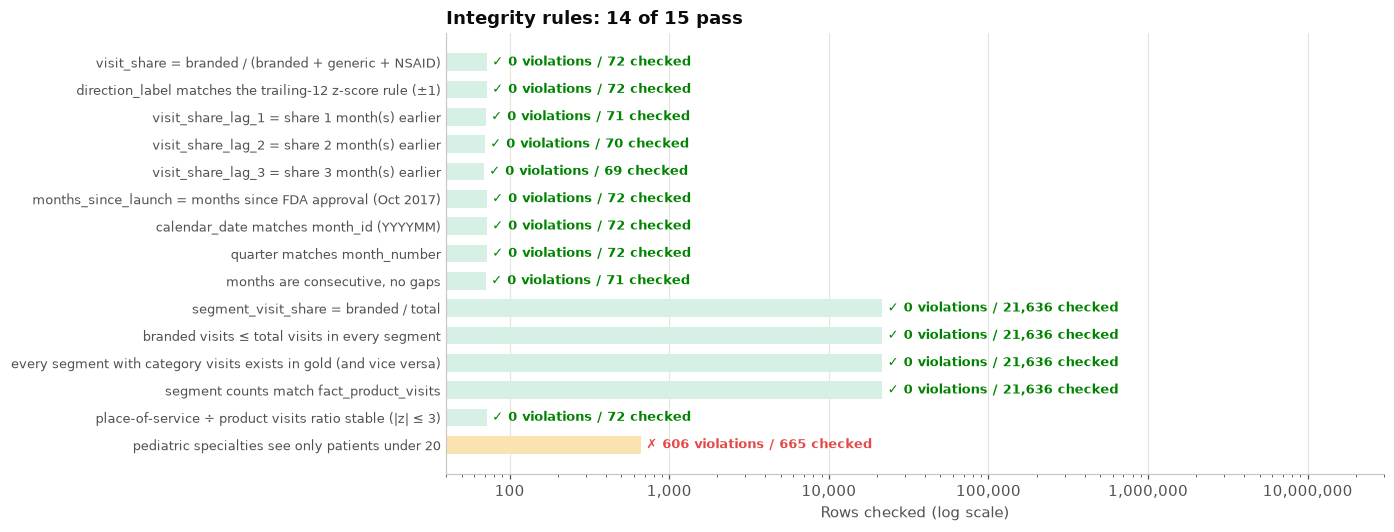

Place-of-service ÷ product-visit ratio: 1.276 – 1.335 (max |z| = 2.91)
Fact-table combinations with only opioid/RA visits, correctly absent from the segment table: 639


In [54]:
fig, ax = plt.subplots(figsize=(11, 5.2))
yy = np.arange(len(rules))[::-1]
ok = rules["violations"] == 0
ax.barh(yy, rules["rows_checked"], color=np.where(ok, "#d7f0e5", "#fbe3b0"), height=0.65)
for y, (n, v) in zip(yy, zip(rules["rows_checked"], rules["violations"])):
    ax.text(n * 1.08, y, f"{'✓' if v == 0 else '✗'} {v} violations / {n:,} checked", va="center", fontsize=8.5,
            color=PALETTE[5] if v == 0 else PALETTE[7], fontweight="bold")
ax.set_xscale("log")
ax.set_xlim(40, 3e7)
ax.set_yticks(yy, rules["rule"], fontsize=8.5)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("Rows checked (log scale)")
ax.set_title(f"Integrity rules: {ok.sum()} of {len(rules)} pass")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
plt.show()

print(f"Place-of-service ÷ product-visit ratio: {pos_vs_prod['ratio'].min():.3f} – {pos_vs_prod['ratio'].max():.3f} "
      f"(max |z| = {ratio_z.abs().max():.2f})")
print(f"Fact-table combinations with only opioid/RA visits, correctly absent from the segment table: "
      f"{pd.read_sql('''SELECT COUNT(*) AS n FROM (SELECT month_id, specialty_id, demographic_id FROM fact_product_visits
                        EXCEPT SELECT month_id, specialty_id, demographic_id FROM gold_segment_adoption)''', conn)['n'][0]}")

### 11.2 Multivariate anomalies: unusual months

The Isolation Forest is trained on **month-over-month changes** rather than levels, so that ordinary trend (e.g. the 2022–25 decline) doesn't count as anomalous. The inputs are:

- the change in `log(1 + visits)` for the 3 treatment categories and 4 settings, i.e. roughly the % change;
- the change in `visit_share`.

All changes are standardised first. `contamination=0.05` asks the model to flag roughly the most unusual 5% of months.

In [55]:
VOLUME_COLS = ["branded_injectable_visits", "generic_corticosteroid_visits", "nsaid_otc_visits",
               "office_visits", "hospital_visits", "other_visits", "telehealth_visits"]
mom = pd.concat([np.log1p(ts[VOLUME_COLS]).diff(), ts[["visit_share"]].diff()], axis=1).dropna()
X = StandardScaler().fit_transform(mom)

iso = IsolationForest(n_estimators=500, contamination=0.05, random_state=0).fit(X)
anomaly = pd.DataFrame({"anomaly_score": -iso.score_samples(X), "flagged": iso.predict(X) == -1}, index=mom.index)
z_changes = pd.DataFrame(X, index=mom.index, columns=[c.replace("_visits", "") for c in mom.columns])

top = anomaly.sort_values("anomaly_score", ascending=False).head(8)
top.index = top.index.strftime("%b %Y")
top

,anomaly_score,flagged
calendar_date,,
Apr 2020,0.791086,True
May 2020,0.781888,True
Mar 2020,0.630015,True
Mar 2021,0.596636,True
Jun 2020,0.584311,False
Nov 2019,0.503380,False
Jan 2021,0.495080,False
Mar 2023,0.481311,False


**Top:** the anomaly score for each month, with flagged months in orange. **Bottom:** for the 8 highest-scoring months, how far each input moved that month, in standard deviations (red = unusually up, blue = unusually down). This shows *why* each month was flagged.

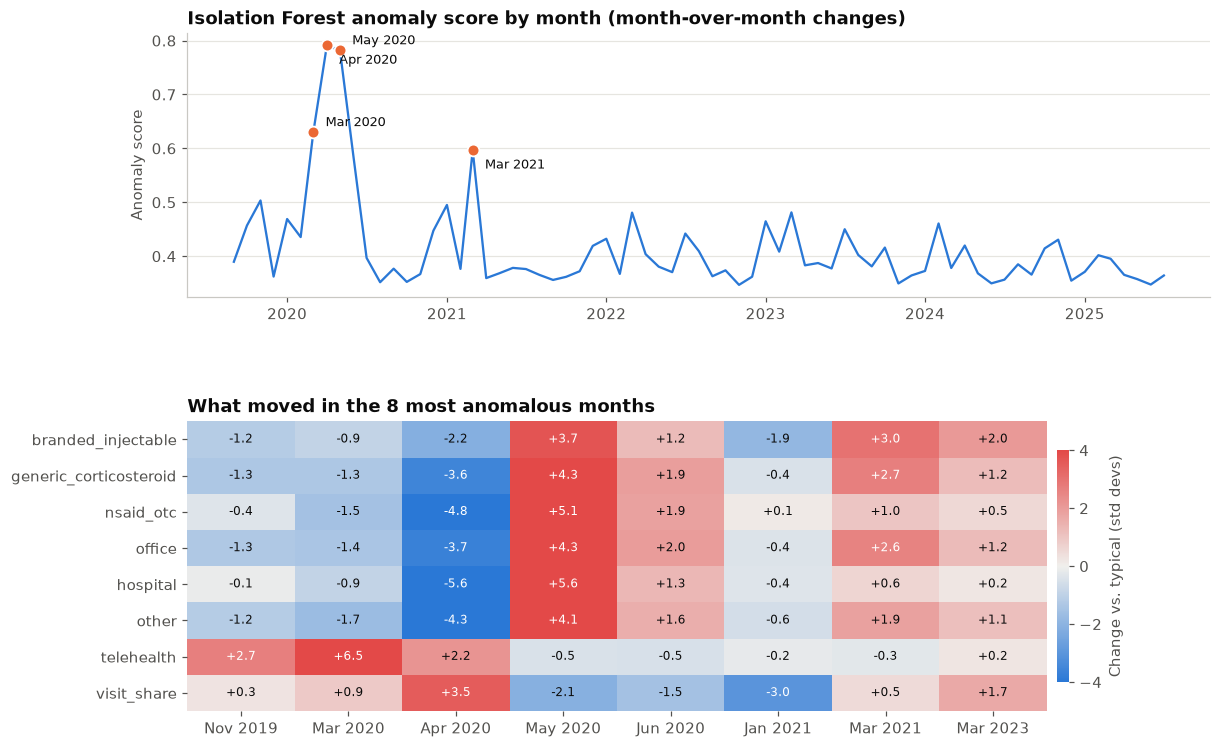

In [56]:
fig, (ax_s, ax_h) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [1, 1.1], "hspace": 0.45})

ax_s.plot(anomaly.index, anomaly["anomaly_score"], color=PALETTE[0], lw=1.5)
fl = anomaly[anomaly["flagged"]]
ax_s.scatter(fl.index, fl["anomaly_score"], s=60, color=PALETTE[1], edgecolor="white", linewidth=1.2, zorder=3)
for i, (d, v) in enumerate(fl["anomaly_score"].items()):
    ax_s.annotate(d.strftime("%b %Y"), (d, v), xytext=(8, -12 if i % 2 else 4), textcoords="offset points",
                  fontsize=8.5, color=INK)
ax_s.set_ylabel("Anomaly score")
ax_s.set_title("Isolation Forest anomaly score by month (month-over-month changes)")
ax_s.grid(axis="x", visible=False)

top8 = anomaly["anomaly_score"].nlargest(8).index.sort_values()
hm = z_changes.loc[top8]
im = ax_h.imshow(hm.T.values, cmap=DIVERGING, vmin=-4, vmax=4, aspect="auto")
for (y, x), v in np.ndenumerate(hm.T.values):
    ax_h.text(x, y, f"{v:+.1f}", ha="center", va="center", fontsize=8, color="white" if abs(v) > 2.5 else INK)
ax_h.set_xticks(range(len(top8)), top8.strftime("%b %Y"))
ax_h.set_yticks(range(hm.shape[1]), hm.columns)
ax_h.grid(visible=False)
for s in ax_h.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax_h, shrink=0.8, pad=0.01)
cb.set_label("Change vs. typical (std devs)")
cb.outline.set_visible(False)
ax_h.set_title("What moved in the 8 most anomalous months")
plt.show()

### 11.3 Statistical anomalies: segments far from expected

If every segment adopted Zilretta at that month's overall rate *p₀*, a segment with *n* category visits would have a share of about *p₀ ± 3·√(p₀(1−p₀)/n)* 99.7% of the time. A segment outside that band is a **statistically significant** anomaly: too far off to be chance.

The z-score approximation only works for reasonably large *n*, so only segments with **≥ 20 visits** are tested. The **funnel plot** below shows why the band narrows: the larger the segment, the less its share can wander by chance.

In [57]:
p0 = (seg_joined.groupby("month_id")[["branded_injectable_visits", "total_category_visits"]].sum()
      .pipe(lambda d: d["branded_injectable_visits"] / d["total_category_visits"]).rename("p0"))
tested = seg_joined[seg_joined["total_category_visits"] >= MIN_VISITS].join(p0, on="month_id")
tested["z"] = (tested["segment_visit_share"] - tested["p0"]) / np.sqrt(
    tested["p0"] * (1 - tested["p0"]) / tested["total_category_visits"])
tested["anomaly"] = np.select([tested["z"] > 3, tested["z"] < -3], ["above expected", "below expected"], "normal")

print(f"Segments tested: {len(tested):,}")
print(tested["anomaly"].value_counts().to_string(), "\n")

by_spec = (tested.groupby("specialty_name")["anomaly"].value_counts().unstack(fill_value=0)
           .reindex(columns=["above expected", "below expected", "normal"], fill_value=0))
by_spec["tested"] = by_spec.sum(axis=1)
by_spec["% anomalous"] = (by_spec["above expected"] + by_spec["below expected"]) / by_spec["tested"] * 100
by_spec = by_spec.sort_values(["above expected", "below expected"], ascending=False)
by_spec.head(10).style.format({"% anomalous": "{:.0f}"})

Segments tested: 8,686
anomaly
normal            7482
above expected     885
below expected     319 



anomaly,above expected,below expected,normal,tested,% anomalous
specialty_name,,,,,
PHYSICAL MEDICINE & REHAB,219,0,505,724,30
SPORTS MEDICINE,212,0,536,748,28
PHYSICIAN ASSISTANT,146,61,657,864,24
NURSE PRACTITIONER,118,2,734,854,14
OSTEOPATHIC MEDICINE,84,1,769,854,10
ORTHOPEDIC SURGERY,55,223,608,886,31
ANESTHESIOLOGY,23,0,644,667,3
PAIN MEDICINE,16,0,664,680,2
PEDIATRICS,10,0,0,10,100


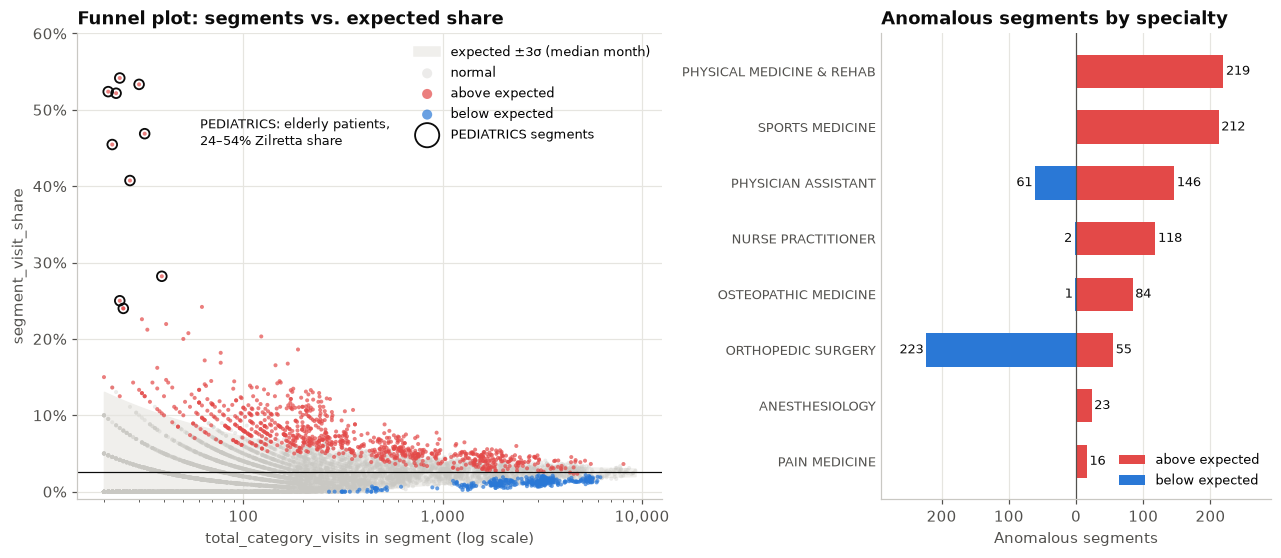

In [58]:
fig, (ax_f, ax_b) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.5, 1], "wspace": 0.45})

# Funnel: share vs. size, with the 3-sigma band around the median monthly p0
n_grid = np.logspace(np.log10(MIN_VISITS), np.log10(tested["total_category_visits"].max()), 200)
p_mid = p0.median()
band = 3 * np.sqrt(p_mid * (1 - p_mid) / n_grid)
ax_f.fill_between(n_grid, np.clip(p_mid - band, 0, None), p_mid + band, color="#f0efec", zorder=0,
                  label="expected ±3σ (median month)")
colors_a = {"normal": "#c9c8c3", "above expected": PALETTE[7], "below expected": PALETTE[0]}
for lab, col in colors_a.items():
    sub = tested[tested["anomaly"] == lab]
    ax_f.scatter(sub["total_category_visits"], sub["segment_visit_share"], s=7, color=col,
                 alpha=0.35 if lab == "normal" else 0.7, edgecolor="none", label=lab)
ax_f.axhline(p_mid, color=INK, lw=0.8)
ax_f.set_xscale("log")
peds_pts = tested[tested["specialty_name"] == "PEDIATRICS"]
ax_f.scatter(peds_pts["total_category_visits"], peds_pts["segment_visit_share"], s=40, facecolor="none",
             edgecolor=INK, linewidth=1.2, zorder=4, label="PEDIATRICS segments")
ax_f.annotate("PEDIATRICS: elderly patients,\n24–54% Zilretta share", (peds_pts["total_category_visits"].max(), 0.47),
              xytext=(25, 0), textcoords="offset points", fontsize=8.5, color=INK, va="center")
ax_f.set_ylim(-0.01, 0.6)
ax_f.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax_f.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax_f.set_xlabel("total_category_visits in segment (log scale)")
ax_f.set_ylabel("segment_visit_share")
ax_f.set_title("Funnel plot: segments vs. expected share")
ax_f.legend(loc="upper right", frameon=False, markerscale=2.5, fontsize=8.5)

top_spec = by_spec[(by_spec["above expected"] + by_spec["below expected"]) > 0].head(8).iloc[::-1]
yy = np.arange(len(top_spec))
ax_b.barh(yy, top_spec["above expected"], color=PALETTE[7], height=0.6, label="above expected")
ax_b.barh(yy, -top_spec["below expected"], color=PALETTE[0], height=0.6, label="below expected")
for y, (a, b) in enumerate(zip(top_spec["above expected"], top_spec["below expected"])):
    if a: ax_b.text(a + 4, y, str(a), va="center", fontsize=8.5, color=INK)
    if b: ax_b.text(-b - 4, y, str(b), va="center", ha="right", fontsize=8.5, color=INK)
ax_b.axvline(0, color=MUTED, lw=0.8)
ax_b.set_yticks(yy, top_spec.index, fontsize=8.5)
lim = max(top_spec["above expected"].max(), top_spec["below expected"].max()) * 1.3
ax_b.set_xlim(-lim, lim)
ax_b.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{abs(v):.0f}"))
ax_b.set_xlabel("Anomalous segments")
ax_b.set_title("Anomalous segments by specialty")
ax_b.grid(axis="y", visible=False)
ax_b.tick_params(axis="y", length=0)
ax_b.legend(loc="lower right", frameon=False, fontsize=8.5)
plt.show()

**Read-out:**

- **The pipeline is internally consistent: all 14 computation rules pass with 0 violations.**
  - The stored shares equal their own formulas.
  - `direction_label` follows the adopted trailing-12 z-score rule exactly (the same labels section 12.4 derives).
  - The lags are true shifts, and `months_since_launch` counts from the Oct 2017 FDA approval.
  - The calendar is consistent and gap-free.
  - Every segment reconciles to `fact_product_visits`.

  The 639 fact combinations with only opioid/RA visits are correctly left out of the segment table, because their share would be 0 ÷ 0. Place-of-service totals run a steady ~1.28–1.33× product-visit totals (they count on a different basis) with no anomalous month. The pipeline computes what it says it computes, with the one exception found in section 9 (the rolling averages included the current month), which `build_gold.py` now fixes.
- **One source-data anomaly: the `PEDIATRICS` specialty is treating elderly patients with Zilretta.**
  - The plausibility rule fails. **95% of `PEDIATRICS` visits are for patients aged 20+** (across all products; 99% for OA products alone, the remainder being RA/biologic visits that do include children), mostly 65–84.
  - Zilretta use in this specialty appears suddenly in **Oct 2024** (0 visits in 2019–2023; 83 in 2024 and 224 in Jan–Jul 2025).
  - The 10 PEDIATRICS segments large enough to test all sit far above expected share, at 24–54% vs ~2% overall; all are women aged 65–84.

  Pediatricians do not treat knee OA in 75-year-olds, so this is almost certainly **one adult-care prescriber mis-coded as Pediatrics** in the source data. It is small (~300 Zilretta visits), but it would distort any specialty-level result for Pediatrics and should be raised with the data provider or re-mapped.
- **Unusual months are almost all COVID.**
  - **Mar, Apr and May 2020** (plus Mar 2021) are the flagged multivariate anomalies. The three COVID months are the clear ones: every category and setting collapsed and then rebounded together while telehealth spiked.
  - The next-highest months (e.g. early 2021, Mar 2023) are milder mixed movements rather than one extreme value.
  - The Mar–Jul 2024 dip does *not* stand out here. It unfolded gradually over several months, so no single month-over-month change is unusual, which is why it was caught by the trend-aware STL method in section 10 instead.
- **Segment anomalies are driven by specialty, and they are systematic.** Of the 8,686 segments tested (≥20 visits), about 14% are significantly off the expected share (885 above, 319 below).
  - **Above expected:** Physical Medicine & Rehab and Sports Medicine are *never* below it; Nurse Practitioners and Osteopathic Medicine are mostly above.
  - **Below expected:** **Orthopedic Surgery**, the largest prescriber (42% of visits, 223 segments below vs 55 above), and Family Practice (31 below, 0 above).
  - Apart from Pediatrics, these are not errors. They show Zilretta adoption depends heavily on specialty, consistent with section 9 (η = 0.67), and they identify where share is under-penetrated relative to volume.

## 12. Z-scores

A **z-score** re-expresses a value as the number of standard deviations it sits from its column's mean:

$$z = \frac{x - \text{mean}}{\text{std}}$$

After the transform every column has mean 0 and std 1, so columns with very different units can be compared on one scale (z = +2 means "2 std above normal", whatever the unit). Sections 4, 10 and 11 used z-scores as a tool. This section looks at them directly:

1. **Standardising** the monthly features: what the z-scored data looks like.
2. **Standard vs. robust z-scores:** why the ordinary version can hide the very outliers it is meant to find.
3. **Rolling z-score of the target:** how unusual each month is compared with the *recent past*, rather than the whole period.
4. **Z-scores of monthly change:** using them to define Up/Down/Flat, given that the original ±1pp rule labelled every month Flat (the warehouse now uses the z-score rule this section develops).

### 12.1 Standardising the monthly features

In [59]:
Z_COLS = ["visit_share", "visit_share_lag_1", "visit_share_lag_2", "visit_share_lag_3", "months_since_launch",
          "branded_injectable_visits", "generic_corticosteroid_visits", "nsaid_otc_visits",
          "office_visits", "hospital_visits", "other_visits", "telehealth_visits"]
z_all = (ts[Z_COLS] - ts[Z_COLS].mean()) / ts[Z_COLS].std()

z_summary = pd.DataFrame({
    "mean_after": z_all.mean(), "std_after": z_all.std(),
    "|z| > 2": (z_all.abs() > 2).sum(), "|z| > 3": (z_all.abs() > 3).sum(),
    "max |z|": z_all.abs().max(),
    "month of max |z|": z_all.abs().idxmax().dt.strftime("%b %Y"),
})
z_summary.style.format({"mean_after": "{:.2f}", "std_after": "{:.2f}", "max |z|": "{:.2f}"})

,mean_after,std_after,|z| > 2,|z| > 3,max |z|,month of max |z|
visit_share,0.00,1.00,1,0,2.09,Dec 2021
visit_share_lag_1,0.00,1.00,1,0,2.08,Jan 2022
visit_share_lag_2,-0.00,1.00,1,0,2.08,Feb 2022
visit_share_lag_3,-0.00,1.00,1,0,2.09,Mar 2022
months_since_launch,0.00,1.00,0,0,1.70,Aug 2019
branded_injectable_visits,-0.00,1.00,0,0,1.92,Mar 2022
generic_corticosteroid_visits,0.00,1.00,2,1,3.82,Apr 2020
nsaid_otc_visits,0.00,1.00,3,1,4.23,Apr 2020
office_visits,-0.00,1.00,1,1,3.93,Apr 2020
hospital_visits,-0.00,1.00,1,1,5.46,Apr 2020


The heatmap shows the whole monthly table after standardising, with one row per feature and one column per month. Red is above the feature's average and blue is below. Reading across a row shows each feature's history on a common scale. Reading down a column shows how unusual that month was across all features at once.

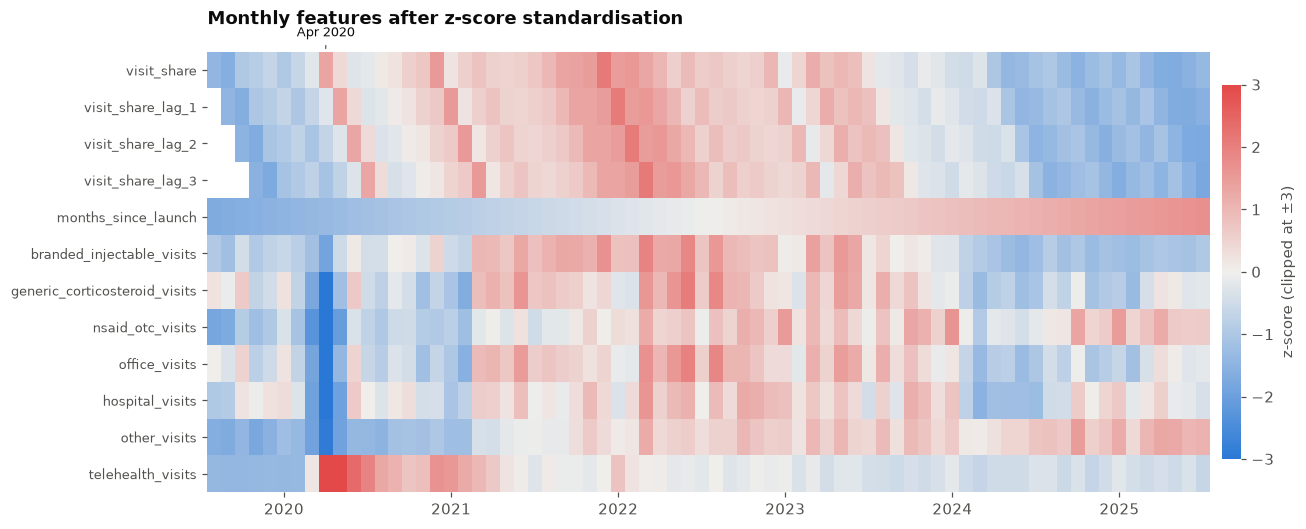

In [60]:
fig, ax = plt.subplots(figsize=(14, 5.2))
im = ax.imshow(z_all.T.values, cmap=DIVERGING, vmin=-3, vmax=3, aspect="auto", interpolation="nearest")
ax.set_yticks(range(len(Z_COLS)), Z_COLS, fontsize=8.5)
jan = [i for i, d in enumerate(z_all.index) if d.month == 1]
ax.set_xticks(jan, [z_all.index[i].year for i in jan])
ax.grid(visible=False)
for s in ax.spines.values():
    s.set_visible(False)
apr20 = list(z_all.index).index(pd.Timestamp("2020-04-01"))
ax.annotate("Apr 2020", (apr20, -0.5), xytext=(0, 10), textcoords="offset points", ha="center",
            fontsize=8.5, color=INK, annotation_clip=False,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.01)
cb.set_label("z-score (clipped at ±3)")
cb.outline.set_visible(False)
ax.set_title("Monthly features after z-score standardisation", pad=18)
plt.show()

### 12.2 Standard vs. robust z-scores

The standard z-score has a weakness: an extreme value **inflates the std it is divided by**, which shrinks its own z-score. This is called *masking*. The **robust z-score** replaces mean → median and std → MAD (median absolute deviation, scaled by 1.4826 to match the std for normal data), and a single extreme month cannot move either of those:

$$z_{robust} = \frac{x - \text{median}}{1.4826 \times \text{MAD}}$$

In [61]:
med = ts[Z_COLS].median()
mad = (ts[Z_COLS] - med).abs().median() * 1.4826
z_rob = (ts[Z_COLS] - med) / mad

z_compare = pd.DataFrame({
    "std (standard)": ts[Z_COLS].std(), "1.4826×MAD (robust)": mad,
    "max |z| standard": z_all.abs().max(), "max |z| robust": z_rob.abs().max(),
    "months |z|>3 standard": (z_all.abs() > 3).sum(), "months |z|>3 robust": (z_rob.abs() > 3).sum(),
})
z_compare.style.format("{:,.4g}", subset=["std (standard)", "1.4826×MAD (robust)"]) \
    .format("{:.2f}", subset=["max |z| standard", "max |z| robust"])

,std (standard),1.4826×MAD (robust),max |z| standard,max |z| robust,months |z|>3 standard,months |z|>3 robust
visit_share,0.004353,0.005077,2.09,1.66,0,0
visit_share_lag_1,0.004327,0.005073,2.08,1.63,0,0
visit_share_lag_2,0.004281,0.004818,2.08,1.71,0,0
visit_share_lag_3,0.004215,0.004563,2.09,1.80,0,0
months_since_launch,20.93,26.69,1.70,1.33,0,0
branded_injectable_visits,507.3,716.1,1.92,1.36,0,0
generic_corticosteroid_visits,1.029e+04,1.085e+04,3.82,3.64,1,1
nsaid_otc_visits,"1,050",838.4,4.23,5.46,1,2
office_visits,1.405e+04,1.415e+04,3.93,3.92,1,1
hospital_visits,496,361.8,5.46,7.76,1,1


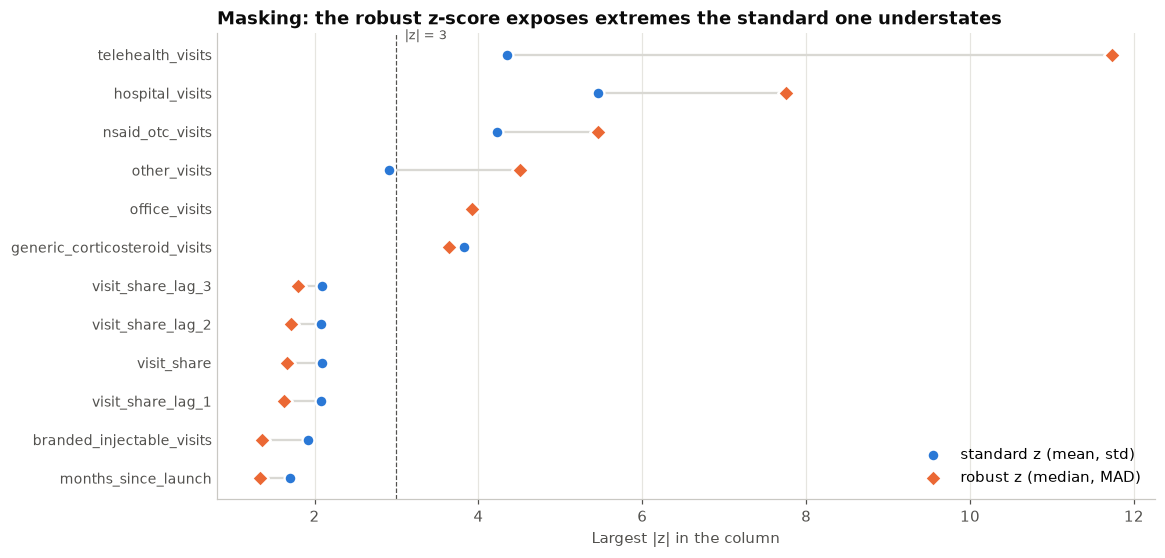

In [62]:
plot_zc = z_compare.sort_values("max |z| robust")
y = np.arange(len(plot_zc))

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.hlines(y, plot_zc[["max |z| standard", "max |z| robust"]].min(axis=1),
          plot_zc[["max |z| standard", "max |z| robust"]].max(axis=1), color="#d9d8d3", lw=1.5)
ax.scatter(plot_zc["max |z| standard"], y, s=60, color=PALETTE[0], edgecolor="white", linewidth=1.5,
           zorder=3, label="standard z (mean, std)")
ax.scatter(plot_zc["max |z| robust"], y, s=60, color=PALETTE[1], marker="D", edgecolor="white", linewidth=1.5,
           zorder=3, label="robust z (median, MAD)")
ax.axvline(3, color=MUTED, lw=0.8, ls="--")
ax.text(3.1, len(plot_zc) - 0.6, "|z| = 3", fontsize=8.5, color=MUTED)
ax.set_yticks(y, plot_zc.index, fontsize=9)
ax.set_xlabel("Largest |z| in the column")
ax.set_title("Masking: the robust z-score exposes extremes the standard one understates")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="lower right", frameon=False)
plt.show()

### 12.3 Rolling z-score of the target

A whole-period z-score compares a month with 2019–2025 as a whole. Because `visit_share` has long trends, that mostly says "was share high or low in that era". A **rolling z-score** compares each month with the **12 months before it** (mean and std of the prior year, excluding the month itself):

- |z| > 2 means share moved unusually far from its recent norm.
- Because only past data is used, this could be computed in real time as an early-warning signal.

In [63]:
share = ts["visit_share"]
prior_mean = share.shift(1).rolling(12).mean()
prior_std = share.shift(1).rolling(12).std()
rolling_z = ((share - prior_mean) / prior_std).rename("rolling_z")

flag_rz = rolling_z[rolling_z.abs() > 2]
print(f"Months with a 12-month history: {rolling_z.notna().sum()};  |rolling z| > 2: {len(flag_rz)}")
flag_rz.to_frame().assign(visit_share=share[flag_rz.index], prior_12m_mean=prior_mean[flag_rz.index]) \
    .set_axis(flag_rz.index.strftime("%b %Y")).style.format({"rolling_z": "{:+.2f}", "visit_share": "{:.2%}",
                                                             "prior_12m_mean": "{:.2%}"})

Months with a 12-month history: 60;  |rolling z| > 2: 6


,rolling_z,visit_share,prior_12m_mean
calendar_date,,,
Dec 2020,+2.31,3.14%,2.48%
Dec 2021,+2.69,3.38%,2.85%
Jan 2023,-2.55,2.42%,2.85%
Aug 2023,-2.26,2.39%,2.74%
May 2024,-2.30,1.86%,2.42%
Apr 2025,-2.40,1.75%,1.93%


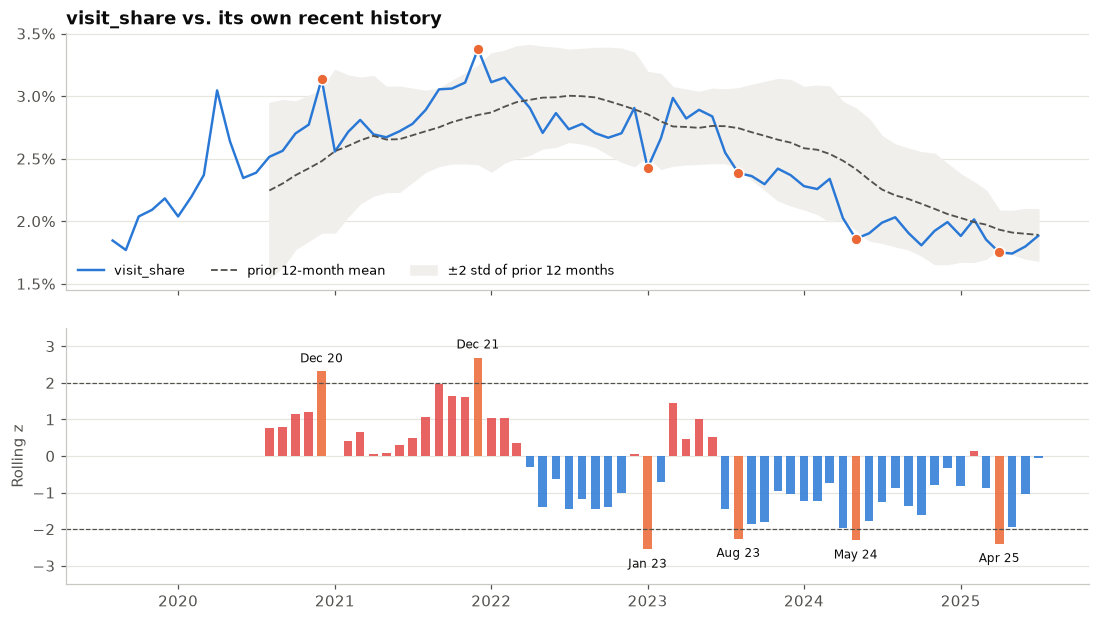

In [64]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, gridspec_kw={"hspace": 0.15})

ax1.plot(share.index, share, color=PALETTE[0], lw=1.6, label="visit_share")
ax1.plot(prior_mean.index, prior_mean, color=MUTED, lw=1.2, ls="--", label="prior 12-month mean")
ax1.fill_between(share.index, prior_mean - 2 * prior_std, prior_mean + 2 * prior_std, color="#f0efec",
                 label="±2 std of prior 12 months")
ax1.scatter(flag_rz.index, share[flag_rz.index], s=50, color=PALETTE[1], edgecolor="white", zorder=3)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
ax1.set_title("visit_share vs. its own recent history")
ax1.legend(loc="lower left", frameon=False, fontsize=8.5, ncol=3)
ax1.grid(axis="x", visible=False)

ax2.bar(rolling_z.index, rolling_z, width=20,
        color=np.where(rolling_z.abs() > 2, PALETTE[1], np.where(rolling_z > 0, PALETTE[7], PALETTE[0])), alpha=0.85)
for v in (-2, 2):
    ax2.axhline(v, color=MUTED, lw=0.8, ls="--")
for d, v in flag_rz.items():
    ax2.annotate(d.strftime("%b %y"), (d, v), xytext=(0, 6 if v > 0 else -12), textcoords="offset points",
                 ha="center", fontsize=8, color=INK)
ax2.set_ylabel("Rolling z")
ax2.set_ylim(-3.5, 3.5)
ax2.grid(axis="x", visible=False)
plt.show()

### 12.4 Z-scores of monthly change: a usable direction label

The pipeline originally labelled a month *Up* or *Down* only if share moved more than **±1 percentage point**, which makes all 71 labels *Flat* (reproduced below). The warehouse now uses the trailing 12-month version of the rule described next. Measuring each monthly change in **standard deviations of typical monthly change** gives a threshold scaled to how much share actually moves. Two versions are compared, both using a ±1 std threshold:

- **Whole-period std:** simple, but uses future data, so it is fine for EDA and not for training.
- **Trailing 12-month std of past changes:** uses only past data, so it is safe for a model.

In [65]:
chg = share.diff()
z_chg_full = (chg - chg.mean()) / chg.std()
z_chg_trail = chg / chg.shift(1).rolling(12).std()

def label(z, k=1):
    return pd.Series(np.select([z > k, z < -k], ["Up", "Down"], "Flat"), index=z.index).where(z.notna())

label_compare = pd.DataFrame({
    "original rule (±1pp, fixed)": label(chg, k=0.01).value_counts(),
    "z of change, whole-period std (±1)": label(z_chg_full).value_counts(),
    "z of change, trailing 12m std (±1)": label(z_chg_trail).value_counts(),
}).reindex(["Up", "Flat", "Down"]).fillna(0).astype(int)
stored_matches_trailing = bool((ts["direction_label"].fillna("NULL").to_numpy() == label(z_chg_trail).fillna("NULL").to_numpy()).all())
print(f"Warehouse direction_label equals the trailing-12m labels below on all {len(ts)} months: {stored_matches_trailing}")
print(f"Std of monthly change in share: {chg.std() * 100:.2f}pp  (the ±1pp rule is ~{0.01 / chg.std():.0f} std wide)\n")
label_compare

Warehouse direction_label equals the trailing-12m labels below on all 72 months: True
Std of monthly change in share: 0.19pp  (the ±1pp rule is ~5 std wide)



,"original rule (±1pp, fixed)","z of change, whole-period std (±1)","z of change, trailing 12m std (±1)"
Up,0,7,7
Flat,71,56,43
Down,0,8,9


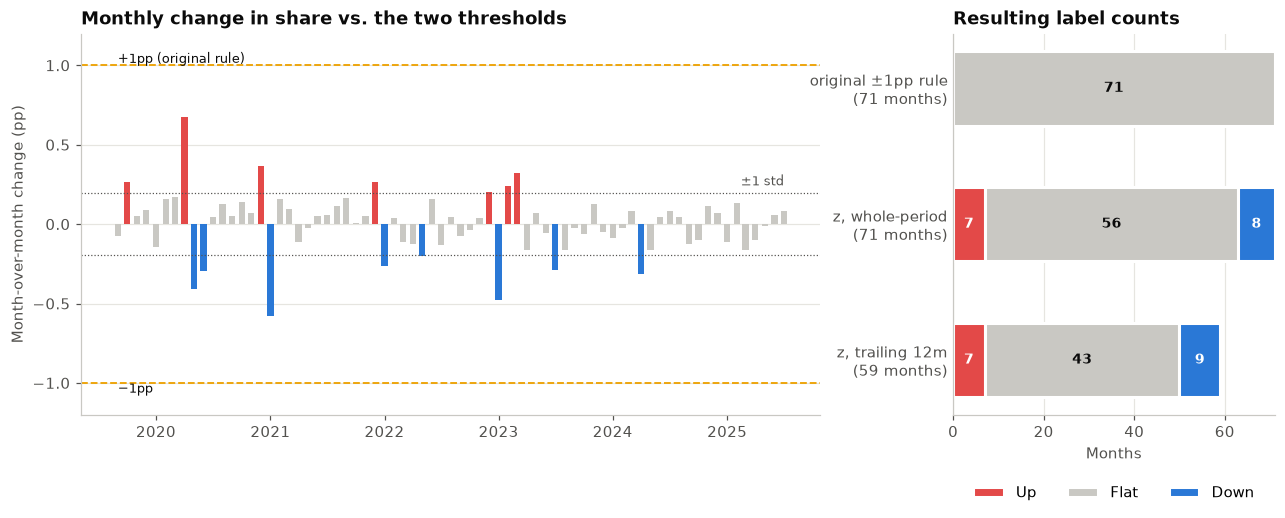

In [66]:
fig, (ax_c, ax_l) = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [2.3, 1], "wspace": 0.25})

lab_full = label(z_chg_full)
bar_colors = lab_full.map({"Up": PALETTE[7], "Down": PALETTE[0], "Flat": "#c9c8c3"}).fillna("#c9c8c3")
ax_c.bar(chg.index, chg * 100, width=20, color=bar_colors)
for v, txt in [(1, "+1pp (original rule)"), (-1, "−1pp")]:
    ax_c.axhline(v, color=PALETTE[3], lw=1.2, ls="--")
    ax_c.text(chg.index[1], v + 0.04 * np.sign(v), txt, fontsize=8.5, color=INK, va="center")
for v in (chg.mean() + chg.std(), chg.mean() - chg.std()):
    ax_c.axhline(v * 100, color=MUTED, lw=0.8, ls=":")
ax_c.text(chg.index[-1], (chg.mean() + chg.std()) * 100 + 0.05, "±1 std", fontsize=8.5, color=MUTED, ha="right")
ax_c.set_ylim(-1.2, 1.2)
ax_c.set_ylabel("Month-over-month change (pp)")
ax_c.set_title("Monthly change in share vs. the two thresholds")
ax_c.grid(axis="x", visible=False)

lc = label_compare.T
left = np.zeros(len(lc))
for lab_, col in [("Up", PALETTE[7]), ("Flat", "#c9c8c3"), ("Down", PALETTE[0])]:
    ax_l.barh(range(len(lc)), lc[lab_], left=left, color=col, height=0.55, edgecolor="white", linewidth=2, label=lab_)
    for y, (l, v) in enumerate(zip(left, lc[lab_])):
        if v:
            ax_l.text(l + v / 2, y, str(v), ha="center", va="center", fontsize=9,
                      color=INK if lab_ == "Flat" else "white", fontweight="bold")
    left += lc[lab_].values
ax_l.set_yticks(range(len(lc)), [f"{n}\n({int(t)} months)" for n, t in
                zip(["original ±1pp rule", "z, whole-period", "z, trailing 12m"], lc.sum(axis=1))])
ax_l.invert_yaxis()
ax_l.set_xlabel("Months")
ax_l.set_title("Resulting label counts")
ax_l.grid(axis="y", visible=False)
ax_l.tick_params(axis="y", length=0)
ax_l.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.show()

**Read-out:**

- **Standardising works as intended.** Every feature ends with mean 0.00 and std 1.00, so features measured in shares, months and visit counts can sit on one scale. The heatmap shows three things at once:
  - **April 2020** is a deep blue column across every volume feature, with telehealth the one red exception.
  - Share, its lags and Zilretta volume go red through 2021–23 and blue after 2024.
  - `months_since_launch` is a smooth blue-to-red ramp, a pure clock.
- **Standard z-scores understate extremes (masking).** Because April 2020 inflates the std, the robust z-score finds larger extremes:
  - hospital visits: 5.5 → 7.8
  - NSAID: 4.2 → 5.5
  - other visits: 2.9 → 4.5
  - telehealth: 12 months flagged instead of 2, because its "normal" level is so low that the whole COVID period stands out.

  For the monthly target and lags both versions agree that nothing is extreme (max |z| ≈ 2). **Use robust z-scores for outlier screening** and standard z-scores for **scaling model inputs**.
- **The rolling z-score finds 6 months where share broke from its recent norm:**
  - rises in Dec 2020 and Dec 2021, both December spikes;
  - drops in Jan 2023, Aug 2023, May 2024 and Apr 2025.

  None of these stand out in a whole-period z-score (max 2.1), because the long trend dominates it. For a direction model, measuring each month against the recent past is more informative than measuring it against the full history.
- **A z-score threshold makes the direction label usable.** Monthly change in share has a std of only **0.19pp**, so the ±1pp rule is about 5 std wide and nothing ever crosses it (all 71 months Flat). A ±1 std threshold gives a real three-class target:
  - whole-period std: **7 Up / 56 Flat / 8 Down**;
  - trailing 12-month std, which uses only past data and is safe for modelling: **7 Up / 43 Flat / 9 Down** (on 59 months, since the first 12 have no trailing history).

  Replacing the fixed ±1pp rule with a volatility-scaled threshold was the key change needed before a direction classifier could be trained. It is now implemented in `build_gold.py`, and section 11 verifies that the stored labels equal the trailing 12-month version exactly.

## 13. Feature engineering

This section builds new features from what sections 1–12 found. Nothing is written back to the database; the features exist only in pandas. Every feature traces back to a specific finding:

| Finding | Section | Engineered response |
|---|---|---|
| Original ±1pp rule labels every month Flat | 12 | New target: `direction_z` (volatility-scaled Up/Down/Flat), now implemented as the warehouse's `direction_label` |
| Original rolling averages included the current month (leakage; fixed in `build_gold.py`) | 9 | Prior-month windows (what the stored `visit_share_roll_*` columns now hold) |
| Last month's change tends to reverse | 9 | Momentum feature: previous month's change |
| December spike, January drop | 9, 12 | `month_sin` / `month_cos`, `is_december`, `is_january` |
| Share only matters relative to its recent level | 12 | Distance from trailing mean; lagged rolling z |
| Volumes are skewed and shift with the mix | 4, 9 | Log growth rates and mix ratios instead of raw counts |
| COVID shock; Mar–Jul 2024 dip | 10, 11 | Event flags |
| Redundant pairs (year ≈ months_since_launch, office ≈ generic, quarter ≈ month) | 9 | Keep one of each |
| `specialty_name`: 50 levels, 22 rare | 8 | Group rare levels; prior-period specialty adoption rate |
| Tiny segments are noise | 2, 10 | Minimum volume filter + volume weight |

**The leakage rule used throughout:** a model predicting month *t* may only use information available at the end of month *t − 1*. Every monthly feature is therefore computed from `ts.shift(1)` (the previous month's row) or from windows that end at *t − 1*.

### 13.1 Monthly features

In [67]:
prev = ts.shift(1)                                   # everything known at the end of the previous month
cats = ["branded_injectable_visits", "generic_corticosteroid_visits", "nsaid_otc_visits"]
settings = ["office_visits", "hospital_visits", "other_visits", "telehealth_visits"]

fe = pd.DataFrame(index=ts.index)

# Target: volatility-scaled direction of this month's change (section 12.4, trailing version)
fe["direction_z"] = label(z_chg_trail)

# Past share level and trend (all windows end at t-1)
fe["share_lag_1"] = ts["visit_share_lag_1"]
fe["share_lag_2"] = ts["visit_share_lag_2"]
fe["share_lag_3"] = ts["visit_share_lag_3"]
fe["share_mean_prior_3m"] = share.shift(1).rolling(3).mean()          # equals the stored roll_3mo (fixed in build_gold.py)
fe["share_mean_prior_6m"] = share.shift(1).rolling(6).mean()          # equals the stored roll_6mo (fixed in build_gold.py)
fe["share_gap_to_prior_6m"] = fe["share_lag_1"] - share.shift(2).rolling(6).mean()

# Momentum and volatility
fe["share_change_lag_1"] = chg.shift(1)                               # last month's move (mean reversion)
fe["share_change_lag_2"] = chg.shift(2)
fe["share_change_std_prior_12m"] = chg.shift(1).rolling(12).std()     # how volatile share has been recently
fe["share_rolling_z_lag_1"] = rolling_z.shift(1)                      # last month vs. its prior year

# Volume growth (log differences ≈ % change) and mix, lagged
for c in cats:
    fe[f"{c.replace('_visits', '')}_growth_lag_1"] = np.log1p(ts[c]).diff().shift(1)
fe["nsaid_mix_lag_1"] = (prev["nsaid_otc_visits"] / prev[cats].sum(axis=1))
fe["office_mix_lag_1"] = prev["office_visits"] / prev[settings].sum(axis=1)
fe["telehealth_mix_lag_1"] = prev["telehealth_visits"] / prev[settings].sum(axis=1)

# Calendar (known in advance, so no lag needed)
fe["month_sin"] = np.sin(2 * np.pi * ts["month_number"] / 12)
fe["month_cos"] = np.cos(2 * np.pi * ts["month_number"] / 12)
fe["is_december"] = (ts["month_number"] == 12).astype(int)
fe["is_january"] = (ts["month_number"] == 1).astype(int)
fe["months_since_launch"] = ts["months_since_launch"]                 # kept; year / quarter dropped as redundant

# Event flags
fe["covid_shock"] = fe.index.to_series().between("2020-03-01", "2020-05-01").astype(int)
fe["dip_2024"] = fe.index.to_series().between("2024-03-01", "2024-07-01").astype(int)

model_ready = fe.dropna()
# covid_shock months fall inside the warm-up period, so it is constant (all 0) in the model-ready rows
monthly_features = [c for c in fe.columns if c != "direction_z" and model_ready[c].nunique() > 1]
print("Dropped as constant in model-ready rows:", [c for c in fe.columns if c != "direction_z" and c not in monthly_features])
print(f"{len(monthly_features)} features; {len(model_ready)} of {len(fe)} months have a complete row "
      f"(first {len(fe) - len(model_ready)} lack enough history)")
print("Target balance:", model_ready["direction_z"].value_counts().to_dict(), "\n")
model_ready.head()

Dropped as constant in model-ready rows: ['covid_shock']
22 features; 59 of 72 months have a complete row (first 13 lack enough history)
Target balance: {'Flat': 43, 'Down': 9, 'Up': 7} 



,direction_z,share_lag_1,share_lag_2,share_lag_3,share_mean_prior_3m,share_mean_prior_6m,share_gap_to_prior_6m,share_change_lag_1,share_change_lag_2,share_change_std_prior_12m,...,nsaid_mix_lag_1,office_mix_lag_1,telehealth_mix_lag_1,month_sin,month_cos,is_december,is_january,months_since_launch,covid_shock,dip_2024
calendar_date,,,,,,,,,,,,,,,,,,,,,
2020-09-01,Flat,0.025149,0.023876,0.023454,0.024160,0.025503,0.000178,0.001273,0.000421,0.002787,...,0.066928,0.947810,0.005423,-1.000000e+00,-1.836970e-16,0,0,35,0,0
2020-10-01,Flat,0.025628,0.025149,0.023876,0.024884,0.025826,0.000125,0.000479,0.001273,0.002757,...,0.067411,0.948563,0.004588,-8.660254e-01,5.000000e-01,0,0,36,0,0
2020-11-01,Flat,0.027017,0.025628,0.025149,0.025931,0.025252,0.001191,0.001389,0.000479,0.002695,...,0.070215,0.947120,0.004067,-5.000000e-01,8.660254e-01,0,0,37,0,0
2020-12-01,Up,0.027722,0.027017,0.025628,0.026789,0.025474,0.002470,0.000705,0.001389,0.002696,...,0.072957,0.944553,0.004805,-2.449294e-16,1.000000e+00,1,0,38,0,0
2021-01-01,Down,0.031372,0.027722,0.027017,0.028704,0.026794,0.005898,0.003650,0.000705,0.002839,...,0.066164,0.946687,0.005968,5.000000e-01,8.660254e-01,0,1,39,0,0


**Which engineered features carry signal?** Two measures are computed on the 59 model-ready months:

- **Mutual information (MI)** with `direction_z`. MI measures any kind of dependence, linear or not, between a feature and the 3-class target. 0 means independent; higher means more informative.
- **Spearman correlation** with this month's actual change in share. Its sign shows the direction of the effect.

With only 59 months these are rough guides, not final rankings. MI is averaged over 20 random seeds to steady it.

In [68]:
X_m = model_ready[monthly_features]
y_m = model_ready["direction_z"]
discrete = [X_m[c].nunique() <= 2 for c in monthly_features]
mi = np.mean([mutual_info_classif(X_m, y_m, discrete_features=discrete, random_state=s) for s in range(20)], axis=0)

fe_rank = pd.DataFrame({
    "mutual_info": mi,
    "spearman_with_change": [stats.spearmanr(X_m[c], chg.loc[X_m.index])[0] for c in monthly_features],
}, index=monthly_features).sort_values("mutual_info", ascending=False)
fe_rank.style.format("{:.3f}").bar(subset=["mutual_info"], color=PALETTE[0], vmin=0)

,mutual_info,spearman_with_change
month_sin,0.148,-0.147
share_mean_prior_3m,0.144,-0.131
share_change_lag_2,0.091,-0.011
office_mix_lag_1,0.085,-0.117
is_december,0.072,0.304
share_change_std_prior_12m,0.061,0.175
is_january,0.056,-0.382
nsaid_mix_lag_1,0.050,0.077
telehealth_mix_lag_1,0.046,0.177
branded_injectable_growth_lag_1,0.042,-0.229


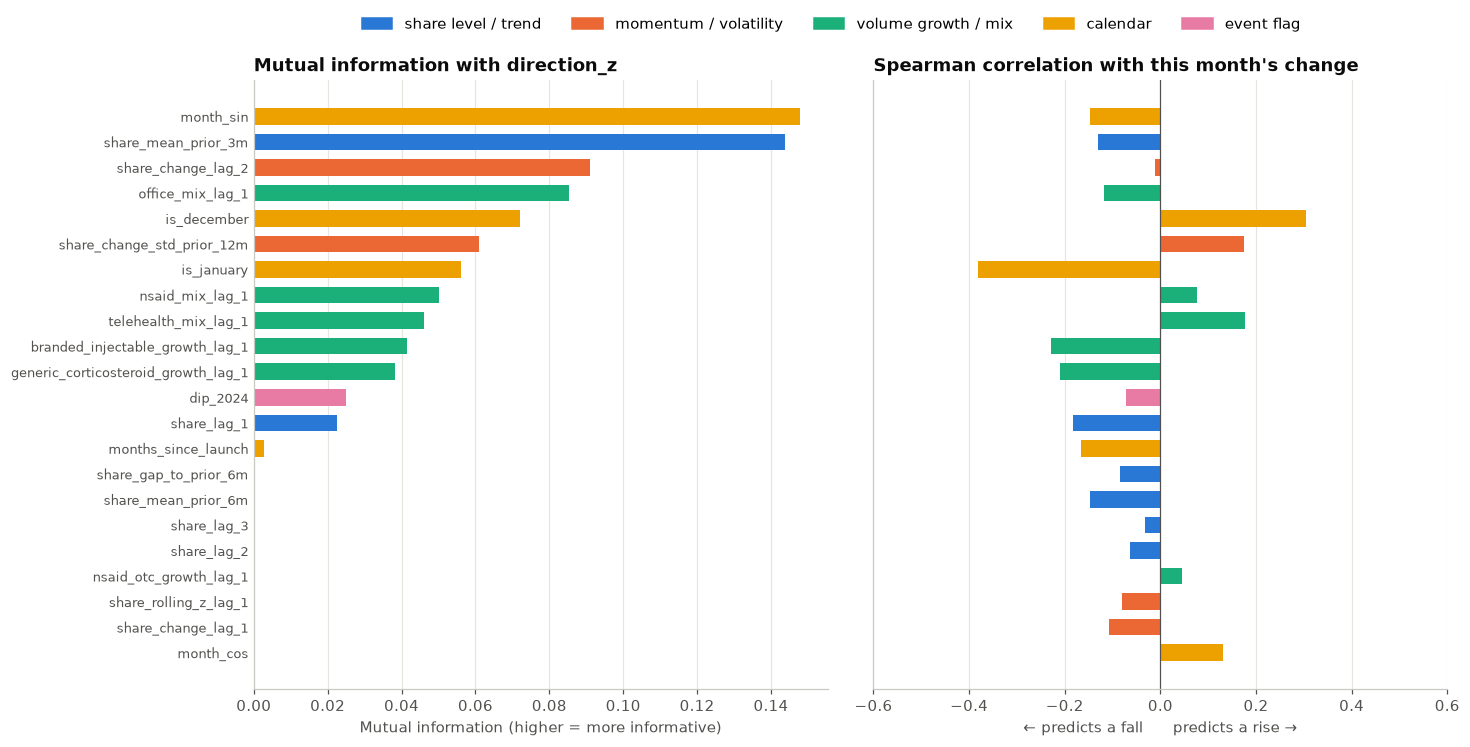

In [69]:
FAMILY = {
    "share": PALETTE[0], "change": PALETTE[1], "rolling": PALETTE[1], "gap": PALETTE[0], "mean": PALETTE[0],
    "growth": PALETTE[2], "mix": PALETTE[2], "month": PALETTE[3], "is_": PALETTE[3], "covid": PALETTE[4],
    "dip": PALETTE[4], "launch": PALETTE[3],
}
def family_color(name):
    for key in ["change", "rolling", "gap", "mean", "growth", "mix", "covid", "dip", "launch", "is_", "month", "share"]:
        if key in name:
            return FAMILY[key]
legend_items = {"share level / trend": PALETTE[0], "momentum / volatility": PALETTE[1],
                "volume growth / mix": PALETTE[2], "calendar": PALETTE[3], "event flag": PALETTE[4]}

plot_fr = fe_rank.iloc[::-1]
fig, (ax_mi, ax_sp) = plt.subplots(1, 2, figsize=(14, 7), sharey=True, gridspec_kw={"wspace": 0.08})
cols_ = [family_color(n) for n in plot_fr.index]
ax_mi.barh(plot_fr.index, plot_fr["mutual_info"], color=cols_, height=0.65)
ax_mi.set_title("Mutual information with direction_z")
ax_mi.set_xlabel("Mutual information (higher = more informative)")
ax_sp.barh(plot_fr.index, plot_fr["spearman_with_change"], color=cols_, height=0.65)
ax_sp.axvline(0, color=MUTED, lw=0.8)
ax_sp.set_xlim(-0.6, 0.6)
ax_sp.set_title("Spearman correlation with this month's change")
ax_sp.set_xlabel("← predicts a fall      predicts a rise →")
for ax in (ax_mi, ax_sp):
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", length=0, labelsize=8.5)
fig.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in legend_items.values()], legend_items.keys(),
           loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=5, frameon=False)
fig.subplots_adjust(top=0.9)
plt.show()

**Seasonality check.** This justifies the calendar features: the average change in share for each calendar month, with the new direction labels counted on top.

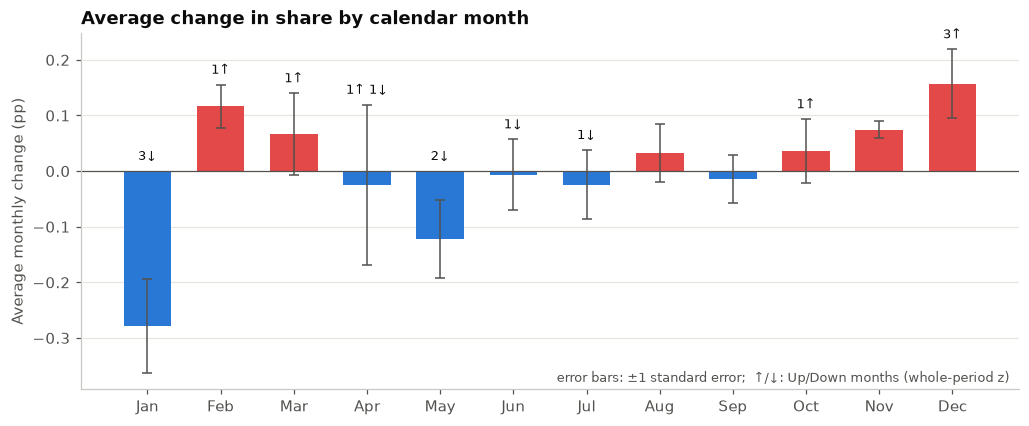

In [70]:
by_month = pd.DataFrame({"change_pp": chg * 100, "label": label(z_chg_full), "month": ts["month_number"]}).dropna()
avg = by_month.groupby("month")["change_pp"].agg(["mean", "sem"])
ups = by_month[by_month["label"] == "Up"].groupby("month").size().reindex(range(1, 13), fill_value=0)
downs = by_month[by_month["label"] == "Down"].groupby("month").size().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(avg.index, avg["mean"], yerr=avg["sem"], color=np.where(avg["mean"] > 0, PALETTE[7], PALETTE[0]),
       width=0.65, error_kw=dict(ecolor=MUTED, lw=1, capsize=3))
for m in range(1, 13):
    txt = (f"{ups[m]}↑ " if ups[m] else "") + (f"{downs[m]}↓" if downs[m] else "")
    if txt:
        ax.text(m, max(avg.loc[m, "mean"] + avg.loc[m, "sem"], 0) + 0.02, txt.strip(), ha="center", fontsize=8.5, color=INK)
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_ylabel("Average monthly change (pp)")
ax.set_title("Average change in share by calendar month")
ax.text(0.99, 0.02, "error bars: ±1 standard error;  ↑/↓: Up/Down months (whole-period z)",
        transform=ax.transAxes, ha="right", fontsize=8.5, color=MUTED)
ax.grid(axis="x", visible=False)
plt.show()

### 13.2 Segment features

For `gold_segment_adoption`:

- Segments with fewer than 20 visits are removed, and each remaining segment's total visits is kept as a **sample weight**, so large segments count more (sections 2, 10).
- `specialty_name` rare levels are grouped into "OTHER".
- Age becomes an ordinal number.

The most useful new feature is **`specialty_prior_share`**: the specialty's volume-weighted Zilretta share over **all previous months**. This is a form of *target encoding*. It summarises "how much does this specialty use Zilretta" in one number instead of 50 dummy columns. Using only earlier months keeps it free of leakage.

In [71]:
seg_fe = seg_joined.sort_values("month_id").copy()

# Specialty: group levels under 1% of segment rows into OTHER
spec_freq = seg_fe["specialty_name"].value_counts(normalize=True)
common_specs = spec_freq[spec_freq >= 0.01].index
# ("OTHER" is already a real specialty in dim_specialty, so the rare group gets its own name)
seg_fe["specialty_grouped"] = seg_fe["specialty_name"].where(seg_fe["specialty_name"].isin(common_specs), "RARE (grouped)")

# Ordinal age (UNSPECIFIED -> NaN), one-hot gender, log volume, cyclical month
AGE_RANK = {a: i for i, a in enumerate(AGE_ORDER[:-1])}
seg_fe["age_ordinal"] = seg_fe["age_band"].map(AGE_RANK)
seg_fe = seg_fe.join(pd.get_dummies(seg_fe["gender"], prefix="gender", dtype=int))
seg_fe["log_total_visits"] = np.log1p(seg_fe["total_category_visits"])
seg_fe["month_sin"] = np.sin(2 * np.pi * seg_fe["month_number"] / 12)
seg_fe["month_cos"] = np.cos(2 * np.pi * seg_fe["month_number"] / 12)

# Target encoding from PRIOR months only: cumulative Zilretta / category visits per specialty, shifted one month
spec_month = (seg_fe.groupby(["specialty_name", "month_id"])[["branded_injectable_visits", "total_category_visits"]]
              .sum().groupby(level=0).cumsum().groupby(level=0).shift(1))
spec_month["specialty_prior_share"] = spec_month["branded_injectable_visits"] / spec_month["total_category_visits"]
seg_fe = seg_fe.join(spec_month["specialty_prior_share"], on=["specialty_name", "month_id"])

# Keep segments with enough volume; the volume becomes the sample weight
seg_model = seg_fe[seg_fe["total_category_visits"] >= MIN_VISITS].dropna(subset=["specialty_prior_share"])
seg_model = seg_model.assign(sample_weight=seg_model["total_category_visits"])

SEG_FEATURES = ["specialty_grouped", "specialty_prior_share", "age_ordinal", "gender_FEMALE", "gender_MALE",
                "log_total_visits", "month_sin", "month_cos"]
print(f"specialty_name: {seg_fe['specialty_name'].nunique()} levels → specialty_grouped: "
      f"{seg_fe['specialty_grouped'].nunique()} levels ({len(common_specs)} kept + 'RARE (grouped)')")
print(f"Segments: {len(seg_fe):,} → {len(seg_model):,} after the ≥{MIN_VISITS}-visit filter and dropping each "
      f"specialty's first month (no prior history)\n")
seg_model[SEG_FEATURES + ["segment_visit_share", "sample_weight"]].head()

specialty_name: 50 levels → specialty_grouped: 29 levels (28 kept + 'RARE (grouped)')
Segments: 21,636 → 8,563 after the ≥20-visit filter and dropping each specialty's first month (no prior history)



,specialty_grouped,specialty_prior_share,age_ordinal,gender_FEMALE,gender_MALE,log_total_visits,month_sin,month_cos,segment_visit_share,sample_weight
295,PHYSICIAN ASSISTANT,0.022031,4.0,0,1,7.299797,-1.0,-1.836970e-16,0.016227,1479
296,PHYSICIAN ASSISTANT,0.022031,4.0,1,0,7.886081,-1.0,-1.836970e-16,0.014291,2659
297,PHYSICIAN ASSISTANT,0.022031,3.0,1,0,5.081404,-1.0,-1.836970e-16,0.018750,160
298,PHYSICIAN ASSISTANT,0.022031,6.0,1,0,8.283999,-1.0,-1.836970e-16,0.020712,3959
299,PHYSICIAN ASSISTANT,0.022031,6.0,0,1,7.600402,-1.0,-1.836970e-16,0.020020,1998


The chart tests `specialty_prior_share`. Segments are grouped into 10 bins by their specialty's prior share, and each bin's actual (volume-weighted) share is plotted. If the feature is useful, the points should rise along the diagonal: specialties that adopted Zilretta in the past keep adopting it.

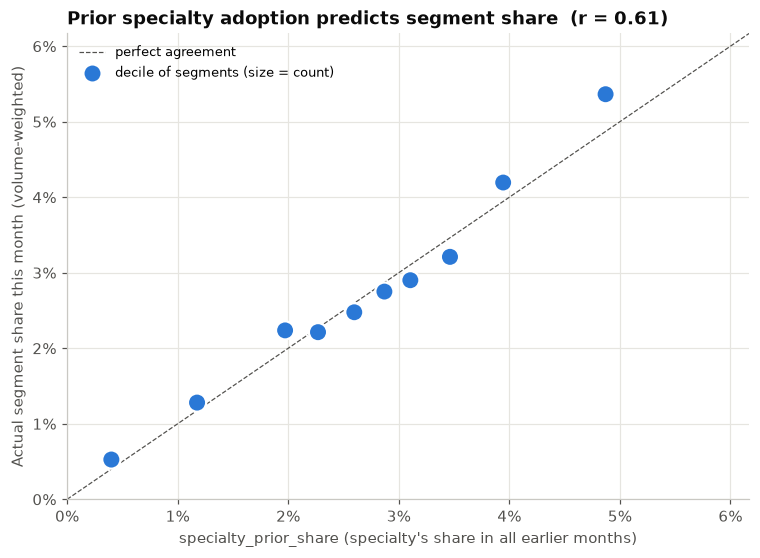

In [72]:
seg_model = seg_model.assign(prior_bin=pd.qcut(seg_model["specialty_prior_share"], 10, duplicates="drop"))
binned = seg_model.groupby("prior_bin", observed=True).apply(
    lambda d: pd.Series({"prior": np.average(d["specialty_prior_share"], weights=d["sample_weight"]),
                         "actual": np.average(d["segment_visit_share"], weights=d["sample_weight"]),
                         "segments": len(d)}), include_groups=False)
w_corr = np.corrcoef(seg_model["specialty_prior_share"], seg_model["segment_visit_share"])[0, 1]

fig, ax = plt.subplots(figsize=(8, 5.5))
lim = max(binned[["prior", "actual"]].max()) * 1.15
ax.plot([0, lim], [0, lim], color=MUTED, lw=0.8, ls="--", label="perfect agreement")
ax.scatter(binned["prior"], binned["actual"], s=binned["segments"] / 6, color=PALETTE[0], edgecolor="white",
           linewidth=1.5, zorder=3, label="decile of segments (size = count)")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("specialty_prior_share (specialty's share in all earlier months)")
ax.set_ylabel("Actual segment share this month (volume-weighted)")
ax.set_title(f"Prior specialty adoption predicts segment share  (r = {w_corr:.2f})")
ax.legend(loc="upper left", frameon=False, fontsize=8.5)
plt.show()

**Read-out:**

- **The monthly table now has a usable target and 22 leak-free features.**
  - `direction_z` replaces the original all-Flat label, and equals the warehouse's `direction_label` (section 11 verifies this).
  - Every feature uses only information available by the end of the previous month.
  - The rolling averages are prior-month windows (`share_mean_prior_3m` / `_6m`, identical to the fixed stored `visit_share_roll_*` columns).
  - The first 13 months drop out for lack of history, leaving **59 model-ready months** (7 Up / 43 Flat / 9 Down).
  - `covid_shock` falls entirely inside those 13 warm-up months, so it is constant in the model-ready data and was dropped. The COVID shock never reaches the training rows.
- **Seasonality is the clearest signal.**
  - **December** has the largest average rise (+0.16pp, 3 of 6 Decembers labelled Up) and **January** the largest fall (−0.28pp, 3 Down).
  - `is_january` (−0.38) and `is_december` (+0.30) have the strongest correlations with the monthly change, and `month_sin` has the highest mutual information.
- **Recent share level adds some information.** `share_mean_prior_3m` ranks second on MI. Its correlation is negative (−0.13): when share has been high, the next move is slightly more likely to be down, a weak mean-reversion effect.
- **Momentum is weaker than section 9 suggested.**
  - On the model-ready months (2020-09 onward), last month's change correlates only −0.11 with this month's change.
  - The −0.19 seen in section 9 was partly driven by the COVID swings in 2020, which are now excluded.
  - Lagged Zilretta and generic growth (−0.23, −0.21) point the same way: a strong month tends to be followed by a softer one.
- **Treat the rankings as indicative.** With 59 months and only 16 Up/Down cases, mutual-information estimates are noisy, and several features score 0. Any model built on these should use time-ordered cross-validation (train on earlier months, test on later) and a small, regularised feature set led by the calendar features and one or two share-level and growth features.
- **Segment features: `specialty_prior_share` is a strong single feature (r = 0.61).** It replaces 50 specialty dummies with one number, and its deciles sit almost exactly on the diagonal. A specialty's past adoption rate predicts its segments' current share, so the specialty effect from sections 9 and 11 is stable over time. `specialty_grouped` (28 specialties + `RARE (grouped)`) is there for models that prefer categories. The real specialty called `OTHER` is kept separate from the rare group.
- **Segment modelling set: 8,563 segments** with ≥20 visits and at least one prior month of specialty history, each weighted by its visit volume, so small noisy segments no longer dominate.